---

# **General Setup Section**

---



In [127]:
# @title 1. Mount Google Drive
mount_path = '/content/drive' # @param {type:"string"}

from google.colab import drive
print("Attempting to mount Google Drive...")
drive.mount(mount_path)
print(f"\nSuccess! Google Drive is mounted at: {mount_path}")

Attempting to mount Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Success! Google Drive is mounted at: /content/drive


In [128]:
# @title 2. Load R Extension
print("Loading rpy2 extension for R language support...")
%load_ext rpy2.ipython
print("\nSuccess! You can now use R by typing %%R at the top of your cells.")

Loading rpy2 extension for R language support...
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython

Success! You can now use R by typing %%R at the top of your cells.


In [129]:
# @title 3. Install Required Packages
%%R
if (!require('moments',  quietly = TRUE)) install.packages('moments',  quiet = TRUE)
if (!require('dplyr',    quietly = TRUE)) install.packages('dplyr',    quiet = TRUE)

library(moments)
library(dplyr)

cat('==================================================\n')
cat('--- Package Installation Check ---\n')
cat('==================================================\n')
cat(paste('moments :', packageVersion('moments'), '\n'))
cat(paste('dplyr   :', packageVersion('dplyr'),   '\n'))
cat('==================================================\n')
cat('All packages ready. You can now run cells 14.1–14.4\n')

--- Package Installation Check ---
moments : 0.14.1 
dplyr   : 1.2.0 
All packages ready. You can now run cells 14.1–14.4


In [130]:
# @title 4. Load Raw Dataset, View Table & Basic EDA

# --- Parameters ---
file_path            = "/content/drive/MyDrive/Redshift_MLR/Data/Rawdata/dataset_raw.csv" # @param {type:"string"}
num_rows_to_preview  = 50 # @param {type:"slider", min:1, max:50, step:1}

# --- 1. Load Data into R ---
%R -i file_path -i num_rows_to_preview dataset <- read.csv(file_path)
%R preview_df <- head(dataset, num_rows_to_preview)

print(f"Attempting to load data from:\n{file_path}\n")

# --- 2. Display Interactive Table ---
%R -o preview_df
from google.colab import data_table
from IPython.display import display

print("--- Success! Dataset Preview (Interactive Table Format) ---")
display(data_table.DataTable(preview_df))

# --- 3. Display Plain Text ---
print("\n--- Success! Dataset Preview (Plain Text Format) ---")
%R print(preview_df)

# --- 4. Basic Exploratory Data Analysis (EDA) ---
print("\n" + "="*50)
print("--- Basic Exploratory Data Analysis (EDA) ---")
print("="*50 + "\n")

print("1. Dataset Structure (str):")
%R str(dataset)

print("\n" + "-"*50)
print("2. Summary Statistics (summary):")
%R print(summary(dataset))

print("\n" + "-"*50)
print("3. Missing Values Count per Column (colSums(is.na())):")
%R print(colSums(is.na(dataset)))

Attempting to load data from:
/content/drive/MyDrive/Redshift_MLR/Data/Rawdata/dataset_raw.csv

--- Success! Dataset Preview (Interactive Table Format) ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
1,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
2,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
3,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
4,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
5,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
6,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
7,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
8,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
9,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
10,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232



--- Success! Dataset Preview (Plain Text Format) ---
         obj_ID      alpha      delta        u        g        r        i
1  1.237661e+18 135.689107 32.4946318 23.87882 22.27530 20.39501 19.16573
2  1.237665e+18 144.826101 31.2741849 24.77759 22.83188 22.58444 21.16812
3  1.237661e+18 142.188790 35.5824442 25.26307 22.66389 20.60976 19.34857
4  1.237663e+18 338.741038 -0.4028276 22.13682 23.77656 21.61162 20.50454
5  1.237680e+18 345.282593 21.1838656 19.43718 17.58028 16.49747 15.97711
6  1.237680e+18 340.995121 20.5894763 23.48827 23.33776 21.32195 20.25615
7  1.237679e+18  23.234926 11.4181876 21.46973 21.17624 20.92829 20.60826
8  1.237679e+18   5.433176 12.0651860 22.24979 22.02172 20.34126 19.48794
9  1.237661e+18 200.290475 47.1994023 24.40286 22.35669 20.61032 19.46490
10 1.237671e+18  39.149691 28.1028416 21.74669 20.03493 19.17553 18.81823
11 1.237680e+18 328.092076 18.2203105 25.77163 22.52042 20.63884 19.78071
12 1.237662e+18 243.986637 25.7382804 23.76761 23.79969 20

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

---

# **Exploratory Rawdata Analysis Section**

---

Folder    : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning 
File      : boxplots_all_features.png 
Full path : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/boxplots_all_features.png 
DPI       : 300 


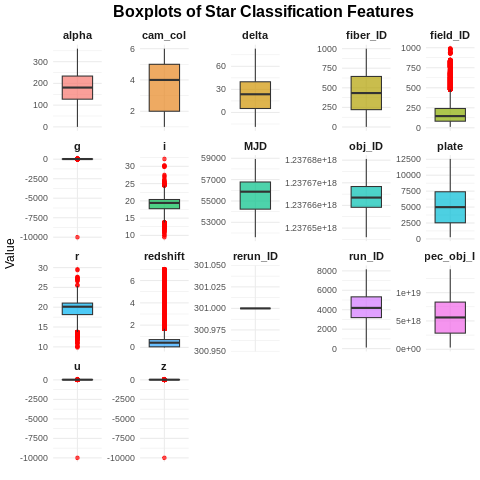

In [131]:
# @title 5.1. Boxplots for All Numeric Features
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning' # @param {type:"string"}
file_name   = 'boxplots_all_features.png' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)

save_path <- file.path(save_folder, file_name)

numeric_cols <- names(dataset)[sapply(dataset, is.numeric)]
dataset_long <- pivot_longer(dataset[, numeric_cols], cols = everything(), names_to = 'Feature', values_to = 'Value')

p <- ggplot(dataset_long, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = 'red', outlier.size = 1.5, alpha = 0.7) +
  facet_wrap(~ Feature, scales = 'free') +
  theme_minimal() +
  theme(
    axis.text.x     = element_blank(),
    legend.position = 'none',
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    strip.text      = element_text(face = 'bold', size = 11),
    axis.title.y    = element_text(size = 12)
  ) +
  labs(title = 'Boxplots of Star Classification Features', x = '', y = 'Value')

options(repr.plot.width = 20, repr.plot.height = 14)
print(p)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)
ggsave(save_path, plot = p, width = 20, height = 14, dpi = dpi)
cat('==================================================\n')
cat(paste('Folder    :', save_folder, '\n'))
cat(paste('File      :', file_name,   '\n'))
cat(paste('Full path :', save_path,   '\n'))
cat(paste('DPI       :', dpi,         '\n'))
cat('==================================================\n')

In [132]:
# @title 5.2. Boxplot Summary Statistics (Plain Text)
%%R

cat('==================================================\n')
cat('--- Boxplot Summary Statistics (Plain Text) ---\n')
cat('==================================================\n\n')

for (col in numeric_cols) {
  vals <- dataset[[col]]
  q    <- quantile(vals, probs = c(0.25, 0.5, 0.75))
  iqr  <- IQR(vals)
  lower_fence <- q[1] - 1.5 * iqr
  upper_fence <- q[3] + 1.5 * iqr

  outliers   <- vals[vals < lower_fence | vals > upper_fence]
  n_outliers <- length(outliers)

  cat(paste('Feature : ', col, '\n', sep = ''))
  cat(paste('  Min         :', min(vals),  '\n'))
  cat(paste('  Q1          :', q[1],        '\n'))
  cat(paste('  Median      :', q[2],        '\n'))
  cat(paste('  Mean        :', mean(vals),  '\n'))
  cat(paste('  Q3          :', q[3],        '\n'))
  cat(paste('  Max         :', max(vals),   '\n'))
  cat(paste('  IQR         :', iqr,         '\n'))
  cat(paste('  Lower Fence :', lower_fence, '\n'))
  cat(paste('  Upper Fence :', upper_fence, '\n'))
  cat(paste('  Outliers    :', n_outliers,  '\n'))

  if (n_outliers > 0) {
    median_val   <- q[2]
    most_extreme <- outliers[which.max(abs(outliers - median_val))]

    if (most_extreme < 0) {
      direction <- 'negative'
    } else if (most_extreme == max(outliers)) {
      direction <- 'highest'
    } else {
      direction <- 'lowest'
    }

    n_extreme <- sum(outliers == most_extreme)
    cat(paste('  Most Extreme:', most_extreme, paste0('(', direction, ')'), '\n'))
    cat(paste('  Count of Most Extreme Value:', n_extreme, '\n'))
  } else {
    cat('  Most Extreme: None\n')
  }

  cat('--------------------------------------------------\n')
}

--- Boxplot Summary Statistics (Plain Text) ---

Feature : obj_ID
  Min         : 1237645942904389888 
  Q1          : 1237659161195119360 
  Median      : 1237663463144292864 
  Mean        : 1237664721814903552 
  Q3          : 1237668350286447104 
  Max         : 1237680531356386304 
  IQR         : 9189091327744 
  Lower Fence : 1237645377558127616 
  Upper Fence : 1237682133923438592 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : alpha
  Min         : 0.00552782792397011 
  Q1          : 127.518221542123 
  Median      : 180.900700120969 
  Mean        : 177.629116621636 
  Q3          : 233.895004945922 
  Max         : 359.999809770956 
  IQR         : 106.376783403798 
  Lower Fence : -32.0469535635738 
  Upper Fence : 393.460180051619 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : delta
  Min         : -18.7853280771825 
  Q1          : 5.14677085793723 
  Median      

In [133]:
# @title 6. Interactive Row Filter
# @markdown ---
feature    = "z"             # @param ["obj_ID", "alpha", "delta", "u", "g", "r", "i", "z", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "class", "redshift", "plate", "MJD", "fiber_ID"]
value      = "-9999 "            # @param {type:"string"}
match_type = "Exact Match"  # @param ["Exact Match", "Contains", "Greater Than", "Less Than"]
# @markdown ---

import pandas as pd
from IPython.display import display
from google.colab import data_table

%R -o dataset

col     = feature.strip()
raw_val = value.strip()

if col not in dataset.columns:
    print(f"❌ Feature '{col}' not found. Available columns:")
    print(list(dataset.columns))

elif raw_val == "":
    print("⚠️  Please enter a value to search.")

else:
    try:
        col_data = dataset[col]

        if match_type == "Exact Match":
            try:
                mask = col_data == float(raw_val)
            except ValueError:
                mask = col_data.astype(str).str.strip() == raw_val

        elif match_type == "Contains":
            mask = col_data.astype(str).str.contains(raw_val, case=False, na=False)

        elif match_type == "Greater Than":
            mask = col_data > float(raw_val)

        elif match_type == "Less Than":
            mask = col_data < float(raw_val)

        result = dataset[mask]

        print("==================================================")
        print("--- Interactive Row Filter Results ---")
        print("==================================================")
        print(f"  Feature    : {col}")
        print(f"  Match Type : {match_type}")
        print(f"  Value      : {raw_val}")
        print(f"  Results    : {len(result):,} row(s) found out of {len(dataset):,} total")
        print("==================================================\n")

        if len(result) == 0:
            print("⚠️  No matching rows found.")
        else:
            display(data_table.DataTable(result, num_rows_per_page=20))

    except ValueError:
        print(f"❌ '{raw_val}' is not a valid number for '{match_type}' on column '{col}'.")
    except Exception as e:
        print(f"❌ Error: {e}")

--- Interactive Row Filter Results ---
  Feature    : z
  Match Type : Exact Match
  Value      : -9999
  Results    : 1 row(s) found out of 100,000 total



,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
79544,1.237649e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.731277e+18,STAR,0.000089,3314,54970,162


In [134]:
# @title 7.1. Display Outlier Rows Grouped by Photometric Band
%%R

library(dplyr)

bands <- c('u', 'g', 'r', 'i', 'z')

fences <- lapply(bands, function(b) {
  q   <- quantile(dataset[[b]], probs = c(0.25, 0.75))
  iqr <- q[2] - q[1]
  list(lower = q[1] - 1.5 * iqr, upper = q[2] + 1.5 * iqr)
})
names(fences) <- bands

for (b in bands) {
  dataset[[paste0('outlier_', b)]] <- (
    dataset[[b]] < fences[[b]]$lower | dataset[[b]] > fences[[b]]$upper
  )
}

dataset$outlier_bands <- apply(dataset[, paste0('outlier_', bands)], 1, function(row) {
  paste(bands[row], collapse = ', ')
})

outlier_rows <- dataset[dataset$outlier_bands != '', ]

cat('==================================================\n')
cat('--- Photometric Outlier Rows Summary ---\n')
cat('==================================================\n')
cat(paste('Total outlier rows (any band):', nrow(outlier_rows), '\n\n'))

for (b in bands) {
  flag_col <- paste0('outlier_', b)
  group    <- outlier_rows[outlier_rows[[flag_col]] == TRUE, ]

  cat('==================================================\n')
  cat(paste0('Band [', b, '] Outliers — ', nrow(group), ' row(s)\n'))
  cat(paste0('  Fence Lower : ', fences[[b]]$lower, '\n'))
  cat(paste0('  Fence Upper : ', fences[[b]]$upper, '\n'))
  cat('--------------------------------------------------\n')

  if (nrow(group) > 0) {
    display_cols <- c('obj_ID', 'class', 'redshift', bands, 'outlier_bands')
    print(group[, display_cols], row.names = FALSE)
  }
  cat('\n')
}

dataset <- dataset[, !grepl('^outlier_', names(dataset))]

--- Photometric Outlier Rows Summary ---
Total outlier rows (any band): 391 

Band [u] Outliers — 56 row(s)
  Fence Lower : 15.34972125
  Fence Upper : 28.69007125
--------------------------------------------------
       obj_ID  class      redshift           u           g        r         i
 1.237679e+18    QSO  2.539811e-01    29.19901    25.35543 23.48086 21.564950
 1.237662e+18 GALAXY  7.589578e-03    14.50678    12.67902 11.74664 11.299560
 1.237662e+18   STAR  2.498567e-05    12.26240    10.51139 10.06854 13.417860
 1.237664e+18 GALAXY  7.870603e-01    28.90174    19.24543 17.47902 16.805630
 1.237668e+18   STAR  2.895463e-04    14.64972    12.63574 12.14340 11.965980
 1.237668e+18   STAR  5.092877e-05    14.15199    10.73097  9.82207  9.469903
 1.237659e+18 GALAXY  1.169515e-02    14.65722    13.16663 12.39703 12.020130
 1.237668e+18   STAR  1.579277e-04    14.26381    12.03599 11.64166 11.515270
 1.237665e+18 GALAXY  1.589933e-02    15.15612    14.50097 14.28264 14.164320
 1.23

In [135]:
# @title 7.2. SED Profiles — Grouped by Outlier Band
%%R
max_profiles = 80      # @param {type:"slider", min:5, max:100, step:5}
color_by     = 'class' # @param ["class", "none"]
save_folder  = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning' # @param {type:"string"}
dpi          = 300     # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

bands           <- c('u', 'g', 'r', 'i', 'z')
band_wavelength <- c(u = 3551, g = 4686, r = 6165, i = 7481, z = 8931)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

fences <- lapply(bands, function(b) {
  q   <- quantile(dataset[[b]], probs = c(0.25, 0.75))
  iqr <- q[2] - q[1]
  list(lower = q[1] - 1.5 * iqr, upper = q[2] + 1.5 * iqr)
})
names(fences) <- bands

for (b in bands) {
  dataset[[paste0('outlier_', b)]] <- (
    dataset[[b]] < fences[[b]]$lower | dataset[[b]] > fences[[b]]$upper
  )
}

dataset$outlier_bands <- apply(dataset[, paste0('outlier_', bands)], 1, function(row) {
  paste(bands[row], collapse = ', ')
})

outlier_rows <- dataset[dataset$outlier_bands != '', ]

cat('==================================================\n')
cat('--- SED Profile Outlier Summary ---\n')
cat('==================================================\n')
cat(paste('Total outlier rows (any band):', nrow(outlier_rows), '\n'))
cat(paste('Save folder                  :', save_folder, '\n'))
cat(paste('DPI                          :', dpi, '\n\n'))

for (b in bands) {
  flag_col <- paste0('outlier_', b)
  group    <- outlier_rows[outlier_rows[[flag_col]] == TRUE, ]

  cat(paste0('Band [', b, '] — ', nrow(group), ' outlier row(s) | ',
             'Fence: [', round(fences[[b]]$lower, 4),
             ' , ', round(fences[[b]]$upper, 4), ']\n'))

  if (nrow(group) == 0) {
    cat('  No outliers found. Skipping.\n\n')
    next
  }

  set.seed(42)
  if (nrow(group) > max_profiles) {
    group <- group[sample(nrow(group), max_profiles), ]
  }

  group$row_id <- paste0(group$class, '_', seq_len(nrow(group)))

  sed_long <- group %>%
    select(row_id, class, all_of(bands)) %>%
    pivot_longer(cols = all_of(bands), names_to = 'band', values_to = 'magnitude') %>%
    mutate(
      wavelength      = band_wavelength[band],
      band            = factor(band, levels = bands),
      is_outlier_band = (band == b)
    )

  p <- ggplot(sed_long, aes(x = wavelength, y = magnitude, group = row_id))

  if (color_by == 'class') {
    p <- p +
      geom_line(aes(color = class), alpha = 0.5, linewidth = 0.8) +
      geom_point(aes(color = class, shape = is_outlier_band), size = 3, alpha = 0.9) +
      scale_color_manual(values = c('GALAXY' = '#E07B39',
                                    'QSO'    = '#5B8DD9',
                                    'STAR'   = '#57A773'))
  } else {
    p <- p +
      geom_line(alpha = 0.5, color = 'steelblue', linewidth = 0.8) +
      geom_point(aes(shape = is_outlier_band), size = 3, color = 'navy', alpha = 0.8)
  }

  p <- p +
    annotate('rect',
             xmin = band_wavelength[b] - 200,
             xmax = band_wavelength[b] + 200,
             ymin = -Inf, ymax = Inf,
             alpha = 0.08, fill = 'red') +
    scale_shape_manual(values = c('TRUE' = 17, 'FALSE' = 16),
                       labels = c('TRUE' = 'Outlier Band', 'FALSE' = 'Normal Band'),
                       name   = '') +
    scale_x_continuous(
      breaks = band_wavelength,
      labels = paste0(names(band_wavelength), '\n(', band_wavelength, ' Å)')
    ) +
    scale_y_reverse() +
    theme_minimal() +
    theme(
      plot.title       = element_text(face = 'bold', size = 16, hjust = 0.5),
      plot.subtitle    = element_text(size = 11, hjust = 0.5, color = 'gray40'),
      axis.title       = element_text(size = 13),
      axis.text        = element_text(size = 11),
      legend.title     = element_text(face = 'bold'),
      panel.grid.minor = element_blank()
    ) +
    labs(
      title    = paste0('SED Profiles — Outlier Band: [', b, ']'),
      subtitle = paste0('Profiles shown: ', nrow(group),
                        '  |  Fence: [', round(fences[[b]]$lower, 4),
                        ' , ', round(fences[[b]]$upper, 4), ']'),
      x        = 'Wavelength (Å)  /  SDSS Band',
      y        = 'Magnitude (reversed)',
      color    = 'Class'
    )

  tmp_path   <- paste0('/tmp/sed_band_', b, '.png')
  drive_path <- file.path(save_folder, paste0('sed_profiles_outlier_band_', b, '.png'))

  ggsave(tmp_path, plot = p, width = 16, height = 7, dpi = dpi)
  file.copy(tmp_path, drive_path, overwrite = TRUE)
  cat(paste0('  Saved → ', drive_path, '\n\n'))
}

dataset <- dataset[, !grepl('^outlier_', names(dataset))]

--- SED Profile Outlier Summary ---
Total outlier rows (any band): 391 
Save folder                  : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning 
DPI                          : 300 

Band [u] — 56 outlier row(s) | Fence: [15.3497 , 28.6901]
  Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/sed_profiles_outlier_band_u.png

Band [g] — 99 outlier row(s) | Fence: [14.2274 , 26.8616]
  Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/sed_profiles_outlier_band_g.png

Band [r] — 132 outlier row(s) | Fence: [13.7724 , 25.4082]
  Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/sed_profiles_outlier_band_r.png

Band [i] — 198 outlier row(s) | Fence: [13.736 , 24.3928]
  Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/sed_profiles_outlier_band_i.png

Band [z] — 320 outlier row(s) | Fence: [13.77 , 23.6118]
  Saved → /conten

In [136]:
# @title 7.3. Display All SED Profile Plots
from IPython.display import Image, display

bands = ['u', 'g', 'r', 'i', 'z']

for b in bands:
    print(f'--- SED Profile — Outlier Band: [{b}] ---')
    display(Image(filename=f'/tmp/sed_band_{b}.png'))

Output hidden; open in https://colab.research.google.com to view.

In [137]:
# @title 7.4. Individual Bar Charts — All Outlier Rows
%%R
color_by      = 'outlier_highlight' # @param ["outlier_highlight", "band", "class"]
ncols         = 4                   # @param {type:"slider", min:1, max:6, step:1}
rows_per_page = 12                  # @param {type:"slider", min:4, max:40, step:4}
save_folder   = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning' # @param {type:"string"}
dpi           = 300                 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

bands <- c('u', 'g', 'r', 'i', 'z')

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

fences <- lapply(bands, function(b) {
  q   <- quantile(dataset[[b]], probs = c(0.25, 0.75))
  iqr <- q[2] - q[1]
  list(lower = q[1] - 1.5 * iqr, upper = q[2] + 1.5 * iqr)
})
names(fences) <- bands

for (b in bands) {
  dataset[[paste0('outlier_', b)]] <- (
    dataset[[b]] < fences[[b]]$lower | dataset[[b]] > fences[[b]]$upper
  )
}

dataset$outlier_bands <- apply(dataset[, paste0('outlier_', bands)], 1, function(row) {
  paste(bands[row], collapse = ', ')
})

outlier_rows <- dataset[dataset$outlier_bands != '', ]

total_rows  <- nrow(outlier_rows)
total_pages <- ceiling(total_rows / rows_per_page)

cat('==================================================\n')
cat('--- Individual Bar Charts — ALL Outlier Rows ---\n')
cat('==================================================\n')
cat(paste('Total outlier rows :', total_rows,    '\n'))
cat(paste('Rows per page      :', rows_per_page, '\n'))
cat(paste('Total pages        :', total_pages,   '\n'))
cat(paste('Save folder        :', save_folder,   '\n'))
cat(paste('DPI                :', dpi,           '\n'))
cat('==================================================\n\n')

outlier_rows$row_label <- paste0(
  'Row #', seq_len(total_rows),
  '\nClass: ',    outlier_rows$class,
  '\nOutlier: [', outlier_rows$outlier_bands, ']'
)

fence_df <- data.frame(
  band        = factor(bands, levels = bands),
  fence_lower = sapply(bands, function(b) fences[[b]]$lower),
  fence_upper = sapply(bands, function(b) fences[[b]]$upper)
)

for (page in seq_len(total_pages)) {
  start <- (page - 1) * rows_per_page + 1
  end   <- min(page * rows_per_page, total_rows)

  page_rows <- outlier_rows[start:end, ]

  sed_long <- page_rows %>%
    select(row_label, class, outlier_bands, all_of(bands)) %>%
    pivot_longer(cols = all_of(bands), names_to = 'band', values_to = 'magnitude') %>%
    mutate(
      band       = factor(band, levels = bands),
      is_outlier = mapply(function(b, ob) grepl(b, ob), band, outlier_bands)
    ) %>%
    left_join(fence_df, by = 'band')

  if (color_by == 'outlier_highlight') {
    p <- ggplot(sed_long, aes(x = band, y = magnitude, fill = is_outlier)) +
      geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
      scale_fill_manual(
        values = c('TRUE' = '#E74C3C', 'FALSE' = '#5B8DD9'),
        labels = c('TRUE' = 'Outlier', 'FALSE' = 'Normal'),
        name   = ''
      )
  } else if (color_by == 'band') {
    p <- ggplot(sed_long, aes(x = band, y = magnitude, fill = band)) +
      geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
      scale_fill_manual(
        values = c(u = '#9B59B6', g = '#2ECC71',
                   r = '#E74C3C', i = '#E67E22', z = '#1ABC9C'),
        name   = 'Band'
      )
  } else {
    p <- ggplot(sed_long, aes(x = band, y = magnitude, fill = class)) +
      geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
      scale_fill_manual(
        values = c('GALAXY' = '#E07B39', 'QSO' = '#5B8DD9', 'STAR' = '#57A773'),
        name   = 'Class'
      )
  }

  p <- p +
    geom_bar(data = sed_long[sed_long$is_outlier == TRUE, ],
             aes(x = band, y = magnitude),
             stat = 'identity', fill = NA,
             color = '#E74C3C', linewidth = 1.3, width = 0.7) +
    geom_segment(aes(x    = as.numeric(band) - 0.4,
                     xend = as.numeric(band) + 0.4,
                     y    = fence_lower, yend = fence_lower),
                 color = 'orange', linewidth = 0.7, linetype = 'dashed') +
    geom_segment(aes(x    = as.numeric(band) - 0.4,
                     xend = as.numeric(band) + 0.4,
                     y    = fence_upper, yend = fence_upper),
                 color = 'orange', linewidth = 0.7, linetype = 'dashed') +
    facet_wrap(~ row_label, scales = 'free_y', ncol = ncols) +
    scale_y_reverse() +
    theme_minimal() +
    theme(
      plot.title       = element_text(face = 'bold', size = 15, hjust = 0.5),
      plot.subtitle    = element_text(size = 10, hjust = 0.5, color = 'gray40'),
      strip.text       = element_text(face = 'bold', size = 8.5, lineheight = 1.3),
      axis.title       = element_text(size = 11),
      axis.text.x      = element_text(size = 10, face = 'bold'),
      axis.text.y      = element_text(size = 8),
      legend.position  = 'bottom',
      panel.grid.minor = element_blank(),
      panel.spacing    = unit(1.2, 'lines')
    ) +
    labs(
      title    = paste0('Individual Bar Charts — Outlier Rows  |  Page ', page, ' / ', total_pages),
      subtitle = paste0('Rows ', start, ' - ', end, ' of ', total_rows,
                        '  |  Red border = outlier bar  |  Dashed = per-band fence'),
      x = 'Band',
      y = 'Magnitude (reversed)'
    )

  n_page_rows <- ceiling((end - start + 1) / ncols)
  plot_w <- ncols * 4
  plot_h <- max(5, n_page_rows * 4.5)

  tmp_path  <- paste0('/tmp/bar_outlier_page_', sprintf('%03d', page), '.png')
  save_path <- file.path(save_folder, paste0('bar_outlier_page_', sprintf('%03d', page), '.png'))

  ggsave(tmp_path, plot = p, width = plot_w, height = plot_h, dpi = dpi)
  file.copy(tmp_path, save_path, overwrite = TRUE)
  cat(paste0('Saved page ', page, ' / ', total_pages, ' → ', save_path, '\n'))
}

dataset <- dataset[, !grepl('^outlier_', names(dataset))]

--- Individual Bar Charts — ALL Outlier Rows ---
Total outlier rows : 391 
Rows per page      : 12 
Total pages        : 33 
Save folder        : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning 
DPI                : 300 

Saved page 1 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_001.png
Saved page 2 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_002.png
Saved page 3 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_003.png
Saved page 4 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_004.png
Saved page 5 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_005.png
Saved page 6 / 33 → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/bar_outlier_page_006.png
Saved page 7 / 33 → /con

In [138]:
# @title 7.5. Display All Saved Bar Chart Pages
from IPython.display import Image, display
import glob

pages = sorted(glob.glob('/tmp/bar_outlier_page_*.png'))
print(f"Displaying {len(pages)} pages...\n")

for path in pages:
    display(Image(filename=path))

Output hidden; open in https://colab.research.google.com to view.

---

# **Physics vs Statistics Investigation Section**

---

In [139]:
# @title 8. Investigate False Positive Outliers (Stat vs Physics)
%%R

library(dplyr)

bands        <- c('u', 'g', 'r', 'i', 'z')
PHYS_BRIGHT  <- 10
PHYS_FAINT   <- 30
ERROR_FLAG   <- -9999
PREVIEW_ROWS <- 15

fences <- lapply(bands, function(b) {
  q   <- quantile(dataset[[b]], probs = c(0.25, 0.75), na.rm = TRUE)
  iqr <- q[2] - q[1]
  list(lower = q[1] - 1.5 * iqr, upper = q[2] + 1.5 * iqr)
})
names(fences) <- bands

total_rows <- nrow(dataset)

cat('==================================================\n')
cat('--- Investigation: IQR Outliers vs Physics ---\n')
cat('==================================================\n')
cat(sprintf('Total rows in dataset : %d\n\n', total_rows))
cat('Physics Rules Applied:\n')
cat(sprintf('  Bright limit (saturated) : mag < %d\n',  PHYS_BRIGHT))
cat(sprintf('  Faint  limit (sensor max): mag > %d\n',  PHYS_FAINT))
cat(sprintf('  Error flag               : mag = %d\n\n', ERROR_FLAG))

summary_df <- data.frame(
  Band           = character(),
  IQR_Lower      = numeric(),
  IQR_Upper      = numeric(),
  Stat_Outliers  = integer(),
  True_Errors    = integer(),
  False_Pos_Low  = integer(),
  False_Pos_High = integer(),
  Keep           = integer(),
  Remove         = integer(),
  stringsAsFactors = FALSE
)

for (b in bands) {
  lower_fence <- fences[[b]]$lower
  upper_fence <- fences[[b]]$upper
  vals        <- dataset[[b]]

  stat_outliers  <- dataset %>% filter(vals < lower_fence | vals > upper_fence)
  true_errors    <- dataset %>% filter(
    .data[[b]] == ERROR_FLAG |
    .data[[b]] <  PHYS_BRIGHT |
    .data[[b]] >  PHYS_FAINT
  )
  false_pos_high <- dataset %>% filter(
    .data[[b]] >  upper_fence &
    .data[[b]] <= PHYS_FAINT  &
    .data[[b]] != ERROR_FLAG
  )
  false_pos_low  <- dataset %>% filter(
    .data[[b]] <  lower_fence &
    .data[[b]] >= PHYS_BRIGHT &
    .data[[b]] != ERROR_FLAG
  )

  keep       <- nrow(false_pos_high) + nrow(false_pos_low)
  remove     <- nrow(true_errors)
  pct_remove <- round(remove / total_rows * 100, 2)
  pct_keep   <- round(keep   / total_rows * 100, 2)

  cat('==================================================\n')
  cat(sprintf('Band [%s]\n', b))
  cat(sprintf('  IQR Fence          : Lower = %.4f  |  Upper = %.4f\n', lower_fence, upper_fence))
  cat(sprintf('  Statistical outliers (IQR)                 : %d rows\n', nrow(stat_outliers)))
  cat('  ------------------------------------------\n')
  cat(sprintf('  ✅ False Positives — KEEP (bright, valid)  : %d rows (%.2f%%)\n', nrow(false_pos_low),  pct_keep / 2))
  cat(sprintf('  ✅ False Positives — KEEP (faint,  valid)  : %d rows (%.2f%%)\n', nrow(false_pos_high), pct_keep / 2))
  cat(sprintf('  ❌ True Errors     — REMOVE                : %d rows (%.2f%%)\n', remove, pct_remove))
  cat(sprintf('     └─ Sentinel (-9999)  : %d rows\n',
      nrow(dataset %>% filter(.data[[b]] == ERROR_FLAG))))
  cat(sprintf('     └─ Saturated (<10)   : %d rows\n',
      nrow(dataset %>% filter(.data[[b]] < PHYS_BRIGHT & .data[[b]] != ERROR_FLAG))))
  cat(sprintf('     └─ Beyond limit (>30): %d rows\n',
      nrow(dataset %>% filter(.data[[b]] > PHYS_FAINT))))

  summary_df <- rbind(summary_df, data.frame(
    Band           = b,
    IQR_Lower      = round(lower_fence, 4),
    IQR_Upper      = round(upper_fence, 4),
    Stat_Outliers  = nrow(stat_outliers),
    True_Errors    = remove,
    False_Pos_Low  = nrow(false_pos_low),
    False_Pos_High = nrow(false_pos_high),
    Keep           = keep,
    Remove         = remove,
    stringsAsFactors = FALSE
  ))
}

cat('\n==================================================\n')
cat('--- Summary Table (All Bands) ---\n')
cat('==================================================\n')
print(summary_df, row.names = FALSE)

error_mask <- Reduce('|', lapply(bands, function(b) {
  dataset[[b]] == ERROR_FLAG |
  dataset[[b]] <  PHYS_BRIGHT |
  dataset[[b]] >  PHYS_FAINT
}))
total_remove <- sum(error_mask)
total_keep   <- total_rows - total_remove

cat(sprintf('\nTotal rows to REMOVE (any band has true error) : %d  (%.2f%%)\n',
    total_remove, total_remove / total_rows * 100))
cat(sprintf('Total rows to KEEP   (clean after removal)     : %d  (%.2f%%)\n',
    total_keep,   total_keep   / total_rows * 100))

cat('\n==================================================\n')
cat('--- Preview: Valid Faint Objects — All Bands ---\n')
cat(sprintf('    Showing top %d rows per band\n', PREVIEW_ROWS))
cat('==================================================\n')

for (b in bands) {
  upper_fence <- fences[[b]]$upper

  faint_preview <- dataset %>%
    filter(.data[[b]] >  upper_fence &
           .data[[b]] <= PHYS_FAINT) %>%
    select(obj_ID, class, redshift, all_of(bands)) %>%
    arrange(desc(.data[[b]]))

  cat(sprintf('\n--- Band [%s] : mag > %.4f AND mag <= %d ---\n',
      b, upper_fence, PHYS_FAINT))
  cat(sprintf('Found %d valid faint objects. Showing top %d:\n\n',
      nrow(faint_preview), PREVIEW_ROWS))

  if (nrow(faint_preview) > 0) {
    print(head(faint_preview, PREVIEW_ROWS), row.names = FALSE)
  } else {
    cat('  No valid faint objects found.\n')
  }
  cat('--------------------------------------------------\n')
}

--- Investigation: IQR Outliers vs Physics ---
Total rows in dataset : 100000

Physics Rules Applied:
  Bright limit (saturated) : mag < 10
  Faint  limit (sensor max): mag > 30
  Error flag               : mag = -9999

Band [u]
  IQR Fence          : Lower = 15.3497  |  Upper = 28.6901
  Statistical outliers (IQR)                 : 56 rows
  ------------------------------------------
  ✅ False Positives — KEEP (bright, valid)  : 44 rows (0.03%)
  ✅ False Positives — KEEP (faint,  valid)  : 9 rows (0.03%)
  ❌ True Errors     — REMOVE                : 3 rows (0.00%)
     └─ Sentinel (-9999)  : 1 rows
     └─ Saturated (<10)   : 0 rows
     └─ Beyond limit (>30): 2 rows
Band [g]
  IQR Fence          : Lower = 14.2274  |  Upper = 26.8616
  Statistical outliers (IQR)                 : 99 rows
  ------------------------------------------
  ✅ False Positives — KEEP (bright, valid)  : 76 rows (0.05%)
  ✅ False Positives — KEEP (faint,  valid)  : 20 rows (0.05%)
  ❌ True Errors     — REMOVE   

In [140]:
# @title 9.1. Visual Re-check of False Positive Outliers
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)

bands       <- c('u', 'g', 'r', 'i', 'z')
PHYS_BRIGHT <- 10
PHYS_FAINT  <- 30
ERROR_FLAG  <- -9999

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

fences <- lapply(bands, function(b) {
  q   <- quantile(dataset[[b]], probs = c(0.25, 0.75), na.rm = TRUE)
  iqr <- q[2] - q[1]
  list(lower = q[1] - 1.5 * iqr, upper = q[2] + 1.5 * iqr)
})
names(fences) <- bands

summary_df <- do.call(rbind, lapply(bands, function(b) {
  lower_fence <- fences[[b]]$lower
  upper_fence <- fences[[b]]$upper

  false_pos_low  <- dataset %>% filter(
    .data[[b]] <  lower_fence &
    .data[[b]] >= PHYS_BRIGHT &
    .data[[b]] != ERROR_FLAG
  )
  false_pos_high <- dataset %>% filter(
    .data[[b]] >  upper_fence &
    .data[[b]] <= PHYS_FAINT  &
    .data[[b]] != ERROR_FLAG
  )
  true_errors <- dataset %>% filter(
    .data[[b]] == ERROR_FLAG |
    .data[[b]] <  PHYS_BRIGHT |
    .data[[b]] >  PHYS_FAINT
  )

  data.frame(
    Band           = b,
    False_Pos_Low  = nrow(false_pos_low),
    False_Pos_High = nrow(false_pos_high),
    True_Errors    = nrow(true_errors),
    stringsAsFactors = FALSE
  )
}))

summary_df$Band <- factor(summary_df$Band, levels = bands)

cat('==================================================\n')
cat('--- Summary: IQR Outlier Categories per Band ---\n')
cat('==================================================\n')
print(summary_df, row.names = FALSE)
cat('\n')

summary_long <- summary_df %>%
  pivot_longer(cols = c(False_Pos_Low, False_Pos_High, True_Errors),
               names_to  = 'Category',
               values_to = 'Count') %>%
  mutate(Category = factor(Category,
                           levels = c('True_Errors', 'False_Pos_High', 'False_Pos_Low')))

p1 <- ggplot(summary_long, aes(x = Band, y = Count, fill = Category)) +
  geom_bar(stat = 'identity', color = 'white', linewidth = 0.3) +
  geom_text(aes(label = ifelse(Count > 0, Count, '')),
            position = position_stack(vjust = 0.5),
            size = 3.5, fontface = 'bold', color = 'white') +
  scale_fill_manual(
    values = c('True_Errors'    = '#E74C3C',
               'False_Pos_High' = '#F1C40F',
               'False_Pos_Low'  = '#2ECC71'),
    labels = c('True Errors (>30 or <10 or -9999)',
               'Valid Faint (IQR upper to 30)',
               'Valid Bright (10 to IQR lower)')
  ) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 10, hjust = 0.5, color = 'gray40'),
    legend.position = 'bottom',
    legend.title    = element_text(face = 'bold'),
    legend.text     = element_text(size = 9)
  ) +
  labs(
    title    = 'Breakdown of IQR Outliers by Physics Category',
    subtitle = 'Most IQR outliers are physically valid objects',
    x = 'Filter Band', y = 'Number of Rows', fill = 'Physics Status'
  )

scatter_plots <- lapply(bands, function(b) {
  upper_fence <- fences[[b]]$upper
  faint_df    <- dataset %>%
    filter(.data[[b]] > upper_fence & .data[[b]] <= PHYS_FAINT)

  ggplot(faint_df, aes(x = .data[[b]], y = redshift, color = class)) +
    geom_point(size = 2.5, alpha = 0.8) +
    scale_color_manual(values = c('GALAXY' = '#E07B39',
                                  'QSO'    = '#5B8DD9',
                                  'STAR'   = '#57A773')) +
    theme_minimal() +
    theme(
      plot.title      = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle   = element_text(size = 8, hjust = 0.5, color = 'gray40'),
      legend.position = 'bottom',
      legend.title    = element_blank(),
      legend.text     = element_text(size = 8)
    ) +
    labs(
      title    = paste0('Redshift vs [', b, ']'),
      subtitle = paste0(nrow(faint_df), ' valid faint objects'),
      x        = paste0('Magnitude (', b, ') →'),
      y        = 'Redshift'
    )
})

class_plots <- lapply(bands, function(b) {
  upper_fence <- fences[[b]]$upper
  faint_df    <- dataset %>%
    filter(.data[[b]] > upper_fence & .data[[b]] <= PHYS_FAINT)

  ggplot(faint_df, aes(x = class, fill = class)) +
    geom_bar(color = 'white', alpha = 0.85, linewidth = 0.3) +
    geom_text(stat = 'count', aes(label = after_stat(count)),
              vjust = -0.4, fontface = 'bold', size = 3.5) +
    scale_fill_manual(values = c('GALAXY' = '#E07B39',
                                 'QSO'    = '#5B8DD9',
                                 'STAR'   = '#57A773')) +
    theme_minimal() +
    theme(
      plot.title      = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle   = element_text(size = 8, hjust = 0.5, color = 'gray40'),
      legend.position = 'none'
    ) +
    labs(
      title    = paste0('Class Dist. [', b, ']'),
      subtitle = 'Valid faint objects only',
      x = 'Class', y = 'Count'
    )
})

scatter_combined <- scatter_plots[[1]] | scatter_plots[[2]] | scatter_plots[[3]] |
                    scatter_plots[[4]] | scatter_plots[[5]]
class_combined   <- class_plots[[1]]   | class_plots[[2]]   | class_plots[[3]]   |
                    class_plots[[4]]   | class_plots[[5]]

files <- list(
  list(plot = p1,               tmp = '/tmp/plot_visual_stacked.png', name = 'plot_visual_stacked.png', w = 10, h = 6),
  list(plot = scatter_combined, tmp = '/tmp/plot_visual_scatter.png', name = 'plot_visual_scatter.png', w = 24, h = 5),
  list(plot = class_combined,   tmp = '/tmp/plot_visual_class.png',   name = 'plot_visual_class.png',   w = 24, h = 5)
)

cat('==================================================\n')
cat('--- Saving Plots ---\n')
cat('==================================================\n')

for (f in files) {
  drive_path <- file.path(save_folder, f$name)
  ggsave(f$tmp,    plot = f$plot, width = f$w, height = f$h, dpi = dpi)
  file.copy(f$tmp, drive_path, overwrite = TRUE)
  cat(paste0('Saved → ', drive_path, '\n'))
}

cat('==================================================\n')
cat(paste('Folder :', save_folder, '\n'))
cat(paste('DPI    :', dpi,         '\n'))
cat('==================================================\n')

--- Summary: IQR Outlier Categories per Band ---
 Band False_Pos_Low False_Pos_High True_Errors
    u            44              9           3
    g            76             20           3
    r           117             14           1
    i           163             30           5
    z           255             63           2

--- Saving Plots ---
Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/plot_visual_stacked.png
Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/plot_visual_scatter.png
Saved → /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning/plot_visual_class.png
Folder : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_before_cleaning 
DPI    : 300 


--- Plot 1: IQR Outlier Breakdown (Stacked Bar) ---


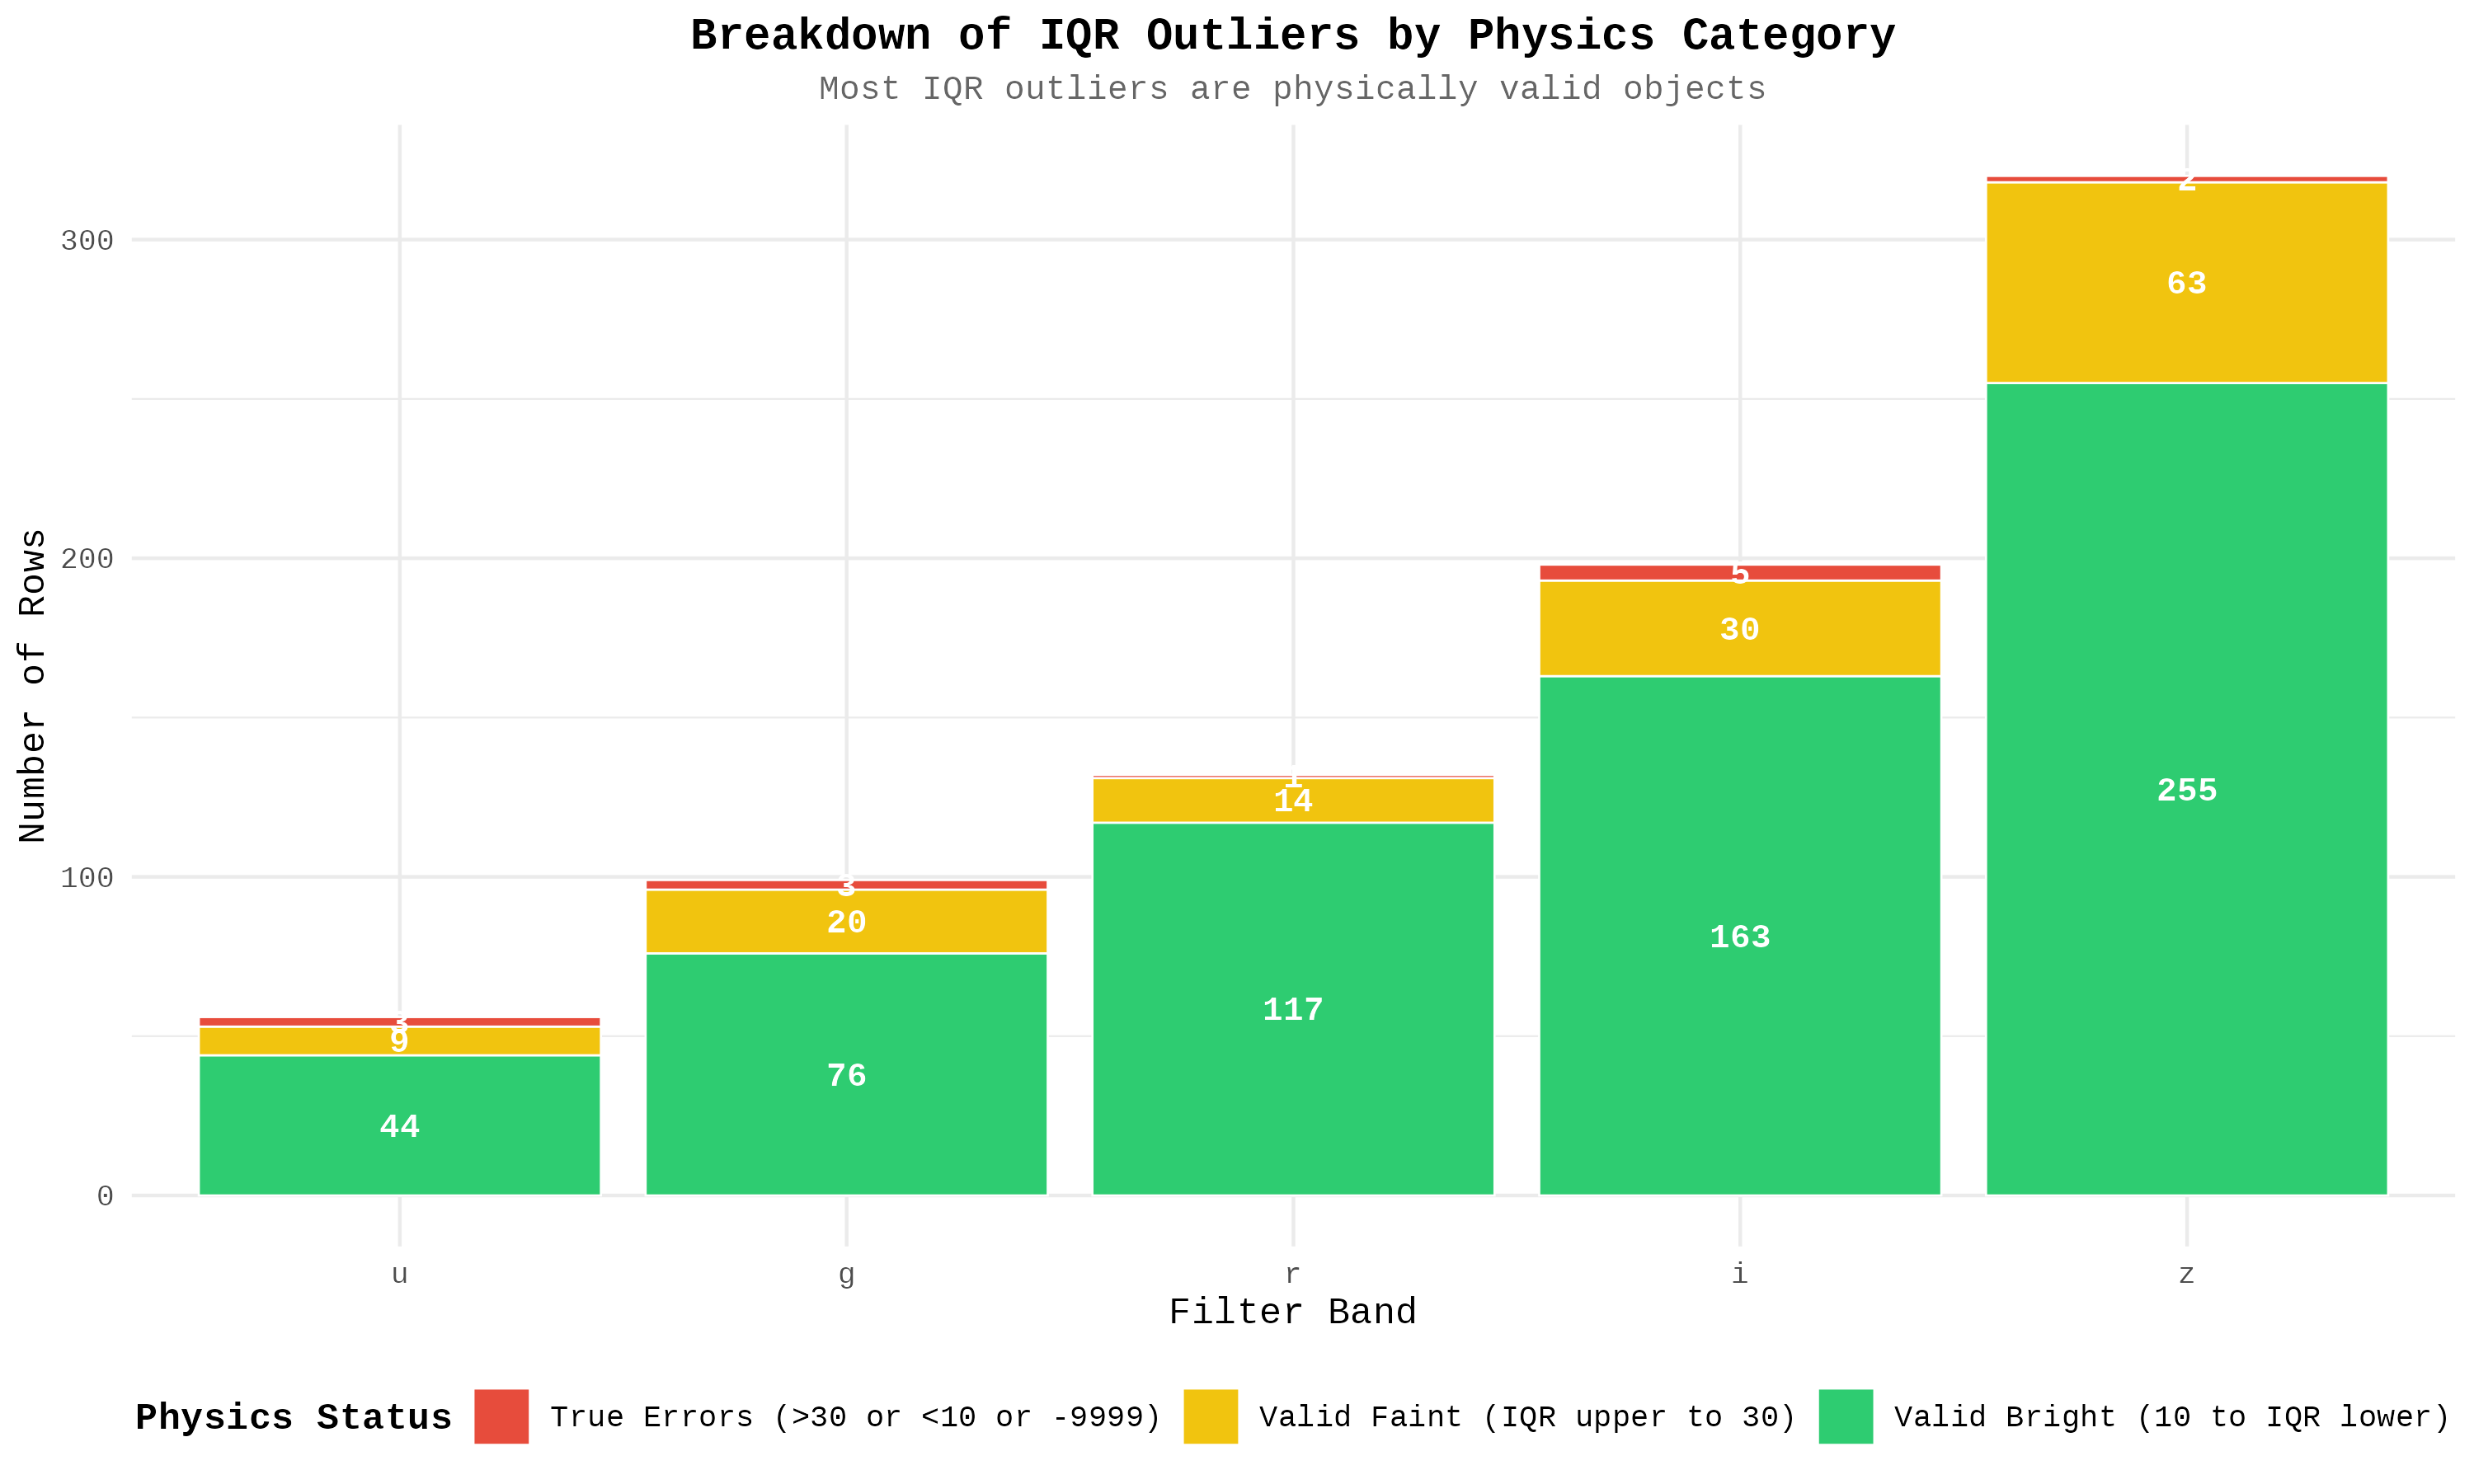

--- Plot 2: Redshift vs Magnitude (All Bands) ---


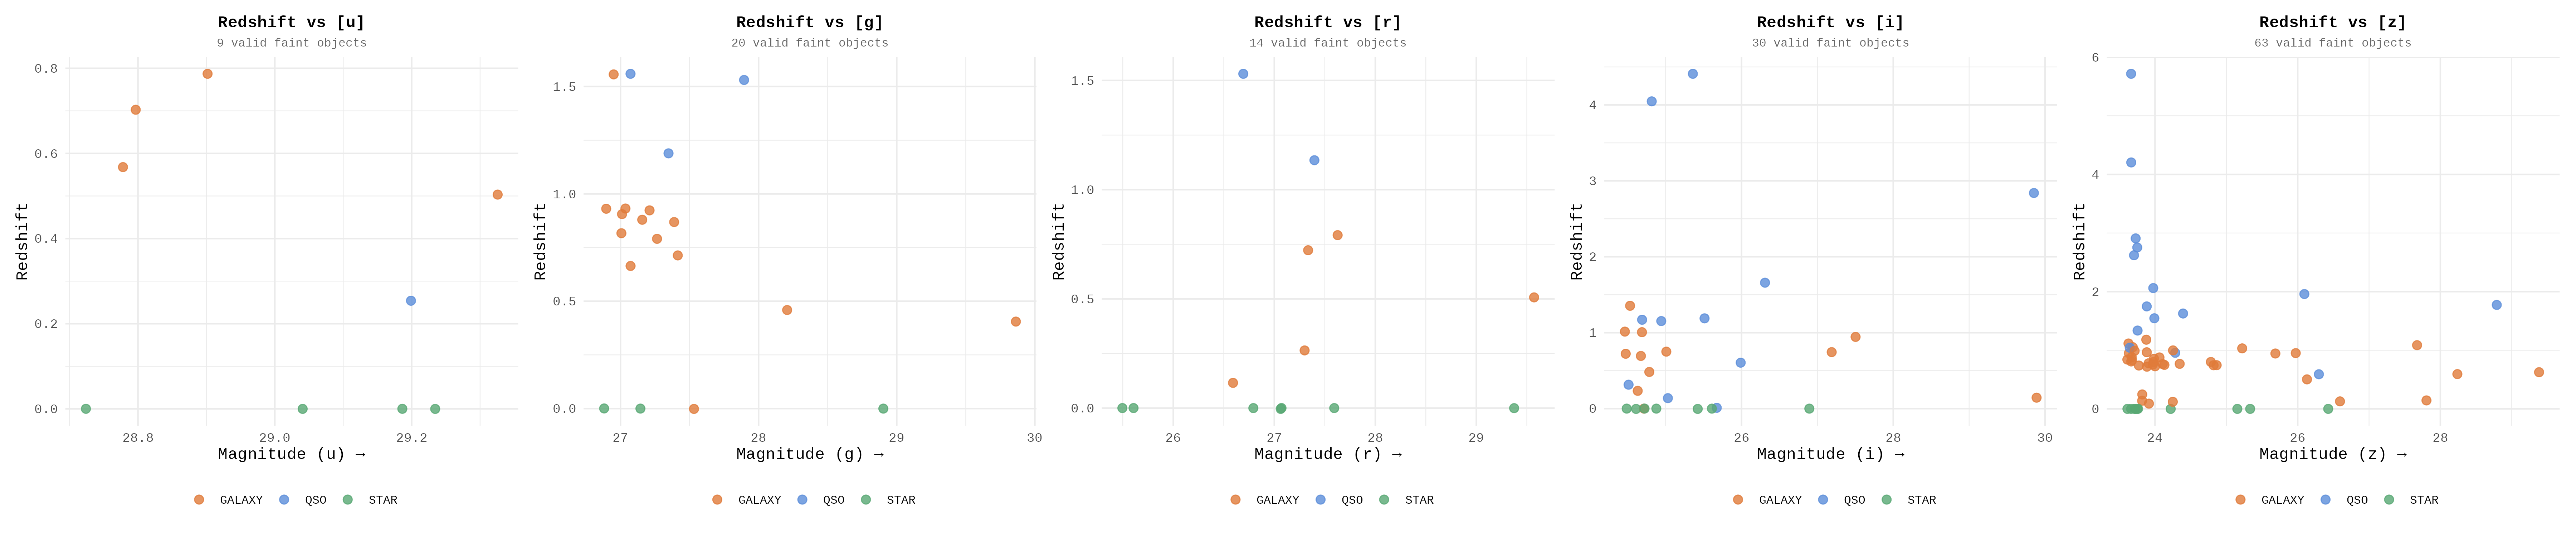

--- Plot 3: Class Distribution (All Bands) ---


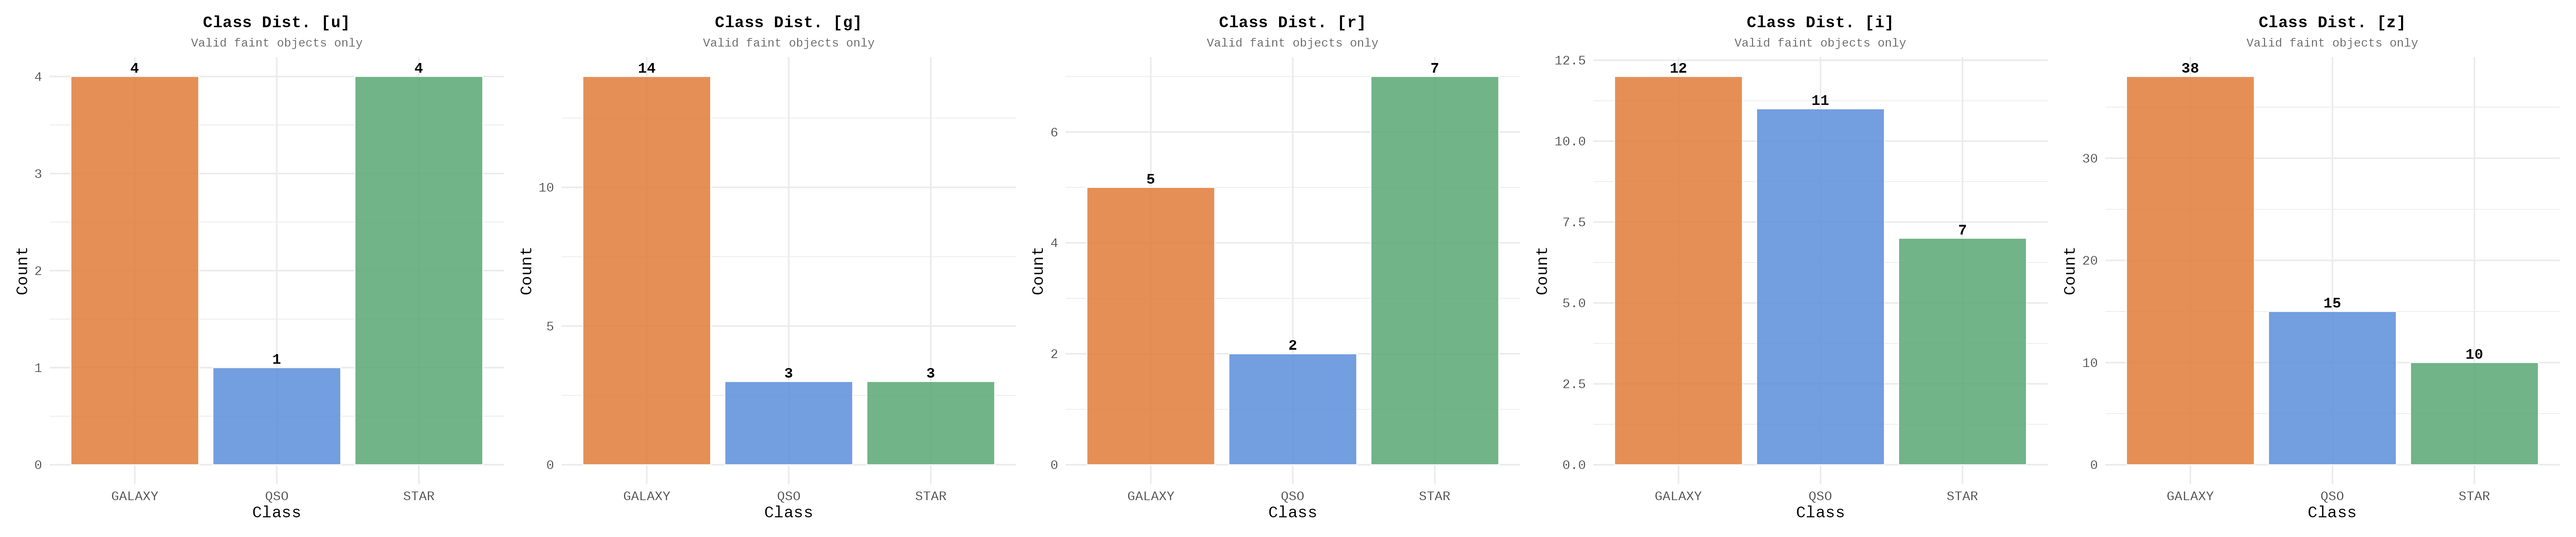

In [141]:
# @title 9.2. Display All Visual Re-check Plots
from IPython.display import Image, display

plots = [
    ('/tmp/plot_visual_stacked.png', '--- Plot 1: IQR Outlier Breakdown (Stacked Bar) ---'),
    ('/tmp/plot_visual_scatter.png', '--- Plot 2: Redshift vs Magnitude (All Bands) ---'),
    ('/tmp/plot_visual_class.png',   '--- Plot 3: Class Distribution (All Bands) ---'),
]

for path, title in plots:
    print(title)
    display(Image(filename=path))

---

# **Data Cleaning Section**

---

In [142]:
# @title 10. Data Cleaning — Clone, Clean & Export
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Data/Cleandata' # @param {type:"string"}

library(dplyr)

# --- Physics limits ---
PHYS_BRIGHT <- 10
PHYS_FAINT  <- 30
ERROR_FLAG  <- -9999
bands       <- c('u', 'g', 'r', 'i', 'z')

# --- Step 1: Clone raw dataset ---
dataset_clean <- dataset

cat('==================================================\n')
cat('--- Data Cleaning Report ---\n')
cat('==================================================\n')
cat(sprintf('Original rows : %d\n', nrow(dataset_clean)))
cat(sprintf('Columns       : %d\n', ncol(dataset_clean)))
cat(sprintf('Save folder   : %s\n\n', save_folder))

# --- Step 2: Identify error rows ---
error_mask <- Reduce('|', lapply(bands, function(b) {
  dataset_clean[[b]] == ERROR_FLAG |
  dataset_clean[[b]] <  PHYS_BRIGHT |
  dataset_clean[[b]] >  PHYS_FAINT
}))

error_rows <- dataset_clean[error_mask, ]
cat('--- Removed Rows Detail ---\n')
cat(sprintf('Total rows removed : %d\n\n', nrow(error_rows)))

# Print each removed row with the reason
for (i in seq_len(nrow(error_rows))) {
  row <- error_rows[i, ]
  bad_bands <- bands[sapply(bands, function(b) {
    row[[b]] == ERROR_FLAG | row[[b]] < PHYS_BRIGHT | row[[b]] > PHYS_FAINT
  })]
  cat(sprintf('  Row %d | class: %-6s | redshift: %.6f | bad bands: [%s]\n',
      i,
      row$class,
      row$redshift,
      paste(bad_bands, collapse = ', ')))
  for (b in bad_bands) {
    cat(sprintf('    └─ %s = %s\n', b, row[[b]]))
  }
}

# --- Step 3: Remove error rows ---
dataset_clean <- dataset_clean[!error_mask, ]

cat(sprintf('\nRows after cleaning : %d\n', nrow(dataset_clean)))
cat(sprintf('Rows removed        : %d\n\n', sum(error_mask)))

# --- Step 4: Split by class ---
dataset_GALAXY <- dataset_clean %>% filter(class == 'GALAXY')
dataset_QSO    <- dataset_clean %>% filter(class == 'QSO')
dataset_STAR   <- dataset_clean %>% filter(class == 'STAR')

cat('--- Class Split Summary ---\n')
cat(sprintf('  GALAXY : %d rows (%.2f%%)\n', nrow(dataset_GALAXY), nrow(dataset_GALAXY) / nrow(dataset_clean) * 100))
cat(sprintf('  QSO    : %d rows (%.2f%%)\n', nrow(dataset_QSO),    nrow(dataset_QSO)    / nrow(dataset_clean) * 100))
cat(sprintf('  STAR   : %d rows (%.2f%%)\n', nrow(dataset_STAR),   nrow(dataset_STAR)   / nrow(dataset_clean) * 100))
cat(sprintf('  Total  : %d rows\n\n',         nrow(dataset_clean)))

# --- Step 5: Verify no errors remain ---
cat('--- Verification (should all be 0) ---\n')
for (b in bands) {
  n_errors <- sum(
    dataset_clean[[b]] == ERROR_FLAG |
    dataset_clean[[b]] <  PHYS_BRIGHT |
    dataset_clean[[b]] >  PHYS_FAINT
  )
  cat(sprintf('  Band [%s] remaining errors: %d %s\n',
      b, n_errors, ifelse(n_errors == 0, '✅', '❌')))
}

# --- Step 6: Save all four files ---
dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

files <- list(
  list(data = dataset_clean,  name = 'dataset_clean.csv'),
  list(data = dataset_GALAXY, name = 'dataset_clean_GALAXY.csv'),
  list(data = dataset_QSO,    name = 'dataset_clean_QSO.csv'),
  list(data = dataset_STAR,   name = 'dataset_clean_STAR.csv')
)

cat('\n--- Saving Files ---\n')
for (f in files) {
  path <- file.path(save_folder, f$name)
  write.csv(f$data, path, row.names = FALSE)
  cat(sprintf('  ✅ Saved → %s  (%d rows)\n', path, nrow(f$data)))
}

cat('\n==================================================\n')
cat('--- Cleaning Complete ---\n')
cat('==================================================\n')
cat(sprintf('Raw rows    : %d\n', nrow(dataset)))
cat(sprintf('Clean rows  : %d\n', nrow(dataset_clean)))
cat(sprintf('Removed     : %d\n', nrow(dataset) - nrow(dataset_clean)))
cat(sprintf('Save folder : %s\n', save_folder))
cat('==================================================\n')

--- Data Cleaning Report ---
Original rows : 100000
Columns       : 18
Save folder   : /content/drive/MyDrive/Redshift_MLR/Data/Cleandata

--- Removed Rows Detail ---
Total rows removed : 8

  Row 1 | class: QSO    | redshift: 0.781847 | bad bands: [i]
    └─ i = 30.1546
  Row 2 | class: STAR   | redshift: 0.000051 | bad bands: [r, i, z]
    └─ r = 9.82207
    └─ i = 9.469903
    └─ z = 9.612333
  Row 3 | class: GALAXY | redshift: 0.767975 | bad bands: [g]
    └─ g = 31.60224
  Row 4 | class: STAR   | redshift: -0.000456 | bad bands: [u, g, i]
    └─ u = 30.66039
    └─ g = 30.607
    └─ i = 30.25009
  Row 5 | class: GALAXY | redshift: 1.086811 | bad bands: [i]
    └─ i = 30.16359
  Row 6 | class: QSO    | redshift: 1.658421 | bad bands: [u]
    └─ u = 32.78139
  Row 7 | class: STAR   | redshift: 0.000089 | bad bands: [u, g, z]
    └─ u = -9999
    └─ g = -9999
    └─ z = -9999
  Row 8 | class: QSO    | redshift: 1.773661 | bad bands: [i]
    └─ i = 32.14147

Rows after cleaning : 9999

In [143]:
# @title 11. Set Clean Dataset Paths
# @markdown ---
path_clean        = '/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean.csv'        # @param {type:"string"}
path_clean_GALAXY = '/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_GALAXY.csv' # @param {type:"string"}
path_clean_QSO    = '/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_QSO.csv'    # @param {type:"string"}
path_clean_STAR   = '/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_STAR.csv'   # @param {type:"string"}
# @markdown ---

import os

paths = {
    'dataset_clean'        : path_clean,
    'dataset_clean_GALAXY' : path_clean_GALAXY,
    'dataset_clean_QSO'    : path_clean_QSO,
    'dataset_clean_STAR'   : path_clean_STAR,
}

print("==================================================")
print("--- Clean Dataset Paths ---")
print("==================================================")

all_ok = True
for name, path in paths.items():
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ Not Found"
    print(f"  {status} | {name}")
    print(f"           {path}")
    if not exists:
        all_ok = False

print("==================================================")
if all_ok:
    print("  ✅ All files found. Ready to load.")
else:
    print("  ❌ Some files not found. Please run Cell 11 first.")
print("==================================================")

--- Clean Dataset Paths ---
  ✅ Found | dataset_clean
           /content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean.csv
  ✅ Found | dataset_clean_GALAXY
           /content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_GALAXY.csv
  ✅ Found | dataset_clean_QSO
           /content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_QSO.csv
  ✅ Found | dataset_clean_STAR
           /content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_STAR.csv
  ✅ All files found. Ready to load.


In [144]:
# @title 12.1. Load dataset_clean, View Table & Basic EDA
num_rows_to_preview = 50 # @param {type:"slider", min:1, max:50, step:1}

# --- 1. Load Data into R ---
%R -i path_clean -i num_rows_to_preview dataset_clean <- read.csv(path_clean)
%R preview_df <- head(dataset_clean, num_rows_to_preview)

print(f"Attempting to load data from:\n{path_clean}\n")

# --- 2. Display Interactive Table ---
%R -o preview_df
from google.colab import data_table
from IPython.display import display

print("--- Success! Dataset Preview (Interactive Table Format) ---")
display(data_table.DataTable(preview_df))

# --- 3. Display Plain Text ---
print("\n--- Success! Dataset Preview (Plain Text Format) ---")
%R print(preview_df)

# --- 4. Basic Exploratory Data Analysis (EDA) ---
print("\n" + "="*50)
print("--- Basic Exploratory Data Analysis (EDA) : dataset_clean ---")
print("="*50 + "\n")

print("1. Dataset Structure (str):")
%R str(dataset_clean)

print("\n" + "-"*50)
print("2. Summary Statistics (summary):")
%R print(summary(dataset_clean))

print("\n" + "-"*50)
print("3. Missing Values Count per Column (colSums(is.na())):")
%R print(colSums(is.na(dataset_clean)))

Attempting to load data from:
/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean.csv

--- Success! Dataset Preview (Interactive Table Format) ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
1,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
2,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
3,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
4,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
5,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
6,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
7,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
8,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
9,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
10,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232



--- Success! Dataset Preview (Plain Text Format) ---
         obj_ID      alpha      delta        u        g        r        i
1  1.237661e+18 135.689107 32.4946318 23.87882 22.27530 20.39501 19.16573
2  1.237665e+18 144.826101 31.2741849 24.77759 22.83188 22.58444 21.16812
3  1.237661e+18 142.188790 35.5824442 25.26307 22.66389 20.60976 19.34857
4  1.237663e+18 338.741038 -0.4028276 22.13682 23.77656 21.61162 20.50454
5  1.237680e+18 345.282593 21.1838656 19.43718 17.58028 16.49747 15.97711
6  1.237680e+18 340.995121 20.5894763 23.48827 23.33776 21.32195 20.25615
7  1.237679e+18  23.234926 11.4181876 21.46973 21.17624 20.92829 20.60826
8  1.237679e+18   5.433176 12.0651860 22.24979 22.02172 20.34126 19.48794
9  1.237661e+18 200.290475 47.1994023 24.40286 22.35669 20.61032 19.46490
10 1.237671e+18  39.149691 28.1028416 21.74669 20.03493 19.17553 18.81823
11 1.237680e+18 328.092076 18.2203105 25.77163 22.52042 20.63884 19.78071
12 1.237662e+18 243.986637 25.7382804 23.76761 23.79969 20

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [145]:
# @title 12.2. Load dataset_clean_GALAXY, View Table & Basic EDA
num_rows_to_preview = 50 # @param {type:"slider", min:1, max:50, step:1}

# --- 1. Load Data into R ---
%R -i path_clean_GALAXY -i num_rows_to_preview dataset_GALAXY <- read.csv(path_clean_GALAXY)
%R preview_df <- head(dataset_GALAXY, num_rows_to_preview)

print(f"Attempting to load data from:\n{path_clean_GALAXY}\n")

# --- 2. Display Interactive Table ---
%R -o preview_df
from google.colab import data_table
from IPython.display import display

print("--- Success! Dataset Preview (Interactive Table Format) ---")
display(data_table.DataTable(preview_df))

# --- 3. Display Plain Text ---
print("\n--- Success! Dataset Preview (Plain Text Format) ---")
%R print(preview_df)

# --- 4. Basic Exploratory Data Analysis (EDA) ---
print("\n" + "="*50)
print("--- Basic Exploratory Data Analysis (EDA) : dataset_GALAXY ---")
print("="*50 + "\n")

print("1. Dataset Structure (str):")
%R str(dataset_GALAXY)

print("\n" + "-"*50)
print("2. Summary Statistics (summary):")
%R print(summary(dataset_GALAXY))

print("\n" + "-"*50)
print("3. Missing Values Count per Column (colSums(is.na())):")
%R print(colSums(is.na(dataset_GALAXY)))

Attempting to load data from:
/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_GALAXY.csv

--- Success! Dataset Preview (Interactive Table Format) ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
1,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
2,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
3,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
4,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
5,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
6,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
7,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
8,1.237680e+18,328.092076,18.220310,25.77163,22.52042,20.63884,19.78071,19.05765,8102,301,3,27,5.652162e+18,GALAXY,0.459596,5020,55852,525
9,1.237662e+18,243.986637,25.738280,23.76761,23.79969,20.98318,19.80745,19.45579,3927,301,4,112,5.322364e+18,GALAXY,0.591409,4727,55693,855
10,1.237679e+18,331.502030,10.035802,20.82940,18.75091,17.51118,17.01631,16.62772,7773,301,2,123,5.702738e+18,GALAXY,0.152194,5065,55739,200



--- Success! Dataset Preview (Plain Text Format) ---
         obj_ID      alpha      delta        u        g        r        i
1  1.237661e+18 135.689107 32.4946318 23.87882 22.27530 20.39501 19.16573
2  1.237665e+18 144.826101 31.2741849 24.77759 22.83188 22.58444 21.16812
3  1.237661e+18 142.188790 35.5824442 25.26307 22.66389 20.60976 19.34857
4  1.237663e+18 338.741038 -0.4028276 22.13682 23.77656 21.61162 20.50454
5  1.237680e+18 345.282593 21.1838656 19.43718 17.58028 16.49747 15.97711
6  1.237679e+18   5.433176 12.0651860 22.24979 22.02172 20.34126 19.48794
7  1.237661e+18 200.290475 47.1994023 24.40286 22.35669 20.61032 19.46490
8  1.237680e+18 328.092076 18.2203105 25.77163 22.52042 20.63884 19.78071
9  1.237662e+18 243.986637 25.7382804 23.76761 23.79969 20.98318 19.80745
10 1.237679e+18 331.502030 10.0358020 20.82940 18.75091 17.51118 17.01631
11 1.237663e+18 344.984770 -0.3526158 23.20911 22.79291 22.08589 21.86282
12 1.237662e+18 244.824523 25.1545640 24.88680 22.13311 20

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [146]:
# @title 12.3. Load dataset_clean_QSO, View Table & Basic EDA
num_rows_to_preview = 50 # @param {type:"slider", min:1, max:50, step:1}

# --- 1. Load Data into R ---
%R -i path_clean_QSO -i num_rows_to_preview dataset_QSO <- read.csv(path_clean_QSO)
%R preview_df <- head(dataset_QSO, num_rows_to_preview)

print(f"Attempting to load data from:\n{path_clean_QSO}\n")

# --- 2. Display Interactive Table ---
%R -o preview_df
from google.colab import data_table
from IPython.display import display

print("--- Success! Dataset Preview (Interactive Table Format) ---")
display(data_table.DataTable(preview_df))

# --- 3. Display Plain Text ---
print("\n--- Success! Dataset Preview (Plain Text Format) ---")
%R print(preview_df)

# --- 4. Basic Exploratory Data Analysis (EDA) ---
print("\n" + "="*50)
print("--- Basic Exploratory Data Analysis (EDA) : dataset_QSO ---")
print("="*50 + "\n")

print("1. Dataset Structure (str):")
%R str(dataset_QSO)

print("\n" + "-"*50)
print("2. Summary Statistics (summary):")
%R print(summary(dataset_QSO))

print("\n" + "-"*50)
print("3. Missing Values Count per Column (colSums(is.na())):")
%R print(colSums(is.na(dataset_QSO)))

Attempting to load data from:
/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_QSO.csv

--- Success! Dataset Preview (Interactive Table Format) ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
1,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
2,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
3,1.237679e+18,1.494389,3.291746,20.38562,20.40514,20.29996,20.05918,19.89044,7712,301,5,339,9.843824e+18,QSO,2.031528,8743,57663,295
4,1.237658e+18,145.883006,47.300484,21.73992,21.53095,21.26763,21.36257,21.15861,2821,301,2,33,8.228240e+18,QSO,2.075680,7308,56709,596
5,1.237679e+18,20.052556,11.497881,21.89214,21.35124,21.18755,20.84300,20.76580,7773,301,2,441,1.246830e+19,QSO,1.528308,11074,58488,306
6,1.237668e+18,228.447728,12.745032,22.36261,21.71060,21.59630,21.60179,21.12727,5322,301,3,125,6.179027e+18,QSO,2.689002,5488,56013,320
7,1.237679e+18,345.221147,2.593462,21.90143,21.79169,21.44344,21.25545,21.07686,7712,301,4,231,1.272614e+19,QSO,1.289637,11303,58428,340
8,1.237667e+18,168.726601,27.680925,21.65936,21.73216,21.61713,21.60229,21.24192,5112,301,6,385,1.278691e+19,QSO,1.007728,11357,58522,220
9,1.237658e+18,178.504616,54.379157,21.77434,21.65529,21.77547,21.72382,21.66425,2821,301,2,177,9.264088e+18,QSO,1.939080,8228,57423,667
10,1.237658e+18,144.742439,46.967191,20.87676,20.61914,20.55744,20.54716,20.15146,2821,301,2,28,8.237289e+18,QSO,1.040196,7316,56710,745



--- Success! Dataset Preview (Plain Text Format) ---
         obj_ID      alpha      delta        u        g        r        i
1  1.237680e+18 340.995121 20.5894763 23.48827 23.33776 21.32195 20.25615
2  1.237679e+18  23.234926 11.4181876 21.46973 21.17624 20.92829 20.60826
3  1.237679e+18   1.494389  3.2917463 20.38562 20.40514 20.29996 20.05918
4  1.237658e+18 145.883006 47.3004836 21.73992 21.53095 21.26763 21.36257
5  1.237679e+18  20.052556 11.4978808 21.89214 21.35124 21.18755 20.84300
6  1.237668e+18 228.447728 12.7450319 22.36261 21.71060 21.59630 21.60179
7  1.237679e+18 345.221147  2.5934618 21.90143 21.79169 21.44344 21.25545
8  1.237667e+18 168.726601 27.6809253 21.65936 21.73216 21.61713 21.60229
9  1.237658e+18 178.504616 54.3791571 21.77434 21.65529 21.77547 21.72382
10 1.237658e+18 144.742439 46.9671909 20.87676 20.61914 20.55744 20.54716
11 1.237679e+18  11.059443 11.9353045 20.53318 20.37871 20.16658 20.12587
12 1.237666e+18 343.461678 24.3003694 22.70525 22.38366 22

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [147]:
# @title 12.4. Load dataset_clean_STAR, View Table & Basic EDA
num_rows_to_preview = 50 # @param {type:"slider", min:1, max:50, step:1}

# --- 1. Load Data into R ---
%R -i path_clean_STAR -i num_rows_to_preview dataset_STAR <- read.csv(path_clean_STAR)
%R preview_df <- head(dataset_STAR, num_rows_to_preview)

print(f"Attempting to load data from:\n{path_clean_STAR}\n")

# --- 2. Display Interactive Table ---
%R -o preview_df
from google.colab import data_table
from IPython.display import display

print("--- Success! Dataset Preview (Interactive Table Format) ---")
display(data_table.DataTable(preview_df))

# --- 3. Display Plain Text ---
print("\n--- Success! Dataset Preview (Plain Text Format) ---")
%R print(preview_df)

# --- 4. Basic Exploratory Data Analysis (EDA) ---
print("\n" + "="*50)
print("--- Basic Exploratory Data Analysis (EDA) : dataset_STAR ---")
print("="*50 + "\n")

print("1. Dataset Structure (str):")
%R str(dataset_STAR)

print("\n" + "-"*50)
print("2. Summary Statistics (summary):")
%R print(summary(dataset_STAR))

print("\n" + "-"*50)
print("3. Missing Values Count per Column (colSums(is.na())):")
%R print(colSums(is.na(dataset_STAR)))

Attempting to load data from:
/content/drive/MyDrive/Redshift_MLR/Data/Cleandata/dataset_clean_STAR.csv

--- Success! Dataset Preview (Interactive Table Format) ---


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
1,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232
2,1.237681e+18,345.801874,32.672868,23.17274,20.14496,19.41948,19.22034,18.89359,8157,301,2,38,7.323011e+18,STAR,0.000072,6504,56540,574
3,1.237679e+18,353.201522,3.080796,24.54890,21.44267,20.95315,20.79360,20.48442,7712,301,5,284,4.822278e+18,STAR,-0.000429,4283,55864,178
4,1.237679e+18,14.383135,3.214326,21.82154,20.55730,19.94918,19.76057,19.55514,7712,301,5,425,9.855073e+18,STAR,-0.000440,8753,57373,258
5,1.237658e+18,144.785293,46.826496,24.54793,22.33601,20.92259,19.87177,19.16934,2821,301,2,28,8.237292e+18,STAR,-0.000120,7316,56710,756
6,1.237661e+18,136.418378,36.152679,20.66654,22.21825,24.80260,21.43702,22.82647,3530,301,4,138,1.153056e+19,STAR,0.000308,10241,58157,799
7,1.237662e+18,181.645331,42.273995,21.20149,19.77107,19.27176,19.04226,18.94410,3893,301,3,158,9.437546e+18,STAR,0.000048,8382,57513,919
8,1.237673e+18,344.769888,26.928549,22.33744,20.02736,19.28260,19.04074,18.90521,6366,301,4,69,8.676279e+18,STAR,-0.000100,7706,57575,344
9,1.237679e+18,12.222894,11.867151,22.86400,20.99637,20.77479,20.60149,20.42078,7773,301,2,390,6.986451e+18,STAR,-0.000597,6205,56187,882
10,1.237661e+18,64.875625,28.130923,23.78648,22.61023,19.79689,18.18796,17.01240,3557,301,4,47,1.844345e+18,STAR,0.000103,1638,52999,440



--- Success! Dataset Preview (Plain Text Format) ---
         obj_ID       alpha     delta        u        g        r        i
1  1.237671e+18  39.1496906 28.102842 21.74669 20.03493 19.17553 18.81823
2  1.237681e+18 345.8018744 32.672868 23.17274 20.14496 19.41948 19.22034
3  1.237679e+18 353.2015224  3.080796 24.54890 21.44267 20.95315 20.79360
4  1.237679e+18  14.3831352  3.214326 21.82154 20.55730 19.94918 19.76057
5  1.237658e+18 144.7852927 46.826496 24.54793 22.33601 20.92259 19.87177
6  1.237661e+18 136.4183782 36.152679 20.66654 22.21825 24.80260 21.43702
7  1.237662e+18 181.6453305 42.273995 21.20149 19.77107 19.27176 19.04226
8  1.237673e+18 344.7698884 26.928549 22.33744 20.02736 19.28260 19.04074
9  1.237679e+18  12.2228942 11.867151 22.86400 20.99637 20.77479 20.60149
10 1.237661e+18  64.8756250 28.130923 23.78648 22.61023 19.79689 18.18796
11 1.237662e+18 184.9143280 42.413479 25.10932 23.02978 21.64330 20.57167
12 1.237666e+18 271.6205570 24.810334 22.25522 20.63080 19

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

---

# **Post-Cleaning Analysis Section**

---

Folder    : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning 
File      : boxplots_clean.png 
Full path : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/boxplots_clean.png 
DPI       : 300 


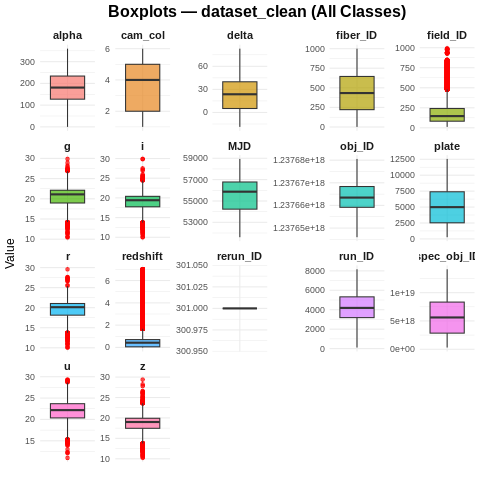

In [148]:
# @title 13.1. Boxplots — dataset_clean
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
file_name   = 'boxplots_clean.png' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)

save_path    <- file.path(save_folder, file_name)
numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]
dataset_long <- pivot_longer(dataset_clean[, numeric_cols], cols = everything(), names_to = 'Feature', values_to = 'Value')

p <- ggplot(dataset_long, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = 'red', outlier.size = 1.5, alpha = 0.7) +
  facet_wrap(~ Feature, scales = 'free') +
  theme_minimal() +
  theme(
    axis.text.x     = element_blank(),
    legend.position = 'none',
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    strip.text      = element_text(face = 'bold', size = 11),
    axis.title.y    = element_text(size = 12)
  ) +
  labs(title = 'Boxplots — dataset_clean (All Classes)', x = '', y = 'Value')

options(repr.plot.width = 20, repr.plot.height = 14)
print(p)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)
ggsave(save_path, plot = p, width = 20, height = 14, dpi = dpi)
cat('==================================================\n')
cat(paste('Folder    :', save_folder, '\n'))
cat(paste('File      :', file_name,   '\n'))
cat(paste('Full path :', save_path,   '\n'))
cat(paste('DPI       :', dpi,         '\n'))
cat('==================================================\n')

In [149]:
# @title 13.2. Boxplot Summary Statistics — dataset_clean
%%R

cat('==================================================\n')
cat('--- Boxplot Summary Statistics : dataset_clean ---\n')
cat('==================================================\n\n')

numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]

for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  q    <- quantile(vals, probs = c(0.25, 0.5, 0.75))
  iqr  <- IQR(vals)
  lower_fence <- q[1] - 1.5 * iqr
  upper_fence <- q[3] + 1.5 * iqr

  outliers   <- vals[vals < lower_fence | vals > upper_fence]
  n_outliers <- length(outliers)

  cat(paste('Feature : ', col, '\n', sep = ''))
  cat(paste('  Min         :', min(vals),  '\n'))
  cat(paste('  Q1          :', q[1],        '\n'))
  cat(paste('  Median      :', q[2],        '\n'))
  cat(paste('  Mean        :', mean(vals),  '\n'))
  cat(paste('  Q3          :', q[3],        '\n'))
  cat(paste('  Max         :', max(vals),   '\n'))
  cat(paste('  IQR         :', iqr,         '\n'))
  cat(paste('  Lower Fence :', lower_fence, '\n'))
  cat(paste('  Upper Fence :', upper_fence, '\n'))
  cat(paste('  Outliers    :', n_outliers,  '\n'))

  if (n_outliers > 0) {
    median_val   <- q[2]
    most_extreme <- outliers[which.max(abs(outliers - median_val))]

    if (most_extreme < 0) {
      direction <- 'negative'
    } else if (most_extreme == max(outliers)) {
      direction <- 'highest'
    } else {
      direction <- 'lowest'
    }

    n_extreme <- sum(outliers == most_extreme)
    cat(paste('  Most Extreme:', most_extreme, paste0('(', direction, ')'), '\n'))
    cat(paste('  Count of Most Extreme Value:', n_extreme, '\n'))
  } else {
    cat('  Most Extreme: None\n')
  }

  cat('--------------------------------------------------\n')
}

--- Boxplot Summary Statistics : dataset_clean ---

Feature : obj_ID
  Min         : 1237645942904389888 
  Q1          : 1237659161195118848 
  Median      : 1237663463144194560 
  Mean        : 1237664721913220352 
  Q3          : 1237668350286775040 
  Max         : 1237680531356386304 
  IQR         : 9189091656192 
  Lower Fence : 1237645377557634560 
  Upper Fence : 1237682133924259328 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : alpha
  Min         : 0.00552782792397011 
  Q1          : 127.519613724158 
  Median      : 180.916980930944 
  Mean        : 177.634040531704 
  Q3          : 233.896314149322 
  Max         : 359.999809770956 
  IQR         : 106.376700425164 
  Lower Fence : -32.0454369135876 
  Upper Fence : 393.461364787067 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : delta
  Min         : -18.7853280771825 
  Q1          : 5.14780389929019 
  Median   

Folder    : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning 
File      : boxplots_GALAXY.png 
Full path : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/boxplots_GALAXY.png 
DPI       : 300 


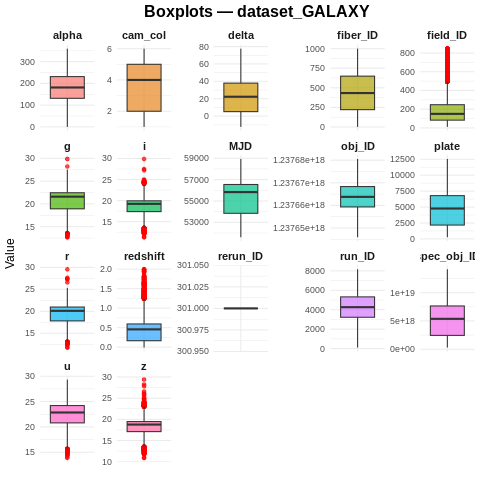

In [150]:
# @title 13.3. Boxplots — dataset_GALAXY
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
file_name   = 'boxplots_GALAXY.png' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)

save_path    <- file.path(save_folder, file_name)
numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]
dataset_long <- pivot_longer(dataset_GALAXY[, numeric_cols], cols = everything(), names_to = 'Feature', values_to = 'Value')

p <- ggplot(dataset_long, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = 'red', outlier.size = 1.5, alpha = 0.7) +
  facet_wrap(~ Feature, scales = 'free') +
  theme_minimal() +
  theme(
    axis.text.x     = element_blank(),
    legend.position = 'none',
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    strip.text      = element_text(face = 'bold', size = 11),
    axis.title.y    = element_text(size = 12)
  ) +
  labs(title = 'Boxplots — dataset_GALAXY', x = '', y = 'Value')

options(repr.plot.width = 20, repr.plot.height = 14)
print(p)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)
ggsave(save_path, plot = p, width = 20, height = 14, dpi = dpi)
cat('==================================================\n')
cat(paste('Folder    :', save_folder, '\n'))
cat(paste('File      :', file_name,   '\n'))
cat(paste('Full path :', save_path,   '\n'))
cat(paste('DPI       :', dpi,         '\n'))
cat('==================================================\n')

In [151]:
# @title 13.4. Boxplot Summary Statistics — dataset_GALAXY
%%R

cat('==================================================\n')
cat('--- Boxplot Summary Statistics : dataset_GALAXY ---\n')
cat('==================================================\n\n')

numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]

for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  q    <- quantile(vals, probs = c(0.25, 0.5, 0.75))
  iqr  <- IQR(vals)
  lower_fence <- q[1] - 1.5 * iqr
  upper_fence <- q[3] + 1.5 * iqr

  outliers   <- vals[vals < lower_fence | vals > upper_fence]
  n_outliers <- length(outliers)

  cat(paste('Feature : ', col, '\n', sep = ''))
  cat(paste('  Min         :', min(vals),  '\n'))
  cat(paste('  Q1          :', q[1],        '\n'))
  cat(paste('  Median      :', q[2],        '\n'))
  cat(paste('  Mean        :', mean(vals),  '\n'))
  cat(paste('  Q3          :', q[3],        '\n'))
  cat(paste('  Max         :', max(vals),   '\n'))
  cat(paste('  IQR         :', iqr,         '\n'))
  cat(paste('  Lower Fence :', lower_fence, '\n'))
  cat(paste('  Upper Fence :', upper_fence, '\n'))
  cat(paste('  Outliers    :', n_outliers,  '\n'))

  if (n_outliers > 0) {
    median_val   <- q[2]
    most_extreme <- outliers[which.max(abs(outliers - median_val))]

    if (most_extreme < 0) {
      direction <- 'negative'
    } else if (most_extreme == max(outliers)) {
      direction <- 'highest'
    } else {
      direction <- 'lowest'
    }

    n_extreme <- sum(outliers == most_extreme)
    cat(paste('  Most Extreme:', most_extreme, paste0('(', direction, ')'), '\n'))
    cat(paste('  Count of Most Extreme Value:', n_extreme, '\n'))
  } else {
    cat('  Most Extreme: None\n')
  }

  cat('--------------------------------------------------\n')
}

--- Boxplot Summary Statistics : dataset_GALAXY ---

Feature : obj_ID
  Min         : 1237645942905438464 
  Q1          : 1237659324943204352 
  Median      : 1237663782600901120 
  Mean        : 1237664861131583488 
  Q3          : 1237668331491525120 
  Max         : 1237680531356386304 
  IQR         : 9006548320768 
  Lower Fence : 1237645815120723200 
  Upper Fence : 1237681841314006272 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : alpha
  Min         : 0.00552782792397011 
  Q1          : 131.506055265727 
  Median      : 181.32304533602 
  Mean        : 177.95579995257 
  Q3          : 231.334957967669 
  Max         : 359.994124543599 
  IQR         : 99.828902701942 
  Lower Fence : -18.237298787186 
  Upper Fence : 381.078312020582 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : delta
  Min         : -12.3647005089841 
  Q1          : 5.16700123420781 
  Median      

Folder    : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning 
File      : boxplots_QSO.png 
Full path : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/boxplots_QSO.png 
DPI       : 300 


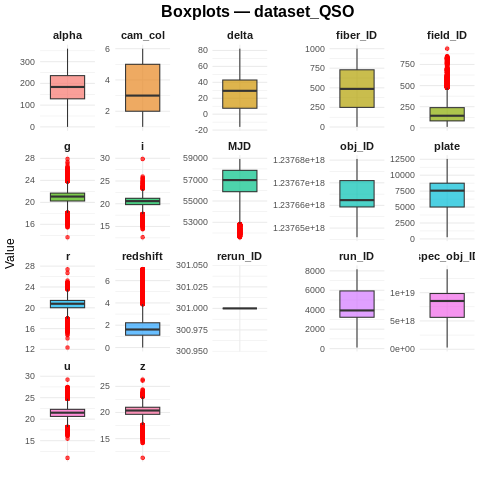

In [152]:
# @title 13.5. Boxplots — dataset_QSO
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
file_name   = 'boxplots_QSO.png' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)

save_path    <- file.path(save_folder, file_name)
numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]
dataset_long <- pivot_longer(dataset_QSO[, numeric_cols], cols = everything(), names_to = 'Feature', values_to = 'Value')

p <- ggplot(dataset_long, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = 'red', outlier.size = 1.5, alpha = 0.7) +
  facet_wrap(~ Feature, scales = 'free') +
  theme_minimal() +
  theme(
    axis.text.x     = element_blank(),
    legend.position = 'none',
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    strip.text      = element_text(face = 'bold', size = 11),
    axis.title.y    = element_text(size = 12)
  ) +
  labs(title = 'Boxplots — dataset_QSO', x = '', y = 'Value')

options(repr.plot.width = 20, repr.plot.height = 14)
print(p)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)
ggsave(save_path, plot = p, width = 20, height = 14, dpi = dpi)
cat('==================================================\n')
cat(paste('Folder    :', save_folder, '\n'))
cat(paste('File      :', file_name,   '\n'))
cat(paste('Full path :', save_path,   '\n'))
cat(paste('DPI       :', dpi,         '\n'))
cat('==================================================\n')

In [153]:
# @title 13.6. Boxplot Summary Statistics — dataset_QSO
%%R

cat('==================================================\n')
cat('--- Boxplot Summary Statistics : dataset_QSO ---\n')
cat('==================================================\n\n')

numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]

for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  q    <- quantile(vals, probs = c(0.25, 0.5, 0.75))
  iqr  <- IQR(vals)
  lower_fence <- q[1] - 1.5 * iqr
  upper_fence <- q[3] + 1.5 * iqr

  outliers   <- vals[vals < lower_fence | vals > upper_fence]
  n_outliers <- length(outliers)

  cat(paste('Feature : ', col, '\n', sep = ''))
  cat(paste('  Min         :', min(vals),  '\n'))
  cat(paste('  Q1          :', q[1],        '\n'))
  cat(paste('  Median      :', q[2],        '\n'))
  cat(paste('  Mean        :', mean(vals),  '\n'))
  cat(paste('  Q3          :', q[3],        '\n'))
  cat(paste('  Max         :', max(vals),   '\n'))
  cat(paste('  IQR         :', iqr,         '\n'))
  cat(paste('  Lower Fence :', lower_fence, '\n'))
  cat(paste('  Upper Fence :', upper_fence, '\n'))
  cat(paste('  Outliers    :', n_outliers,  '\n'))

  if (n_outliers > 0) {
    median_val   <- q[2]
    most_extreme <- outliers[which.max(abs(outliers - median_val))]

    if (most_extreme < 0) {
      direction <- 'negative'
    } else if (most_extreme == max(outliers)) {
      direction <- 'highest'
    } else {
      direction <- 'lowest'
    }

    n_extreme <- sum(outliers == most_extreme)
    cat(paste('  Most Extreme:', most_extreme, paste0('(', direction, ')'), '\n'))
    cat(paste('  Count of Most Extreme Value:', n_extreme, '\n'))
  } else {
    cat('  Most Extreme: None\n')
  }

  cat('--------------------------------------------------\n')
}

--- Boxplot Summary Statistics : dataset_QSO ---

Feature : obj_ID
  Min         : 1237645942905700608 
  Q1          : 1237659324420179712 
  Median      : 1237662337865351424 
  Mean        : 1237665157046610688 
  Q3          : 1237670965380121600 
  Max         : 1237680529745839360 
  IQR         : 11640959941888 
  Lower Fence : 1237641862980267008 
  Upper Fence : 1237688426820034560 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : alpha
  Min         : 0.0109586937406903 
  Q1          : 129.152452649453 
  Median      : 183.696310101663 
  Mean        : 180.486744459578 
  Q3          : 235.873621614741 
  Max         : 359.99961524169 
  IQR         : 106.721168965287 
  Lower Fence : -30.929300798477 
  Upper Fence : 395.955375062671 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : delta
  Min         : -15.9809039198368 
  Q1          : 7.42868339967088 
  Median      :

Folder    : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning 
File      : boxplots_STAR.png 
Full path : /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/boxplots_STAR.png 
DPI       : 300 


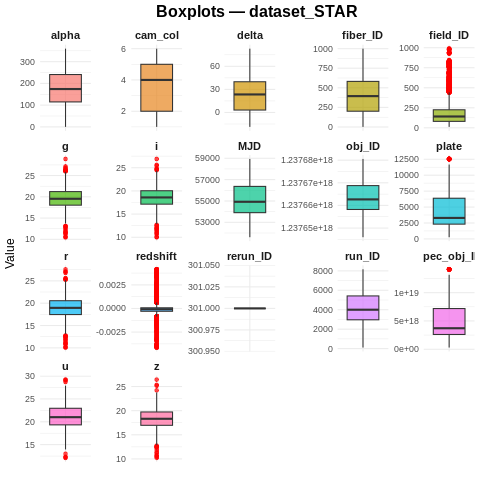

In [154]:
# @title 13.7. Boxplots — dataset_STAR
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
file_name   = 'boxplots_STAR.png' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)

save_path    <- file.path(save_folder, file_name)
numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]
dataset_long <- pivot_longer(dataset_STAR[, numeric_cols], cols = everything(), names_to = 'Feature', values_to = 'Value')

p <- ggplot(dataset_long, aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(outlier.colour = 'red', outlier.size = 1.5, alpha = 0.7) +
  facet_wrap(~ Feature, scales = 'free') +
  theme_minimal() +
  theme(
    axis.text.x     = element_blank(),
    legend.position = 'none',
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    strip.text      = element_text(face = 'bold', size = 11),
    axis.title.y    = element_text(size = 12)
  ) +
  labs(title = 'Boxplots — dataset_STAR', x = '', y = 'Value')

options(repr.plot.width = 20, repr.plot.height = 14)
print(p)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)
ggsave(save_path, plot = p, width = 20, height = 14, dpi = dpi)
cat('==================================================\n')
cat(paste('Folder    :', save_folder, '\n'))
cat(paste('File      :', file_name,   '\n'))
cat(paste('Full path :', save_path,   '\n'))
cat(paste('DPI       :', dpi,         '\n'))
cat('==================================================\n')

In [155]:
# @title 13.8. Boxplot Summary Statistics — dataset_STAR
%%R

cat('==================================================\n')
cat('--- Boxplot Summary Statistics : dataset_STAR ---\n')
cat('==================================================\n\n')

numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]

for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  q    <- quantile(vals, probs = c(0.25, 0.5, 0.75))
  iqr  <- IQR(vals)
  lower_fence <- q[1] - 1.5 * iqr
  upper_fence <- q[3] + 1.5 * iqr

  outliers   <- vals[vals < lower_fence | vals > upper_fence]
  n_outliers <- length(outliers)

  cat(paste('Feature : ', col, '\n', sep = ''))
  cat(paste('  Min         :', min(vals),  '\n'))
  cat(paste('  Q1          :', q[1],        '\n'))
  cat(paste('  Median      :', q[2],        '\n'))
  cat(paste('  Mean        :', mean(vals),  '\n'))
  cat(paste('  Q3          :', q[3],        '\n'))
  cat(paste('  Max         :', max(vals),   '\n'))
  cat(paste('  IQR         :', iqr,         '\n'))
  cat(paste('  Lower Fence :', lower_fence, '\n'))
  cat(paste('  Upper Fence :', upper_fence, '\n'))
  cat(paste('  Outliers    :', n_outliers,  '\n'))

  if (n_outliers > 0) {
    median_val   <- q[2]
    most_extreme <- outliers[which.max(abs(outliers - median_val))]

    if (most_extreme < 0) {
      direction <- 'negative'
    } else if (most_extreme == max(outliers)) {
      direction <- 'highest'
    } else {
      direction <- 'lowest'
    }

    n_extreme <- sum(outliers == most_extreme)
    cat(paste('  Most Extreme:', most_extreme, paste0('(', direction, ')'), '\n'))
    cat(paste('  Count of Most Extreme Value:', n_extreme, '\n'))
  } else {
    cat('  Most Extreme: None\n')
  }

  cat('--------------------------------------------------\n')
}

--- Boxplot Summary Statistics : dataset_STAR ---

Feature : obj_ID
  Min         : 1237645942904389888 
  Q1          : 1237658206112186368 
  Median      : 1237662663210108160 
  Mean        : 1237663956556545536 
  Q3          : 1237668758848537600 
  Max         : 1237680531355009536 
  IQR         : 10552736351232 
  Lower Fence : 1237642377007659520 
  Upper Fence : 1237684587953064448 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : alpha
  Min         : 0.0298381739607976 
  Q1          : 114.90163003798 
  Median      : 174.153831333638 
  Mean        : 174.243372831311 
  Q3          : 240.862264195141 
  Max         : 359.999809770956 
  IQR         : 125.960634157161 
  Lower Fence : -74.0393211977615 
  Upper Fence : 429.803215430882 
  Outliers    : 0 
  Most Extreme: None
--------------------------------------------------
Feature : delta
  Min         : -18.7853280771825 
  Q1          : 3.12931722368003 
  Median     

---

# **Descriptive Statistics Section**

---

In [156]:
# @title 14.1. Statistics — dataset_clean
%%R
library(dplyr)
library(moments)

cat('==================================================\n')
cat('--- Full Statistics Report : dataset_clean ---\n')
cat('==================================================\n')
cat(sprintf('Total rows : %d\n', nrow(dataset_clean)))
cat(sprintf('Columns    : %d\n\n', ncol(dataset_clean)))

numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]
bands        <- c('u', 'g', 'r', 'i', 'z')

# =====================================================
# 1. Core Descriptives — Mean, SD, Min, Max, IQR
# =====================================================
cat('==================================================\n')
cat('--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---\n')
cat('==================================================\n')
for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min    : %s\n', min(vals)))
  cat(sprintf('  Max    : %s\n', max(vals)))
  cat(sprintf('  Mean   : %s\n', mean(vals)))
  cat(sprintf('  SD     : %s\n', sd(vals)))
  cat(sprintf('  IQR    : %s\n', IQR(vals)))
  cat('--------------------------------------------------\n')
}

# =====================================================
# 2. Skewness & Kurtosis
# =====================================================
cat('\n==================================================\n')
cat('--- 2. Skewness & Kurtosis ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Skewness', 'Kurtosis'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  cat(sprintf('%-20s %12.4f %12.4f\n', col, skewness(vals), kurtosis(vals)))
}

# =====================================================
# 3. Pearson Correlation with redshift
# =====================================================
cat('\n==================================================\n')
cat('--- 3. Pearson Correlation with redshift ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Correlation', 'p-value'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  if (col != 'redshift') {
    ct <- cor.test(dataset_clean[[col]], dataset_clean$redshift)
    sig <- ifelse(ct$p.value < 0.05, '*', ' ')
    cat(sprintf('%-20s %12.4f %12.4e %s\n', col, ct$estimate, ct$p.value, sig))
  }
}
cat('* = statistically significant (p < 0.05)\n')

# =====================================================
# 4. Coefficient of Variation (CV)
# =====================================================
cat('\n==================================================\n')
cat('--- 4. Coefficient of Variation (CV = SD/Mean * 100) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s\n', 'Feature', 'CV (%)'))
cat(paste(rep('-', 34), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  cv   <- (sd(vals) / abs(mean(vals))) * 100
  cat(sprintf('%-20s %12.4f%%\n', col, cv))
}

# =====================================================
# 5. Relative Frequency (Class Distribution)
# =====================================================
cat('\n==================================================\n')
cat('--- 5. Relative Frequency (Class Distribution) ---\n')
cat('==================================================\n')
class_counts <- table(dataset_clean$class)
class_pct    <- prop.table(class_counts) * 100
cat(sprintf('%-12s %10s %12s\n', 'Class', 'Count', 'Percentage'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (cls in names(class_counts)) {
  cat(sprintf('%-12s %10d %11.2f%%\n', cls, class_counts[cls], class_pct[cls]))
}
cat(paste(rep('-', 36), collapse = ''), '\n')
cat(sprintf('%-12s %10d %11.2f%%\n', 'Total', sum(class_counts), 100.00))

# =====================================================
# 6. Z-score Summary (mean of abs z-scores per feature)
# =====================================================
cat('\n==================================================\n')
cat('--- 6. Z-score Summary ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s %12s\n', 'Feature', 'Mean |Z|', 'Max |Z|', 'N Extreme'))
cat(paste(rep('-', 58), collapse = ''), '\n')
for (col in numeric_cols) {
  vals    <- dataset_clean[[col]]
  z       <- abs((vals - mean(vals)) / sd(vals))
  n_ext   <- sum(z > 3)
  cat(sprintf('%-20s %12.4f %12.4f %12d\n', col, mean(z), max(z), n_ext))
}
cat('N Extreme = rows with |Z| > 3\n')

# =====================================================
# 7. Percentiles — P10, P25, P75, P90
# =====================================================
cat('\n==================================================\n')
cat('--- 7. Percentiles (P10, P25, P75, P90) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %10s %10s %10s %10s\n', 'Feature', 'P10', 'P25', 'P75', 'P90'))
cat(paste(rep('-', 62), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  p    <- quantile(vals, probs = c(0.10, 0.25, 0.75, 0.90))
  cat(sprintf('%-20s %10.4f %10.4f %10.4f %10.4f\n',
      col, p[1], p[2], p[3], p[4]))
}

--- Full Statistics Report : dataset_clean ---
Total rows : 99992
Columns    : 18

--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---
Feature : obj_ID
  Min    : 1237645942904389888
  Max    : 1237680531356386304
  Mean   : 1237664721913220352
  SD     : 8438718221688.52
  IQR    : 9189091656192
--------------------------------------------------
Feature : alpha
  Min    : 0.00552782792397011
  Max    : 359.999809770956
  Mean   : 177.634040531704
  SD     : 96.5026681192555
  IQR    : 106.376700425164
--------------------------------------------------
Feature : delta
  Min    : -18.7853280771825
  Max    : 83.00051858898
  Mean   : 24.1361545203415
  SD     : 19.6449214033766
  IQR    : 34.7544165290356
--------------------------------------------------
Feature : u
  Min    : 10.99623
  Max    : 29.32565
  Mean   : 22.0806859693776
  SD     : 2.25050465992609
  IQR    : 3.3348725
--------------------------------------------------
Feature : g
  Min    : 10.4982
  Max    : 29.86258
 

In addition: Warning message:
In cor(x, y) : the standard deviation is zero


In [157]:
# @title 14.2. Statistics — dataset_GALAXY
%%R
library(dplyr)
library(moments)

cat('==================================================\n')
cat('--- Full Statistics Report : dataset_GALAXY ---\n')
cat('==================================================\n')
cat(sprintf('Total rows : %d\n', nrow(dataset_GALAXY)))
cat(sprintf('Columns    : %d\n\n', ncol(dataset_GALAXY)))

numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]

# =====================================================
# 1. Core Descriptives
# =====================================================
cat('==================================================\n')
cat('--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---\n')
cat('==================================================\n')
for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min    : %s\n', min(vals)))
  cat(sprintf('  Max    : %s\n', max(vals)))
  cat(sprintf('  Mean   : %s\n', mean(vals)))
  cat(sprintf('  SD     : %s\n', sd(vals)))
  cat(sprintf('  IQR    : %s\n', IQR(vals)))
  cat('--------------------------------------------------\n')
}

# =====================================================
# 2. Skewness & Kurtosis
# =====================================================
cat('\n==================================================\n')
cat('--- 2. Skewness & Kurtosis ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Skewness', 'Kurtosis'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  cat(sprintf('%-20s %12.4f %12.4f\n', col, skewness(vals), kurtosis(vals)))
}

# =====================================================
# 3. Pearson Correlation with redshift
# =====================================================
cat('\n==================================================\n')
cat('--- 3. Pearson Correlation with redshift ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Correlation', 'p-value'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  if (col != 'redshift') {
    ct  <- cor.test(dataset_GALAXY[[col]], dataset_GALAXY$redshift)
    sig <- ifelse(ct$p.value < 0.05, '*', ' ')
    cat(sprintf('%-20s %12.4f %12.4e %s\n', col, ct$estimate, ct$p.value, sig))
  }
}
cat('* = statistically significant (p < 0.05)\n')

# =====================================================
# 4. Coefficient of Variation
# =====================================================
cat('\n==================================================\n')
cat('--- 4. Coefficient of Variation (CV = SD/Mean * 100) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s\n', 'Feature', 'CV (%)'))
cat(paste(rep('-', 34), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  cv   <- (sd(vals) / abs(mean(vals))) * 100
  cat(sprintf('%-20s %12.4f%%\n', col, cv))
}

# =====================================================
# 5. Relative Frequency (Class Distribution)
# =====================================================
cat('\n==================================================\n')
cat('--- 5. Relative Frequency (Class Distribution) ---\n')
cat('==================================================\n')
cat(sprintf('  Class  : GALAXY\n'))
cat(sprintf('  Count  : %d\n', nrow(dataset_GALAXY)))
cat(sprintf('  Pct    : 100.00%% (single class dataset)\n'))

# =====================================================
# 6. Z-score Summary
# =====================================================
cat('\n==================================================\n')
cat('--- 6. Z-score Summary ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s %12s\n', 'Feature', 'Mean |Z|', 'Max |Z|', 'N Extreme'))
cat(paste(rep('-', 58), collapse = ''), '\n')
for (col in numeric_cols) {
  vals  <- dataset_GALAXY[[col]]
  z     <- abs((vals - mean(vals)) / sd(vals))
  n_ext <- sum(z > 3)
  cat(sprintf('%-20s %12.4f %12.4f %12d\n', col, mean(z), max(z), n_ext))
}
cat('N Extreme = rows with |Z| > 3\n')

# =====================================================
# 7. Percentiles
# =====================================================
cat('\n==================================================\n')
cat('--- 7. Percentiles (P10, P25, P75, P90) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %10s %10s %10s %10s\n', 'Feature', 'P10', 'P25', 'P75', 'P90'))
cat(paste(rep('-', 62), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  p    <- quantile(vals, probs = c(0.10, 0.25, 0.75, 0.90))
  cat(sprintf('%-20s %10.4f %10.4f %10.4f %10.4f\n',
      col, p[1], p[2], p[3], p[4]))
}

--- Full Statistics Report : dataset_GALAXY ---
Total rows : 59443
Columns    : 18

--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---
Feature : obj_ID
  Min    : 1237645942905438464
  Max    : 1237680531356386304
  Mean   : 1237664861131583488
  SD     : 8399671927638.63
  IQR    : 9006548320768
--------------------------------------------------
Feature : alpha
  Min    : 0.00552782792397011
  Max    : 359.994124543599
  Mean   : 177.95579995257
  SD     : 94.4051670225727
  IQR    : 99.828902701942
--------------------------------------------------
Feature : delta
  Min    : -12.3647005089841
  Max    : 77.615587878828
  Mean   : 23.5137523356712
  SD     : 19.3154990572823
  IQR    : 32.8062685386868
--------------------------------------------------
Feature : u
  Min    : 13.89799
  Max    : 29.32565
  Mean   : 22.5875108320576
  SD     : 2.2642793834244
  IQR    : 3.412625
--------------------------------------------------
Feature : g
  Min    : 12.67902
  Max    : 29.86258
  

In addition: Warning message:
In cor(x, y) : the standard deviation is zero


In [158]:
# @title 14.3. Statistics — dataset_QSO
%%R
library(dplyr)
library(moments)

cat('==================================================\n')
cat('--- Full Statistics Report : dataset_QSO ---\n')
cat('==================================================\n')
cat(sprintf('Total rows : %d\n', nrow(dataset_QSO)))
cat(sprintf('Columns    : %d\n\n', ncol(dataset_QSO)))

numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]

# =====================================================
# 1. Core Descriptives
# =====================================================
cat('==================================================\n')
cat('--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---\n')
cat('==================================================\n')
for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min    : %s\n', min(vals)))
  cat(sprintf('  Max    : %s\n', max(vals)))
  cat(sprintf('  Mean   : %s\n', mean(vals)))
  cat(sprintf('  SD     : %s\n', sd(vals)))
  cat(sprintf('  IQR    : %s\n', IQR(vals)))
  cat('--------------------------------------------------\n')
}

# =====================================================
# 2. Skewness & Kurtosis
# =====================================================
cat('\n==================================================\n')
cat('--- 2. Skewness & Kurtosis ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Skewness', 'Kurtosis'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  cat(sprintf('%-20s %12.4f %12.4f\n', col, skewness(vals), kurtosis(vals)))
}

# =====================================================
# 3. Pearson Correlation with redshift
# =====================================================
cat('\n==================================================\n')
cat('--- 3. Pearson Correlation with redshift ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Correlation', 'p-value'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  if (col != 'redshift') {
    ct  <- cor.test(dataset_QSO[[col]], dataset_QSO$redshift)
    sig <- ifelse(ct$p.value < 0.05, '*', ' ')
    cat(sprintf('%-20s %12.4f %12.4e %s\n', col, ct$estimate, ct$p.value, sig))
  }
}
cat('* = statistically significant (p < 0.05)\n')

# =====================================================
# 4. Coefficient of Variation
# =====================================================
cat('\n==================================================\n')
cat('--- 4. Coefficient of Variation (CV = SD/Mean * 100) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s\n', 'Feature', 'CV (%)'))
cat(paste(rep('-', 34), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  cv   <- (sd(vals) / abs(mean(vals))) * 100
  cat(sprintf('%-20s %12.4f%%\n', col, cv))
}

# =====================================================
# 5. Relative Frequency (Class Distribution)
# =====================================================
cat('\n==================================================\n')
cat('--- 5. Relative Frequency (Class Distribution) ---\n')
cat('==================================================\n')
cat(sprintf('  Class  : QSO\n'))
cat(sprintf('  Count  : %d\n', nrow(dataset_QSO)))
cat(sprintf('  Pct    : 100.00%% (single class dataset)\n'))

# =====================================================
# 6. Z-score Summary
# =====================================================
cat('\n==================================================\n')
cat('--- 6. Z-score Summary ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s %12s\n', 'Feature', 'Mean |Z|', 'Max |Z|', 'N Extreme'))
cat(paste(rep('-', 58), collapse = ''), '\n')
for (col in numeric_cols) {
  vals  <- dataset_QSO[[col]]
  z     <- abs((vals - mean(vals)) / sd(vals))
  n_ext <- sum(z > 3)
  cat(sprintf('%-20s %12.4f %12.4f %12d\n', col, mean(z), max(z), n_ext))
}
cat('N Extreme = rows with |Z| > 3\n')

# =====================================================
# 7. Percentiles
# =====================================================
cat('\n==================================================\n')
cat('--- 7. Percentiles (P10, P25, P75, P90) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %10s %10s %10s %10s\n', 'Feature', 'P10', 'P25', 'P75', 'P90'))
cat(paste(rep('-', 62), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  p    <- quantile(vals, probs = c(0.10, 0.25, 0.75, 0.90))
  cat(sprintf('%-20s %10.4f %10.4f %10.4f %10.4f\n',
      col, p[1], p[2], p[3], p[4]))
}

--- Full Statistics Report : dataset_QSO ---
Total rows : 18958
Columns    : 18

--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---
Feature : obj_ID
  Min    : 1237645942905700608
  Max    : 1237680529745839360
  Mean   : 1237665157046610688
  SD     : 8660556937089.71
  IQR    : 11640959941888
--------------------------------------------------
Feature : alpha
  Min    : 0.0109586937406903
  Max    : 359.99961524169
  Mean   : 180.486744459578
  SD     : 98.9620068667905
  IQR    : 106.721168965287
--------------------------------------------------
Feature : delta
  Min    : -15.9809039198368
  Max    : 82.2886569832097
  Mean   : 26.8105323858809
  SD     : 19.5889442327269
  IQR    : 35.4603630171784
--------------------------------------------------
Feature : u
  Min    : 10.99623
  Max    : 29.19901
  Mean   : 21.547246623589
  SD     : 1.49359413411509
  IQR    : 1.648535
--------------------------------------------------
Feature : g
  Min    : 13.66217
  Max    : 27.89482
  M

In addition: Warning message:
In cor(x, y) : the standard deviation is zero


In [159]:
# @title 14.4. Statistics — dataset_STAR
%%R
library(dplyr)
library(moments)

cat('==================================================\n')
cat('--- Full Statistics Report : dataset_STAR ---\n')
cat('==================================================\n')
cat(sprintf('Total rows : %d\n', nrow(dataset_STAR)))
cat(sprintf('Columns    : %d\n\n', ncol(dataset_STAR)))

numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]

# =====================================================
# 1. Core Descriptives
# =====================================================
cat('==================================================\n')
cat('--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---\n')
cat('==================================================\n')
for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min    : %s\n', min(vals)))
  cat(sprintf('  Max    : %s\n', max(vals)))
  cat(sprintf('  Mean   : %s\n', mean(vals)))
  cat(sprintf('  SD     : %s\n', sd(vals)))
  cat(sprintf('  IQR    : %s\n', IQR(vals)))
  cat('--------------------------------------------------\n')
}

# =====================================================
# 2. Skewness & Kurtosis
# =====================================================
cat('\n==================================================\n')
cat('--- 2. Skewness & Kurtosis ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Skewness', 'Kurtosis'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  cat(sprintf('%-20s %12.4f %12.4f\n', col, skewness(vals), kurtosis(vals)))
}

# =====================================================
# 3. Pearson Correlation with redshift
# =====================================================
cat('\n==================================================\n')
cat('--- 3. Pearson Correlation with redshift ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s\n', 'Feature', 'Correlation', 'p-value'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (col in numeric_cols) {
  if (col != 'redshift') {
    ct  <- cor.test(dataset_STAR[[col]], dataset_STAR$redshift)
    sig <- ifelse(ct$p.value < 0.05, '*', ' ')
    cat(sprintf('%-20s %12.4f %12.4e %s\n', col, ct$estimate, ct$p.value, sig))
  }
}
cat('* = statistically significant (p < 0.05)\n')

# =====================================================
# 4. Coefficient of Variation
# =====================================================
cat('\n==================================================\n')
cat('--- 4. Coefficient of Variation (CV = SD/Mean * 100) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s\n', 'Feature', 'CV (%)'))
cat(paste(rep('-', 34), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  cv   <- (sd(vals) / abs(mean(vals))) * 100
  cat(sprintf('%-20s %12.4f%%\n', col, cv))
}

# =====================================================
# 5. Relative Frequency (Class Distribution)
# =====================================================
cat('\n==================================================\n')
cat('--- 5. Relative Frequency (Class Distribution) ---\n')
cat('==================================================\n')
cat(sprintf('  Class  : STAR\n'))
cat(sprintf('  Count  : %d\n', nrow(dataset_STAR)))
cat(sprintf('  Pct    : 100.00%% (single class dataset)\n'))

# =====================================================
# 6. Z-score Summary
# =====================================================
cat('\n==================================================\n')
cat('--- 6. Z-score Summary ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %12s %12s %12s\n', 'Feature', 'Mean |Z|', 'Max |Z|', 'N Extreme'))
cat(paste(rep('-', 58), collapse = ''), '\n')
for (col in numeric_cols) {
  vals  <- dataset_STAR[[col]]
  z     <- abs((vals - mean(vals)) / sd(vals))
  n_ext <- sum(z > 3)
  cat(sprintf('%-20s %12.4f %12.4f %12d\n', col, mean(z), max(z), n_ext))
}
cat('N Extreme = rows with |Z| > 3\n')

# =====================================================
# 7. Percentiles
# =====================================================
cat('\n==================================================\n')
cat('--- 7. Percentiles (P10, P25, P75, P90) ---\n')
cat('==================================================\n')
cat(sprintf('%-20s %10s %10s %10s %10s\n', 'Feature', 'P10', 'P25', 'P75', 'P90'))
cat(paste(rep('-', 62), collapse = ''), '\n')
for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  p    <- quantile(vals, probs = c(0.10, 0.25, 0.75, 0.90))
  cat(sprintf('%-20s %10.4f %10.4f %10.4f %10.4f\n',
      col, p[1], p[2], p[3], p[4]))
}

--- Full Statistics Report : dataset_STAR ---
Total rows : 21591
Columns    : 18

--- 1. Core Descriptives (Mean, SD, Min, Max, IQR) ---
Feature : obj_ID
  Min    : 1237645942904389888
  Max    : 1237680531355009536
  Mean   : 1237663956556545536
  SD     : 8300159423703.49
  IQR    : 10552736351232
--------------------------------------------------
Feature : alpha
  Min    : 0.0298381739607976
  Max    : 359.999809770956
  Mean   : 174.243372831311
  SD     : 99.8753266414755
  IQR    : 125.960634157161
--------------------------------------------------
Feature : delta
  Min    : -18.7853280771825
  Max    : 83.00051858898
  Mean   : 23.5014732868858
  SD     : 20.3831615156123
  IQR    : 36.8108635397509
--------------------------------------------------
Feature : u
  Min    : 12.10168
  Max    : 29.23438
  Mean   : 21.1537142128665
  SD     : 2.35922306469328
  IQR    : 3.632865
--------------------------------------------------
Feature : g
  Min    : 10.4982
  Max    : 28.9032
  Me

In addition: Warning message:
In cor(x, y) : the standard deviation is zero


---

# **Statistics Graphs Section**

---

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/stats_graphs_clean.png 
DPI    :  300 


In addition: There were 17 warnings (use warnings() to see them)


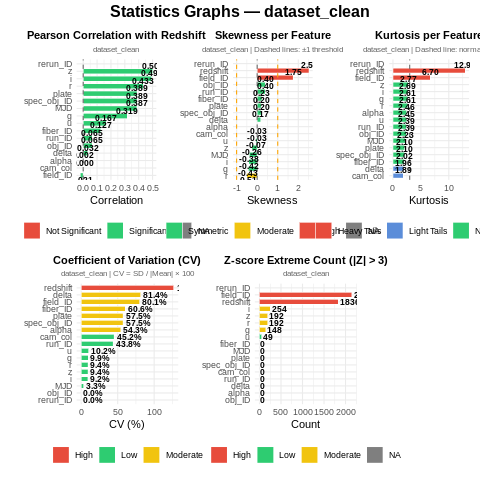

In [160]:
# @title 15.1. Statistics Graphs — dataset_clean
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
if (!require('moments',   quietly = TRUE)) install.packages('moments',   quiet = TRUE)

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(moments)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]
DATASET_NAME <- 'dataset_clean'

# =====================================================
# 1. Pearson Correlation with redshift
# =====================================================
cor_df <- do.call(rbind, lapply(numeric_cols[numeric_cols != 'redshift'], function(col) {
  ct <- cor.test(dataset_clean[[col]], dataset_clean$redshift)
  data.frame(
    Feature     = col,
    Correlation = round(ct$estimate, 4),
    Significant = ct$p.value < 0.05,
    stringsAsFactors = FALSE
  )
}))
cor_df$Feature <- factor(cor_df$Feature, levels = cor_df$Feature[order(cor_df$Correlation)])

p1 <- ggplot(cor_df, aes(x = Feature, y = Correlation, fill = Significant)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.3f', Correlation),
                vjust = ifelse(Correlation >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('TRUE' = '#2ECC71', 'FALSE' = '#E74C3C'),
                    labels = c('TRUE' = 'Significant', 'FALSE' = 'Not Significant')) +
  coord_flip() +
  theme_minimal() +
  theme(plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom',
        legend.title    = element_blank()) +
  labs(title    = 'Pearson Correlation with Redshift',
       subtitle = DATASET_NAME,
       x = '', y = 'Correlation')

# =====================================================
# 2. Skewness
# =====================================================
skew_df <- data.frame(
  Feature  = numeric_cols,
  Skewness = sapply(numeric_cols, function(col) round(skewness(dataset_clean[[col]]), 4)),
  stringsAsFactors = FALSE
)
skew_df$Feature  <- factor(skew_df$Feature, levels = skew_df$Feature[order(skew_df$Skewness)])
skew_df$Category <- ifelse(abs(skew_df$Skewness) <= 0.5, 'Symmetric',
                    ifelse(abs(skew_df$Skewness) <= 1.0, 'Moderate', 'High'))
skew_df$Category <- factor(skew_df$Category, levels = c('Symmetric', 'Moderate', 'High'))

p2 <- ggplot(skew_df, aes(x = Feature, y = Skewness, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 0, 1), linetype = 'dashed',
             color = c('orange', 'gray40', 'orange')) +
  geom_text(aes(label = sprintf('%.2f', Skewness),
                vjust = ifelse(Skewness >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Symmetric' = '#2ECC71',
                                'Moderate'  = '#F1C40F',
                                'High'      = '#E74C3C')) +
  coord_flip() +
  theme_minimal() +
  theme(plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom',
        legend.title    = element_blank()) +
  labs(title    = 'Skewness per Feature',
       subtitle = paste(DATASET_NAME, '| Dashed lines: ±1 threshold'),
       x = '', y = 'Skewness')

# =====================================================
# 3. Kurtosis
# =====================================================
kurt_df <- data.frame(
  Feature  = numeric_cols,
  Kurtosis = sapply(numeric_cols, function(col) round(kurtosis(dataset_clean[[col]]), 4)),
  stringsAsFactors = FALSE
)
kurt_df$Feature  <- factor(kurt_df$Feature, levels = kurt_df$Feature[order(kurt_df$Kurtosis)])
kurt_df$Category <- ifelse(abs(kurt_df$Kurtosis - 3) <= 1, 'Normal',
                    ifelse(kurt_df$Kurtosis > 3, 'Heavy Tails', 'Light Tails'))

p3 <- ggplot(kurt_df, aes(x = Feature, y = Kurtosis, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 3, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.2f', Kurtosis),
                vjust = ifelse(Kurtosis >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Normal'      = '#2ECC71',
                                'Heavy Tails' = '#E74C3C',
                                'Light Tails' = '#5B8DD9')) +
  coord_flip() +
  theme_minimal() +
  theme(plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom',
        legend.title    = element_blank()) +
  labs(title    = 'Kurtosis per Feature',
       subtitle = paste(DATASET_NAME, '| Dashed line: normal = 3'),
       x = '', y = 'Kurtosis')

# =====================================================
# 4. Coefficient of Variation
# =====================================================
cv_df <- data.frame(
  Feature = numeric_cols,
  CV      = sapply(numeric_cols, function(col) {
    vals <- dataset_clean[[col]]
    round((sd(vals) / abs(mean(vals))) * 100, 4)
  }),
  stringsAsFactors = FALSE
)
cv_df$Feature <- factor(cv_df$Feature, levels = cv_df$Feature[order(cv_df$CV)])

p4 <- ggplot(cv_df, aes(x = Feature, y = CV,
                         fill = ifelse(CV > 100, 'High', ifelse(CV > 50, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.1f%%', CV)), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C'),
                    name = 'CV Level') +
  coord_flip() +
  theme_minimal() +
  theme(plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom',
        legend.title    = element_blank()) +
  labs(title    = 'Coefficient of Variation (CV)',
       subtitle = paste(DATASET_NAME, '| CV = SD / |Mean| × 100'),
       x = '', y = 'CV (%)')

# =====================================================
# 5. Z-score Extreme Count
# =====================================================
z_df <- data.frame(
  Feature   = numeric_cols,
  N_Extreme = sapply(numeric_cols, function(col) {
    vals <- dataset_clean[[col]]
    sum(abs((vals - mean(vals)) / sd(vals)) > 3)
  }),
  stringsAsFactors = FALSE
)
z_df$Feature <- factor(z_df$Feature, levels = z_df$Feature[order(z_df$N_Extreme)])

p5 <- ggplot(z_df, aes(x = Feature, y = N_Extreme,
                        fill = ifelse(N_Extreme > 1000, 'High',
                               ifelse(N_Extreme > 100,  'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = N_Extreme), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C'),
                    name = '') +
  coord_flip() +
  theme_minimal() +
  theme(plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom',
        legend.title    = element_blank()) +
  labs(title    = 'Z-score Extreme Count (|Z| > 3)',
       subtitle = DATASET_NAME,
       x = '', y = 'Count')

# =====================================================
# Combine & Save
# =====================================================
combined <- (p1 | p2 | p3) / (p4 | p5 | plot_spacer()) +
  plot_annotation(
    title   = paste('Statistics Graphs —', DATASET_NAME),
    theme   = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5))
  )

options(repr.plot.width = 24, repr.plot.height = 18)
print(combined)

tmp_path   <- '/tmp/stats_graphs_clean.png'
drive_path <- file.path(save_folder, 'stats_graphs_clean.png')
ggsave(tmp_path,   plot = combined, width = 24, height = 18, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat('==================================================\n')
cat(paste('Saved → ', drive_path, '\n'))
cat(paste('DPI    : ', dpi, '\n'))
cat('==================================================\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/stats_graphs_GALAXY.png 
DPI    :  300 


In addition: There were 17 warnings (use warnings() to see them)


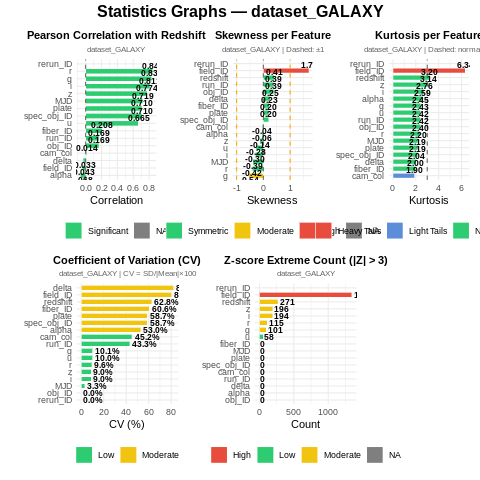

In [161]:
# @title 15.2. Statistics Graphs — dataset_GALAXY
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
if (!require('moments',   quietly = TRUE)) install.packages('moments',   quiet = TRUE)

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(moments)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]
DATASET_NAME <- 'dataset_GALAXY'

cor_df <- do.call(rbind, lapply(numeric_cols[numeric_cols != 'redshift'], function(col) {
  ct <- cor.test(dataset_GALAXY[[col]], dataset_GALAXY$redshift)
  data.frame(Feature = col, Correlation = round(ct$estimate, 4),
             Significant = ct$p.value < 0.05, stringsAsFactors = FALSE)
}))
cor_df$Feature <- factor(cor_df$Feature, levels = cor_df$Feature[order(cor_df$Correlation)])

p1 <- ggplot(cor_df, aes(x = Feature, y = Correlation, fill = Significant)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.3f', Correlation),
                vjust = ifelse(Correlation >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('TRUE' = '#2ECC71', 'FALSE' = '#E74C3C'),
                    labels = c('TRUE' = 'Significant', 'FALSE' = 'Not Significant')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Pearson Correlation with Redshift', subtitle = DATASET_NAME, x = '', y = 'Correlation')

skew_df <- data.frame(
  Feature  = numeric_cols,
  Skewness = sapply(numeric_cols, function(col) round(skewness(dataset_GALAXY[[col]]), 4)),
  stringsAsFactors = FALSE)
skew_df$Feature  <- factor(skew_df$Feature, levels = skew_df$Feature[order(skew_df$Skewness)])
skew_df$Category <- ifelse(abs(skew_df$Skewness) <= 0.5, 'Symmetric',
                    ifelse(abs(skew_df$Skewness) <= 1.0, 'Moderate', 'High'))
skew_df$Category <- factor(skew_df$Category, levels = c('Symmetric', 'Moderate', 'High'))

p2 <- ggplot(skew_df, aes(x = Feature, y = Skewness, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 0, 1), linetype = 'dashed',
             color = c('orange', 'gray40', 'orange')) +
  geom_text(aes(label = sprintf('%.2f', Skewness),
                vjust = ifelse(Skewness >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Symmetric' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Skewness per Feature', subtitle = paste(DATASET_NAME, '| Dashed: ±1'),
       x = '', y = 'Skewness')

kurt_df <- data.frame(
  Feature  = numeric_cols,
  Kurtosis = sapply(numeric_cols, function(col) round(kurtosis(dataset_GALAXY[[col]]), 4)),
  stringsAsFactors = FALSE)
kurt_df$Feature  <- factor(kurt_df$Feature, levels = kurt_df$Feature[order(kurt_df$Kurtosis)])
kurt_df$Category <- ifelse(abs(kurt_df$Kurtosis - 3) <= 1, 'Normal',
                    ifelse(kurt_df$Kurtosis > 3, 'Heavy Tails', 'Light Tails'))

p3 <- ggplot(kurt_df, aes(x = Feature, y = Kurtosis, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 3, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.2f', Kurtosis),
                vjust = ifelse(Kurtosis >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Normal' = '#2ECC71', 'Heavy Tails' = '#E74C3C', 'Light Tails' = '#5B8DD9')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Kurtosis per Feature', subtitle = paste(DATASET_NAME, '| Dashed: normal = 3'),
       x = '', y = 'Kurtosis')

cv_df <- data.frame(
  Feature = numeric_cols,
  CV      = sapply(numeric_cols, function(col) {
    vals <- dataset_GALAXY[[col]]
    round((sd(vals) / abs(mean(vals))) * 100, 4)}),
  stringsAsFactors = FALSE)
cv_df$Feature <- factor(cv_df$Feature, levels = cv_df$Feature[order(cv_df$CV)])

p4 <- ggplot(cv_df, aes(x = Feature, y = CV,
                         fill = ifelse(CV > 100, 'High', ifelse(CV > 50, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.1f%%', CV)), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Coefficient of Variation (CV)', subtitle = paste(DATASET_NAME, '| CV = SD/|Mean|×100'),
       x = '', y = 'CV (%)')

z_df <- data.frame(
  Feature   = numeric_cols,
  N_Extreme = sapply(numeric_cols, function(col) {
    vals <- dataset_GALAXY[[col]]
    sum(abs((vals - mean(vals)) / sd(vals)) > 3)}),
  stringsAsFactors = FALSE)
z_df$Feature <- factor(z_df$Feature, levels = z_df$Feature[order(z_df$N_Extreme)])

p5 <- ggplot(z_df, aes(x = Feature, y = N_Extreme,
                        fill = ifelse(N_Extreme > 1000, 'High',
                               ifelse(N_Extreme > 100, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = N_Extreme), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Z-score Extreme Count (|Z| > 3)', subtitle = DATASET_NAME, x = '', y = 'Count')

combined <- (p1 | p2 | p3) / (p4 | p5 | plot_spacer()) +
  plot_annotation(title = paste('Statistics Graphs —', DATASET_NAME),
                  theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5)))

options(repr.plot.width = 24, repr.plot.height = 18)
print(combined)

tmp_path   <- '/tmp/stats_graphs_GALAXY.png'
drive_path <- file.path(save_folder, 'stats_graphs_GALAXY.png')
ggsave(tmp_path, plot = combined, width = 24, height = 18, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat('==================================================\n')
cat(paste('Saved → ', drive_path, '\n'))
cat(paste('DPI    : ', dpi, '\n'))
cat('==================================================\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/stats_graphs_QSO.png 
DPI    :  300 


In addition: There were 17 warnings (use warnings() to see them)


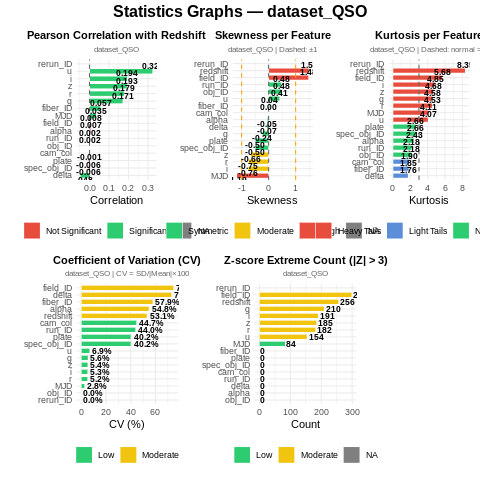

In [162]:
# @title 15.3. Statistics Graphs — dataset_QSO
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
if (!require('moments',   quietly = TRUE)) install.packages('moments',   quiet = TRUE)

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(moments)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]
DATASET_NAME <- 'dataset_QSO'

cor_df <- do.call(rbind, lapply(numeric_cols[numeric_cols != 'redshift'], function(col) {
  ct <- cor.test(dataset_QSO[[col]], dataset_QSO$redshift)
  data.frame(Feature = col, Correlation = round(ct$estimate, 4),
             Significant = ct$p.value < 0.05, stringsAsFactors = FALSE)
}))
cor_df$Feature <- factor(cor_df$Feature, levels = cor_df$Feature[order(cor_df$Correlation)])

p1 <- ggplot(cor_df, aes(x = Feature, y = Correlation, fill = Significant)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.3f', Correlation),
                vjust = ifelse(Correlation >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('TRUE' = '#2ECC71', 'FALSE' = '#E74C3C'),
                    labels = c('TRUE' = 'Significant', 'FALSE' = 'Not Significant')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Pearson Correlation with Redshift', subtitle = DATASET_NAME, x = '', y = 'Correlation')

skew_df <- data.frame(
  Feature  = numeric_cols,
  Skewness = sapply(numeric_cols, function(col) round(skewness(dataset_QSO[[col]]), 4)),
  stringsAsFactors = FALSE)
skew_df$Feature  <- factor(skew_df$Feature, levels = skew_df$Feature[order(skew_df$Skewness)])
skew_df$Category <- ifelse(abs(skew_df$Skewness) <= 0.5, 'Symmetric',
                    ifelse(abs(skew_df$Skewness) <= 1.0, 'Moderate', 'High'))
skew_df$Category <- factor(skew_df$Category, levels = c('Symmetric', 'Moderate', 'High'))

p2 <- ggplot(skew_df, aes(x = Feature, y = Skewness, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 0, 1), linetype = 'dashed',
             color = c('orange', 'gray40', 'orange')) +
  geom_text(aes(label = sprintf('%.2f', Skewness),
                vjust = ifelse(Skewness >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Symmetric' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Skewness per Feature', subtitle = paste(DATASET_NAME, '| Dashed: ±1'),
       x = '', y = 'Skewness')

kurt_df <- data.frame(
  Feature  = numeric_cols,
  Kurtosis = sapply(numeric_cols, function(col) round(kurtosis(dataset_QSO[[col]]), 4)),
  stringsAsFactors = FALSE)
kurt_df$Feature  <- factor(kurt_df$Feature, levels = kurt_df$Feature[order(kurt_df$Kurtosis)])
kurt_df$Category <- ifelse(abs(kurt_df$Kurtosis - 3) <= 1, 'Normal',
                    ifelse(kurt_df$Kurtosis > 3, 'Heavy Tails', 'Light Tails'))

p3 <- ggplot(kurt_df, aes(x = Feature, y = Kurtosis, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 3, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.2f', Kurtosis),
                vjust = ifelse(Kurtosis >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Normal' = '#2ECC71', 'Heavy Tails' = '#E74C3C', 'Light Tails' = '#5B8DD9')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Kurtosis per Feature', subtitle = paste(DATASET_NAME, '| Dashed: normal = 3'),
       x = '', y = 'Kurtosis')

cv_df <- data.frame(
  Feature = numeric_cols,
  CV      = sapply(numeric_cols, function(col) {
    vals <- dataset_QSO[[col]]
    round((sd(vals) / abs(mean(vals))) * 100, 4)}),
  stringsAsFactors = FALSE)
cv_df$Feature <- factor(cv_df$Feature, levels = cv_df$Feature[order(cv_df$CV)])

p4 <- ggplot(cv_df, aes(x = Feature, y = CV,
                         fill = ifelse(CV > 100, 'High', ifelse(CV > 50, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.1f%%', CV)), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Coefficient of Variation (CV)', subtitle = paste(DATASET_NAME, '| CV = SD/|Mean|×100'),
       x = '', y = 'CV (%)')

z_df <- data.frame(
  Feature   = numeric_cols,
  N_Extreme = sapply(numeric_cols, function(col) {
    vals <- dataset_QSO[[col]]
    sum(abs((vals - mean(vals)) / sd(vals)) > 3)}),
  stringsAsFactors = FALSE)
z_df$Feature <- factor(z_df$Feature, levels = z_df$Feature[order(z_df$N_Extreme)])

p5 <- ggplot(z_df, aes(x = Feature, y = N_Extreme,
                        fill = ifelse(N_Extreme > 1000, 'High',
                               ifelse(N_Extreme > 100, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = N_Extreme), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Z-score Extreme Count (|Z| > 3)', subtitle = DATASET_NAME, x = '', y = 'Count')

combined <- (p1 | p2 | p3) / (p4 | p5 | plot_spacer()) +
  plot_annotation(title = paste('Statistics Graphs —', DATASET_NAME),
                  theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5)))

options(repr.plot.width = 24, repr.plot.height = 18)
print(combined)

tmp_path   <- '/tmp/stats_graphs_QSO.png'
drive_path <- file.path(save_folder, 'stats_graphs_QSO.png')
ggsave(tmp_path, plot = combined, width = 24, height = 18, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat('==================================================\n')
cat(paste('Saved → ', drive_path, '\n'))
cat(paste('DPI    : ', dpi, '\n'))
cat('==================================================\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/stats_graphs_STAR.png 
DPI    :  300 


In addition: There were 17 warnings (use warnings() to see them)


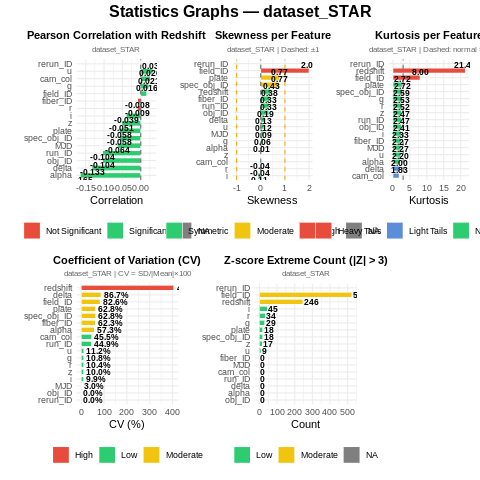

In [163]:
# @title 15.4. Statistics Graphs — dataset_STAR
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
if (!require('moments',   quietly = TRUE)) install.packages('moments',   quiet = TRUE)

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(moments)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]
DATASET_NAME <- 'dataset_STAR'

cor_df <- do.call(rbind, lapply(numeric_cols[numeric_cols != 'redshift'], function(col) {
  ct <- cor.test(dataset_STAR[[col]], dataset_STAR$redshift)
  data.frame(Feature = col, Correlation = round(ct$estimate, 4),
             Significant = ct$p.value < 0.05, stringsAsFactors = FALSE)
}))
cor_df$Feature <- factor(cor_df$Feature, levels = cor_df$Feature[order(cor_df$Correlation)])

p1 <- ggplot(cor_df, aes(x = Feature, y = Correlation, fill = Significant)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 0, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.3f', Correlation),
                vjust = ifelse(Correlation >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('TRUE' = '#2ECC71', 'FALSE' = '#E74C3C'),
                    labels = c('TRUE' = 'Significant', 'FALSE' = 'Not Significant')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Pearson Correlation with Redshift', subtitle = DATASET_NAME, x = '', y = 'Correlation')

skew_df <- data.frame(
  Feature  = numeric_cols,
  Skewness = sapply(numeric_cols, function(col) round(skewness(dataset_STAR[[col]]), 4)),
  stringsAsFactors = FALSE)
skew_df$Feature  <- factor(skew_df$Feature, levels = skew_df$Feature[order(skew_df$Skewness)])
skew_df$Category <- ifelse(abs(skew_df$Skewness) <= 0.5, 'Symmetric',
                    ifelse(abs(skew_df$Skewness) <= 1.0, 'Moderate', 'High'))
skew_df$Category <- factor(skew_df$Category, levels = c('Symmetric', 'Moderate', 'High'))

p2 <- ggplot(skew_df, aes(x = Feature, y = Skewness, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = c(-1, 0, 1), linetype = 'dashed',
             color = c('orange', 'gray40', 'orange')) +
  geom_text(aes(label = sprintf('%.2f', Skewness),
                vjust = ifelse(Skewness >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Symmetric' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Skewness per Feature', subtitle = paste(DATASET_NAME, '| Dashed: ±1'),
       x = '', y = 'Skewness')

kurt_df <- data.frame(
  Feature  = numeric_cols,
  Kurtosis = sapply(numeric_cols, function(col) round(kurtosis(dataset_STAR[[col]]), 4)),
  stringsAsFactors = FALSE)
kurt_df$Feature  <- factor(kurt_df$Feature, levels = kurt_df$Feature[order(kurt_df$Kurtosis)])
kurt_df$Category <- ifelse(abs(kurt_df$Kurtosis - 3) <= 1, 'Normal',
                    ifelse(kurt_df$Kurtosis > 3, 'Heavy Tails', 'Light Tails'))

p3 <- ggplot(kurt_df, aes(x = Feature, y = Kurtosis, fill = Category)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_hline(yintercept = 3, linetype = 'dashed', color = 'gray40') +
  geom_text(aes(label = sprintf('%.2f', Kurtosis),
                vjust = ifelse(Kurtosis >= 0, -0.4, 1.2)),
            size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Normal' = '#2ECC71', 'Heavy Tails' = '#E74C3C', 'Light Tails' = '#5B8DD9')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Kurtosis per Feature', subtitle = paste(DATASET_NAME, '| Dashed: normal = 3'),
       x = '', y = 'Kurtosis')

cv_df <- data.frame(
  Feature = numeric_cols,
  CV      = sapply(numeric_cols, function(col) {
    vals <- dataset_STAR[[col]]
    round((sd(vals) / abs(mean(vals))) * 100, 4)}),
  stringsAsFactors = FALSE)
cv_df$Feature <- factor(cv_df$Feature, levels = cv_df$Feature[order(cv_df$CV)])

p4 <- ggplot(cv_df, aes(x = Feature, y = CV,
                         fill = ifelse(CV > 100, 'High', ifelse(CV > 50, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.1f%%', CV)), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Coefficient of Variation (CV)', subtitle = paste(DATASET_NAME, '| CV = SD/|Mean|×100'),
       x = '', y = 'CV (%)')

z_df <- data.frame(
  Feature   = numeric_cols,
  N_Extreme = sapply(numeric_cols, function(col) {
    vals <- dataset_STAR[[col]]
    sum(abs((vals - mean(vals)) / sd(vals)) > 3)}),
  stringsAsFactors = FALSE)
z_df$Feature <- factor(z_df$Feature, levels = z_df$Feature[order(z_df$N_Extreme)])

p5 <- ggplot(z_df, aes(x = Feature, y = N_Extreme,
                        fill = ifelse(N_Extreme > 1000, 'High',
                               ifelse(N_Extreme > 100, 'Moderate', 'Low')))) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = N_Extreme), hjust = -0.1, size = 3, fontface = 'bold') +
  scale_fill_manual(values = c('Low' = '#2ECC71', 'Moderate' = '#F1C40F', 'High' = '#E74C3C')) +
  coord_flip() + theme_minimal() +
  theme(plot.title = element_text(face = 'bold', size = 11, hjust = 0.5),
        plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40'),
        legend.position = 'bottom', legend.title = element_blank()) +
  labs(title = 'Z-score Extreme Count (|Z| > 3)', subtitle = DATASET_NAME, x = '', y = 'Count')

combined <- (p1 | p2 | p3) / (p4 | p5 | plot_spacer()) +
  plot_annotation(title = paste('Statistics Graphs —', DATASET_NAME),
                  theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5)))

options(repr.plot.width = 24, repr.plot.height = 18)
print(combined)

tmp_path   <- '/tmp/stats_graphs_STAR.png'
drive_path <- file.path(save_folder, 'stats_graphs_STAR.png')
ggsave(tmp_path, plot = combined, width = 24, height = 18, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat('==================================================\n')
cat(paste('Saved → ', drive_path, '\n'))
cat(paste('DPI    : ', dpi, '\n'))
cat('==================================================\n')

---

# **Histograms & Relationship Plots Section**

---

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/hist_clean.png 

--- Histogram Summary (Plain Text) : dataset_clean ---

Feature : obj_ID
  Min  : 1237645942904389888
  Max  : 1237680531356386304
  Mid  : 1237663237130387968
  Mean : 1237664721913220352
--------------------------------------------------
Feature : alpha
  Min  : 0.00552782792397011
  Max  : 359.999809770956
  Mid  : 180.00266879944
  Mean : 177.634040531704
--------------------------------------------------
Feature : delta
  Min  : -18.7853280771825
  Max  : 83.00051858898
  Mid  : 32.1075952558988
  Mean : 24.1361545203415
--------------------------------------------------
Feature : u
  Min  : 10.99623
  Max  : 29.32565
  Mid  : 20.16094
  Mean : 22.0806859693776
--------------------------------------------------
Feature : g
  Min  : 10.4982
  Max  : 29.86258
  Mid  : 20.18039
  Mean : 20.6315876678134
--------------------------------------------------
Feature : r
  Min  : 10.06854
 

In addition: Warning messages:
1: Duplicated `override.aes` is ignored. 
2: Duplicated `override.aes` is ignored. 


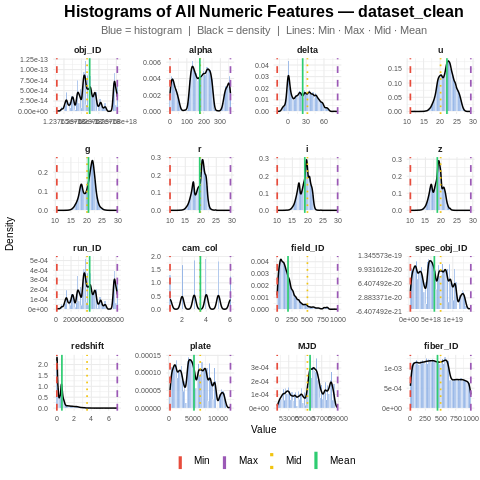

In [164]:
# @title 16.1. Histograms — dataset_clean
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_clean'
numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

dataset_long <- pivot_longer(
  dataset_clean[, numeric_cols],
  cols = everything(), names_to = 'Feature', values_to = 'Value'
)
dataset_long$Feature <- factor(dataset_long$Feature, levels = numeric_cols)

stats_df <- dataset_long %>%
  group_by(Feature) %>%
  summarise(
    Min  = min(Value,  na.rm = TRUE),
    Max  = max(Value,  na.rm = TRUE),
    Mid  = (min(Value, na.rm = TRUE) + max(Value, na.rm = TRUE)) / 2,
    Mean = mean(Value, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  pivot_longer(cols = c(Min, Max, Mid, Mean),
               names_to = 'Stat', values_to = 'Value') %>%
  mutate(Stat = factor(Stat, levels = c('Min', 'Max', 'Mid', 'Mean')))

vline_colors <- c('Min' = '#E74C3C', 'Max' = '#9B59B6',
                  'Mid' = '#F1C40F', 'Mean' = '#2ECC71')

p <- ggplot(dataset_long, aes(x = Value)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 50, fill = '#5B8DD9', color = 'white',
                 linewidth = 0.2, alpha = 0.8) +
  geom_density(color = 'black', linewidth = 0.7) +
  geom_vline(data = stats_df,
             aes(xintercept = Value, color = Stat, linetype = Stat),
             linewidth = 0.8) +
  scale_color_manual(values = vline_colors) +
  scale_linetype_manual(values = c('Min' = 'dashed', 'Max' = 'dashed',
                                   'Mid' = 'dotted', 'Mean' = 'solid')) +
  facet_wrap(~ Feature, scales = 'free', ncol = 4) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    plot.subtitle   = element_text(size = 11, hjust = 0.5, color = 'gray40'),
    strip.text      = element_text(face = 'bold', size = 9),
    axis.text       = element_text(size = 7),
    axis.title      = element_text(size = 10),
    panel.spacing   = unit(1, 'lines'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    legend.text     = element_text(size = 10)
  ) +
  guides(color    = guide_legend(override.aes = list(linewidth = 1.5)),
         linetype = guide_legend(override.aes = list(linewidth = 1.5))) +
  labs(
    title    = paste('Histograms of All Numeric Features —', DATASET_NAME),
    subtitle = 'Blue = histogram  |  Black = density  |  Lines: Min · Max · Mid · Mean',
    x = 'Value', y = 'Density'
  )

options(repr.plot.width = 24, repr.plot.height = 22)
print(p)

tmp_path   <- '/tmp/hist_clean.png'
drive_path <- file.path(save_folder, 'hist_clean.png')
ggsave(tmp_path, plot = p, width = 24, height = 22, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Histogram Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

for (col in numeric_cols) {
  vals <- dataset_clean[[col]]
  mn   <- min(vals,  na.rm = TRUE)
  mx   <- max(vals,  na.rm = TRUE)
  mid  <- (mn + mx) / 2
  mu   <- mean(vals, na.rm = TRUE)
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min  : %s\n', mn))
  cat(sprintf('  Max  : %s\n', mx))
  cat(sprintf('  Mid  : %s\n', mid))
  cat(sprintf('  Mean : %s\n', mu))
  cat('--------------------------------------------------\n')
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/relationship_clean.png 

--- Relationship Summary (Plain Text) : dataset_clean ---

--- 1. Correlation Matrix ---
                        obj_ID     alpha     delta         u         g         r         i         z    run_ID   cam_col  field_ID spec_obj_  redshift     plate       MJD  fiber_ID 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 
obj_ID                   1.000    -0.0

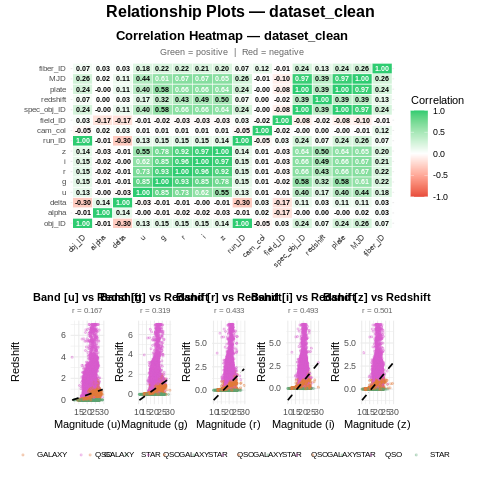

In [165]:
# @title 16.2. Relationship Plots — dataset_clean
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
library(ggplot2)
library(tidyr)
library(dplyr)
library(patchwork)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_clean'
bands        <- c('u', 'g', 'r', 'i', 'z')
numeric_cols <- names(dataset_clean)[sapply(dataset_clean, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

# =====================================================
# Plot 1: Correlation Heatmap
# =====================================================
cor_matrix <- cor(dataset_clean[, numeric_cols], use = 'complete.obs')
cor_df      <- as.data.frame(as.table(cor_matrix))
names(cor_df) <- c('Feature1', 'Feature2', 'Correlation')

p1 <- ggplot(cor_df, aes(x = Feature1, y = Feature2, fill = Correlation)) +
  geom_tile(color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.2f', Correlation)),
            size = 2.5, fontface = 'bold',
            color = ifelse(abs(cor_df$Correlation) > 0.6, 'white', 'black')) +
  scale_fill_gradient2(low = '#E74C3C', mid = 'white', high = '#2ECC71',
                       midpoint = 0, limits = c(-1, 1), name = 'Correlation') +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8),
    axis.text.y     = element_text(size = 8),
    legend.position = 'right'
  ) +
  labs(title    = paste('Correlation Heatmap —', DATASET_NAME),
       subtitle = 'Green = positive  |  Red = negative',
       x = '', y = '')

# =====================================================
# Plot 2: Scatter Plots — Each Band vs Redshift
# =====================================================
scatter_list <- lapply(bands, function(b) {
  ggplot(dataset_clean, aes(x = .data[[b]], y = redshift, color = class)) +
    geom_point(alpha = 0.3, size = 0.8) +
    geom_smooth(method = 'lm', se = TRUE, color = 'black',
                linewidth = 0.8, linetype = 'dashed') +
    scale_color_manual(values = c('GALAXY' = '#E07B39',
                                  'QSO'    = '#d95bcf',
                                  'STAR'   = '#57A773')) +
    theme_minimal() +
    theme(
      plot.title      = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle   = element_text(size = 8, hjust = 0.5, color = 'gray40'),
      legend.position = 'bottom',
      legend.title    = element_blank(),
      legend.text     = element_text(size = 8)
    ) +
    labs(
      title    = paste0('Band [', b, '] vs Redshift'),
      subtitle = paste0('r = ', round(cor(dataset_clean[[b]],
                        dataset_clean$redshift, use = 'complete.obs'), 3)),
      x = paste0('Magnitude (', b, ')'),
      y = 'Redshift'
    )
})

scatter_row <- scatter_list[[1]] | scatter_list[[2]] | scatter_list[[3]] |
               scatter_list[[4]] | scatter_list[[5]]

combined <- p1 / scatter_row +
  plot_layout(heights = c(2, 1)) +
  plot_annotation(
    title = paste('Relationship Plots —', DATASET_NAME),
    theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5))
  )

options(repr.plot.width = 26, repr.plot.height = 24)
print(combined)

tmp_path   <- '/tmp/relationship_clean.png'
drive_path <- file.path(save_folder, 'relationship_clean.png')
ggsave(tmp_path, plot = combined, width = 26, height = 24, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Relationship Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

# Correlation Matrix
cat('--- 1. Correlation Matrix ---\n')
header <- sprintf('%-20s', '')
for (col in numeric_cols) header <- paste0(header, sprintf('%10s', substr(col, 1, 9)))
cat(header, '\n')
cat(paste(rep('-', 20 + 10 * length(numeric_cols)), collapse = ''), '\n')
for (r in numeric_cols) {
  row_str <- sprintf('%-20s', r)
  for (cc in numeric_cols) {
    val <- cor_matrix[r, cc]
    row_str <- paste0(row_str, sprintf('%10.3f', val))
  }
  cat(row_str, '\n')
}

# Band vs Redshift Correlations
cat('\n--- 2. Band vs Redshift Correlation ---\n')
cat(sprintf('%-10s %12s %12s\n', 'Band', 'Correlation', 'p-value'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (b in bands) {
  ct  <- cor.test(dataset_clean[[b]], dataset_clean$redshift)
  sig <- ifelse(ct$p.value < 0.05, '*', ' ')
  cat(sprintf('%-10s %12.4f %12.4e %s\n', b, ct$estimate, ct$p.value, sig))
}
cat('* = statistically significant (p < 0.05)\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/hist_GALAXY.png 

--- Histogram Summary (Plain Text) : dataset_GALAXY ---

Feature : obj_ID
  Min  : 1237645942905438464
  Max  : 1237680531356386304
  Mid  : 1237663237130912256
  Mean : 1237664861131583488
--------------------------------------------------
Feature : alpha
  Min  : 0.00552782792397011
  Max  : 359.994124543599
  Mid  : 179.999826185761
  Mean : 177.95579995257
--------------------------------------------------
Feature : delta
  Min  : -12.3647005089841
  Max  : 77.615587878828
  Mid  : 32.6254436849219
  Mean : 23.5137523356712
--------------------------------------------------
Feature : u
  Min  : 13.89799
  Max  : 29.32565
  Mid  : 21.61182
  Mean : 22.5875108320576
--------------------------------------------------
Feature : g
  Min  : 12.67902
  Max  : 29.86258
  Mid  : 21.2708
  Mean : 20.9059616583954
--------------------------------------------------
Feature : r
  Min  : 11.7466

In addition: Warning messages:
1: Duplicated `override.aes` is ignored. 
2: Duplicated `override.aes` is ignored. 


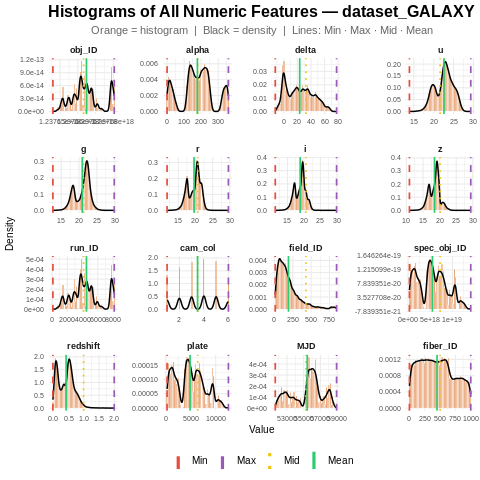

In [166]:
# @title 16.3. Histograms — dataset_GALAXY
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_GALAXY'
numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

dataset_long <- pivot_longer(
  dataset_GALAXY[, numeric_cols],
  cols = everything(), names_to = 'Feature', values_to = 'Value'
)
dataset_long$Feature <- factor(dataset_long$Feature, levels = numeric_cols)

stats_df <- dataset_long %>%
  group_by(Feature) %>%
  summarise(
    Min  = min(Value,  na.rm = TRUE),
    Max  = max(Value,  na.rm = TRUE),
    Mid  = (min(Value, na.rm = TRUE) + max(Value, na.rm = TRUE)) / 2,
    Mean = mean(Value, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  pivot_longer(cols = c(Min, Max, Mid, Mean),
               names_to = 'Stat', values_to = 'Value') %>%
  mutate(Stat = factor(Stat, levels = c('Min', 'Max', 'Mid', 'Mean')))

vline_colors <- c('Min' = '#E74C3C', 'Max' = '#9B59B6',
                  'Mid' = '#F1C40F', 'Mean' = '#2ECC71')

p <- ggplot(dataset_long, aes(x = Value)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 50, fill = '#E07B39', color = 'white',
                 linewidth = 0.2, alpha = 0.8) +
  geom_density(color = 'black', linewidth = 0.7) +
  geom_vline(data = stats_df,
             aes(xintercept = Value, color = Stat, linetype = Stat),
             linewidth = 0.8) +
  scale_color_manual(values = vline_colors) +
  scale_linetype_manual(values = c('Min' = 'dashed', 'Max' = 'dashed',
                                   'Mid' = 'dotted', 'Mean' = 'solid')) +
  facet_wrap(~ Feature, scales = 'free', ncol = 4) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    plot.subtitle   = element_text(size = 11, hjust = 0.5, color = 'gray40'),
    strip.text      = element_text(face = 'bold', size = 9),
    axis.text       = element_text(size = 7),
    axis.title      = element_text(size = 10),
    panel.spacing   = unit(1, 'lines'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    legend.text     = element_text(size = 10)
  ) +
  guides(color    = guide_legend(override.aes = list(linewidth = 1.5)),
         linetype = guide_legend(override.aes = list(linewidth = 1.5))) +
  labs(
    title    = paste('Histograms of All Numeric Features —', DATASET_NAME),
    subtitle = 'Orange = histogram  |  Black = density  |  Lines: Min · Max · Mid · Mean',
    x = 'Value', y = 'Density'
  )

options(repr.plot.width = 24, repr.plot.height = 22)
print(p)

tmp_path   <- '/tmp/hist_GALAXY.png'
drive_path <- file.path(save_folder, 'hist_GALAXY.png')
ggsave(tmp_path, plot = p, width = 24, height = 22, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Histogram Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

for (col in numeric_cols) {
  vals <- dataset_GALAXY[[col]]
  mn   <- min(vals,  na.rm = TRUE)
  mx   <- max(vals,  na.rm = TRUE)
  mid  <- (mn + mx) / 2
  mu   <- mean(vals, na.rm = TRUE)
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min  : %s\n', mn))
  cat(sprintf('  Max  : %s\n', mx))
  cat(sprintf('  Mid  : %s\n', mid))
  cat(sprintf('  Mean : %s\n', mu))
  cat('--------------------------------------------------\n')
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/relationship_GALAXY.png 

--- Relationship Summary (Plain Text) : dataset_GALAXY ---

--- 1. Correlation Matrix ---
                        obj_ID     alpha     delta         u         g         r         i         z    run_ID   cam_col  field_ID spec_obj_  redshift     plate       MJD  fiber_ID 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 
obj_ID                   1.000    -0

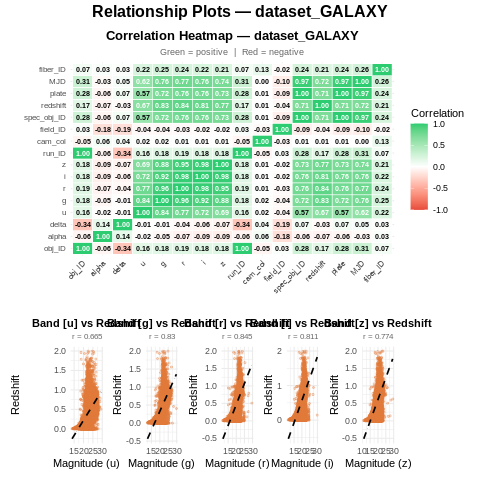

In [167]:
# @title 16.4. Relationship Plots — dataset_GALAXY
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
library(ggplot2)
library(tidyr)
library(dplyr)
library(patchwork)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_GALAXY'
bands        <- c('u', 'g', 'r', 'i', 'z')
numeric_cols <- names(dataset_GALAXY)[sapply(dataset_GALAXY, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

cor_matrix <- cor(dataset_GALAXY[, numeric_cols], use = 'complete.obs')
cor_df      <- as.data.frame(as.table(cor_matrix))
names(cor_df) <- c('Feature1', 'Feature2', 'Correlation')

p1 <- ggplot(cor_df, aes(x = Feature1, y = Feature2, fill = Correlation)) +
  geom_tile(color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.2f', Correlation)),
            size = 2.5, fontface = 'bold',
            color = ifelse(abs(cor_df$Correlation) > 0.6, 'white', 'black')) +
  scale_fill_gradient2(low = '#E74C3C', mid = 'white', high = '#2ECC71',
                       midpoint = 0, limits = c(-1, 1), name = 'Correlation') +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8),
    axis.text.y     = element_text(size = 8),
    legend.position = 'right'
  ) +
  labs(title    = paste('Correlation Heatmap —', DATASET_NAME),
       subtitle = 'Green = positive  |  Red = negative',
       x = '', y = '')

scatter_list <- lapply(bands, function(b) {
  ggplot(dataset_GALAXY, aes(x = .data[[b]], y = redshift)) +
    geom_point(alpha = 0.3, size = 0.8, color = '#E07B39') +
    geom_smooth(method = 'lm', se = TRUE, color = 'black',
                linewidth = 0.8, linetype = 'dashed') +
    theme_minimal() +
    theme(
      plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40')
    ) +
    labs(
      title    = paste0('Band [', b, '] vs Redshift'),
      subtitle = paste0('r = ', round(cor(dataset_GALAXY[[b]],
                        dataset_GALAXY$redshift, use = 'complete.obs'), 3)),
      x = paste0('Magnitude (', b, ')'),
      y = 'Redshift'
    )
})

scatter_row <- scatter_list[[1]] | scatter_list[[2]] | scatter_list[[3]] |
               scatter_list[[4]] | scatter_list[[5]]

combined <- p1 / scatter_row +
  plot_layout(heights = c(2, 1)) +
  plot_annotation(
    title = paste('Relationship Plots —', DATASET_NAME),
    theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5))
  )

options(repr.plot.width = 26, repr.plot.height = 24)
print(combined)

tmp_path   <- '/tmp/relationship_GALAXY.png'
drive_path <- file.path(save_folder, 'relationship_GALAXY.png')
ggsave(tmp_path, plot = combined, width = 26, height = 24, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Relationship Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

cat('--- 1. Correlation Matrix ---\n')
header <- sprintf('%-20s', '')
for (col in numeric_cols) header <- paste0(header, sprintf('%10s', substr(col, 1, 9)))
cat(header, '\n')
cat(paste(rep('-', 20 + 10 * length(numeric_cols)), collapse = ''), '\n')
for (r in numeric_cols) {
  row_str <- sprintf('%-20s', r)
  for (cc in numeric_cols) {
    val <- cor_matrix[r, cc]
    row_str <- paste0(row_str, sprintf('%10.3f', val))
  }
  cat(row_str, '\n')
}

cat('\n--- 2. Band vs Redshift Correlation ---\n')
cat(sprintf('%-10s %12s %12s\n', 'Band', 'Correlation', 'p-value'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (b in bands) {
  ct  <- cor.test(dataset_GALAXY[[b]], dataset_GALAXY$redshift)
  sig <- ifelse(ct$p.value < 0.05, '*', ' ')
  cat(sprintf('%-10s %12.4f %12.4e %s\n', b, ct$estimate, ct$p.value, sig))
}
cat('* = statistically significant (p < 0.05)\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/hist_QSO.png 

--- Histogram Summary (Plain Text) : dataset_QSO ---

Feature : obj_ID
  Min  : 1237645942905700608
  Max  : 1237680529745839360
  Mid  : 1237663236325769984
  Mean : 1237665157046610688
--------------------------------------------------
Feature : alpha
  Min  : 0.0109586937406903
  Max  : 359.99961524169
  Mid  : 180.005286967715
  Mean : 180.486744459578
--------------------------------------------------
Feature : delta
  Min  : -15.9809039198368
  Max  : 82.2886569832097
  Mid  : 33.1538765316864
  Mean : 26.8105323858809
--------------------------------------------------
Feature : u
  Min  : 10.99623
  Max  : 29.19901
  Mid  : 20.09762
  Mean : 21.547246623589
--------------------------------------------------
Feature : g
  Min  : 13.66217
  Max  : 27.89482
  Mid  : 20.778495
  Mean : 20.9267340078067
--------------------------------------------------
Feature : r
  Min  : 12.35763
  M

In addition: Warning messages:
1: Duplicated `override.aes` is ignored. 
2: Duplicated `override.aes` is ignored. 


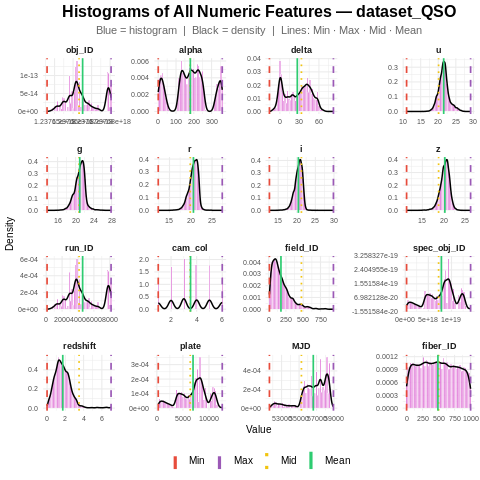

In [168]:
# @title 16.5. Histograms — dataset_QSO
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_QSO'
numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

dataset_long <- pivot_longer(
  dataset_QSO[, numeric_cols],
  cols = everything(), names_to = 'Feature', values_to = 'Value'
)
dataset_long$Feature <- factor(dataset_long$Feature, levels = numeric_cols)

stats_df <- dataset_long %>%
  group_by(Feature) %>%
  summarise(
    Min  = min(Value,  na.rm = TRUE),
    Max  = max(Value,  na.rm = TRUE),
    Mid  = (min(Value, na.rm = TRUE) + max(Value, na.rm = TRUE)) / 2,
    Mean = mean(Value, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  pivot_longer(cols = c(Min, Max, Mid, Mean),
               names_to = 'Stat', values_to = 'Value') %>%
  mutate(Stat = factor(Stat, levels = c('Min', 'Max', 'Mid', 'Mean')))

vline_colors <- c('Min' = '#E74C3C', 'Max' = '#9B59B6',
                  'Mid' = '#F1C40F', 'Mean' = '#2ECC71')

p <- ggplot(dataset_long, aes(x = Value)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 50, fill = '#d95bcf', color = 'white',
                 linewidth = 0.2, alpha = 0.8) +
  geom_density(color = 'black', linewidth = 0.7) +
  geom_vline(data = stats_df,
             aes(xintercept = Value, color = Stat, linetype = Stat),
             linewidth = 0.8) +
  scale_color_manual(values = vline_colors) +
  scale_linetype_manual(values = c('Min' = 'dashed', 'Max' = 'dashed',
                                   'Mid' = 'dotted', 'Mean' = 'solid')) +
  facet_wrap(~ Feature, scales = 'free', ncol = 4) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    plot.subtitle   = element_text(size = 11, hjust = 0.5, color = 'gray40'),
    strip.text      = element_text(face = 'bold', size = 9),
    axis.text       = element_text(size = 7),
    axis.title      = element_text(size = 10),
    panel.spacing   = unit(1, 'lines'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    legend.text     = element_text(size = 10)
  ) +
  guides(color    = guide_legend(override.aes = list(linewidth = 1.5)),
         linetype = guide_legend(override.aes = list(linewidth = 1.5))) +
  labs(
    title    = paste('Histograms of All Numeric Features —', DATASET_NAME),
    subtitle = 'Blue = histogram  |  Black = density  |  Lines: Min · Max · Mid · Mean',
    x = 'Value', y = 'Density'
  )

options(repr.plot.width = 24, repr.plot.height = 22)
print(p)

tmp_path   <- '/tmp/hist_QSO.png'
drive_path <- file.path(save_folder, 'hist_QSO.png')
ggsave(tmp_path, plot = p, width = 24, height = 22, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Histogram Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

for (col in numeric_cols) {
  vals <- dataset_QSO[[col]]
  mn   <- min(vals,  na.rm = TRUE)
  mx   <- max(vals,  na.rm = TRUE)
  mid  <- (mn + mx) / 2
  mu   <- mean(vals, na.rm = TRUE)
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min  : %s\n', mn))
  cat(sprintf('  Max  : %s\n', mx))
  cat(sprintf('  Mid  : %s\n', mid))
  cat(sprintf('  Mean : %s\n', mu))
  cat('--------------------------------------------------\n')
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/relationship_QSO.png 

--- Relationship Summary (Plain Text) : dataset_QSO ---

--- 1. Correlation Matrix ---
                        obj_ID     alpha     delta         u         g         r         i         z    run_ID   cam_col  field_ID spec_obj_  redshift     plate       MJD  fiber_ID 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 
obj_ID                   1.000     0.008  

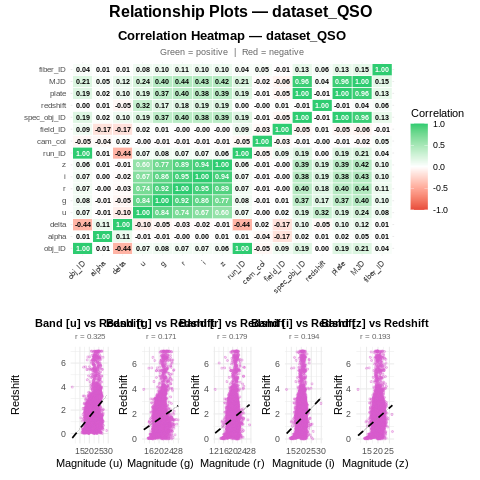

In [169]:
# @title 16.6. Relationship Plots — dataset_QSO
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
library(ggplot2)
library(tidyr)
library(dplyr)
library(patchwork)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_QSO'
bands        <- c('u', 'g', 'r', 'i', 'z')
numeric_cols <- names(dataset_QSO)[sapply(dataset_QSO, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

cor_matrix <- cor(dataset_QSO[, numeric_cols], use = 'complete.obs')
cor_df      <- as.data.frame(as.table(cor_matrix))
names(cor_df) <- c('Feature1', 'Feature2', 'Correlation')

p1 <- ggplot(cor_df, aes(x = Feature1, y = Feature2, fill = Correlation)) +
  geom_tile(color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.2f', Correlation)),
            size = 2.5, fontface = 'bold',
            color = ifelse(abs(cor_df$Correlation) > 0.6, 'white', 'black')) +
  scale_fill_gradient2(low = '#E74C3C', mid = 'white', high = '#2ECC71',
                       midpoint = 0, limits = c(-1, 1), name = 'Correlation') +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8),
    axis.text.y     = element_text(size = 8),
    legend.position = 'right'
  ) +
  labs(title    = paste('Correlation Heatmap —', DATASET_NAME),
       subtitle = 'Green = positive  |  Red = negative',
       x = '', y = '')

scatter_list <- lapply(bands, function(b) {
  ggplot(dataset_QSO, aes(x = .data[[b]], y = redshift)) +
    geom_point(alpha = 0.3, size = 0.8, color = '#d95bcf') +
    geom_smooth(method = 'lm', se = TRUE, color = 'black',
                linewidth = 0.8, linetype = 'dashed') +
    theme_minimal() +
    theme(
      plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40')
    ) +
    labs(
      title    = paste0('Band [', b, '] vs Redshift'),
      subtitle = paste0('r = ', round(cor(dataset_QSO[[b]],
                        dataset_QSO$redshift, use = 'complete.obs'), 3)),
      x = paste0('Magnitude (', b, ')'),
      y = 'Redshift'
    )
})

scatter_row <- scatter_list[[1]] | scatter_list[[2]] | scatter_list[[3]] |
               scatter_list[[4]] | scatter_list[[5]]

combined <- p1 / scatter_row +
  plot_layout(heights = c(2, 1)) +
  plot_annotation(
    title = paste('Relationship Plots —', DATASET_NAME),
    theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5))
  )

options(repr.plot.width = 26, repr.plot.height = 24)
print(combined)

tmp_path   <- '/tmp/relationship_QSO.png'
drive_path <- file.path(save_folder, 'relationship_QSO.png')
ggsave(tmp_path, plot = combined, width = 26, height = 24, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Relationship Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

cat('--- 1. Correlation Matrix ---\n')
header <- sprintf('%-20s', '')
for (col in numeric_cols) header <- paste0(header, sprintf('%10s', substr(col, 1, 9)))
cat(header, '\n')
cat(paste(rep('-', 20 + 10 * length(numeric_cols)), collapse = ''), '\n')
for (r in numeric_cols) {
  row_str <- sprintf('%-20s', r)
  for (cc in numeric_cols) {
    val <- cor_matrix[r, cc]
    row_str <- paste0(row_str, sprintf('%10.3f', val))
  }
  cat(row_str, '\n')
}

cat('\n--- 2. Band vs Redshift Correlation ---\n')
cat(sprintf('%-10s %12s %12s\n', 'Band', 'Correlation', 'p-value'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (b in bands) {
  ct  <- cor.test(dataset_QSO[[b]], dataset_QSO$redshift)
  sig <- ifelse(ct$p.value < 0.05, '*', ' ')
  cat(sprintf('%-10s %12.4f %12.4e %s\n', b, ct$estimate, ct$p.value, sig))
}
cat('* = statistically significant (p < 0.05)\n')

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/hist_STAR.png 

--- Histogram Summary (Plain Text) : dataset_STAR ---

Feature : obj_ID
  Min  : 1237645942904389888
  Max  : 1237680531355009536
  Mid  : 1237663237129699840
  Mean : 1237663956556545536
--------------------------------------------------
Feature : alpha
  Min  : 0.0298381739607976
  Max  : 359.999809770956
  Mid  : 180.014823972458
  Mean : 174.243372831311
--------------------------------------------------
Feature : delta
  Min  : -18.7853280771825
  Max  : 83.00051858898
  Mid  : 32.1075952558988
  Mean : 23.5014732868858
--------------------------------------------------
Feature : u
  Min  : 12.10168
  Max  : 29.23438
  Mid  : 20.66803
  Mean : 21.1537142128665
--------------------------------------------------
Feature : g
  Min  : 10.4982
  Max  : 28.9032
  Mid  : 19.7007
  Mean : 19.6170446899171
--------------------------------------------------
Feature : r
  Min  : 10.06854
  Max

In addition: Warning messages:
1: Duplicated `override.aes` is ignored. 
2: Duplicated `override.aes` is ignored. 


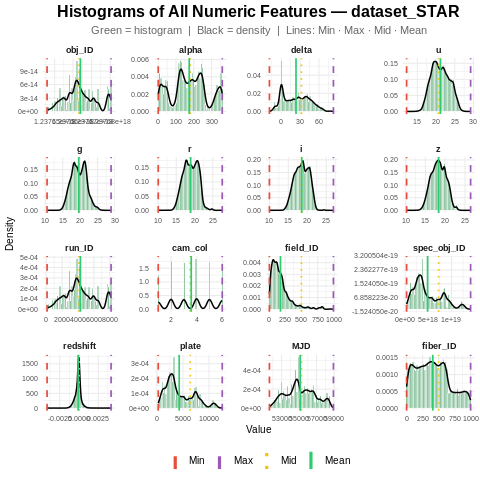

In [170]:
# @title 16.7. Histograms — dataset_STAR
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

library(ggplot2)
library(tidyr)
library(dplyr)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_STAR'
numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

dataset_long <- pivot_longer(
  dataset_STAR[, numeric_cols],
  cols = everything(), names_to = 'Feature', values_to = 'Value'
)
dataset_long$Feature <- factor(dataset_long$Feature, levels = numeric_cols)

stats_df <- dataset_long %>%
  group_by(Feature) %>%
  summarise(
    Min  = min(Value,  na.rm = TRUE),
    Max  = max(Value,  na.rm = TRUE),
    Mid  = (min(Value, na.rm = TRUE) + max(Value, na.rm = TRUE)) / 2,
    Mean = mean(Value, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  pivot_longer(cols = c(Min, Max, Mid, Mean),
               names_to = 'Stat', values_to = 'Value') %>%
  mutate(Stat = factor(Stat, levels = c('Min', 'Max', 'Mid', 'Mean')))

vline_colors <- c('Min' = '#E74C3C', 'Max' = '#9B59B6',
                  'Mid' = '#F1C40F', 'Mean' = '#2ECC71')

p <- ggplot(dataset_long, aes(x = Value)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 50, fill = '#57A773', color = 'white',
                 linewidth = 0.2, alpha = 0.8) +
  geom_density(color = 'black', linewidth = 0.7) +
  geom_vline(data = stats_df,
             aes(xintercept = Value, color = Stat, linetype = Stat),
             linewidth = 0.8) +
  scale_color_manual(values = vline_colors) +
  scale_linetype_manual(values = c('Min' = 'dashed', 'Max' = 'dashed',
                                   'Mid' = 'dotted', 'Mean' = 'solid')) +
  facet_wrap(~ Feature, scales = 'free', ncol = 4) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 16, hjust = 0.5),
    plot.subtitle   = element_text(size = 11, hjust = 0.5, color = 'gray40'),
    strip.text      = element_text(face = 'bold', size = 9),
    axis.text       = element_text(size = 7),
    axis.title      = element_text(size = 10),
    panel.spacing   = unit(1, 'lines'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    legend.text     = element_text(size = 10)
  ) +
  guides(color    = guide_legend(override.aes = list(linewidth = 1.5)),
         linetype = guide_legend(override.aes = list(linewidth = 1.5))) +
  labs(
    title    = paste('Histograms of All Numeric Features —', DATASET_NAME),
    subtitle = 'Green = histogram  |  Black = density  |  Lines: Min · Max · Mid · Mean',
    x = 'Value', y = 'Density'
  )

options(repr.plot.width = 24, repr.plot.height = 22)
print(p)

tmp_path   <- '/tmp/hist_STAR.png'
drive_path <- file.path(save_folder, 'hist_STAR.png')
ggsave(tmp_path, plot = p, width = 24, height = 22, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Histogram Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

for (col in numeric_cols) {
  vals <- dataset_STAR[[col]]
  mn   <- min(vals,  na.rm = TRUE)
  mx   <- max(vals,  na.rm = TRUE)
  mid  <- (mn + mx) / 2
  mu   <- mean(vals, na.rm = TRUE)
  cat(sprintf('Feature : %s\n', col))
  cat(sprintf('  Min  : %s\n', mn))
  cat(sprintf('  Max  : %s\n', mx))
  cat(sprintf('  Mid  : %s\n', mid))
  cat(sprintf('  Mean : %s\n', mu))
  cat('--------------------------------------------------\n')
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning/relationship_STAR.png 

--- Relationship Summary (Plain Text) : dataset_STAR ---

--- 1. Correlation Matrix ---
                        obj_ID     alpha     delta         u         g         r         i         z    run_ID   cam_col  field_ID spec_obj_  redshift     plate       MJD  fiber_ID 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 
obj_ID                   1.000     0.071

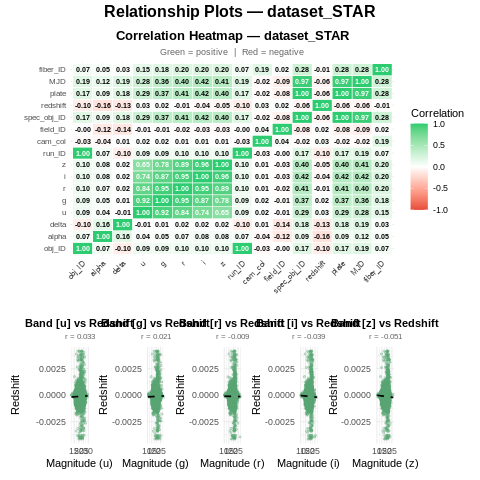

In [171]:
# @title 16.8. Relationship Plots — dataset_STAR
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Analyze_the_data_after_cleaning' # @param {type:"string"}
dpi         = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
library(ggplot2)
library(tidyr)
library(dplyr)
library(patchwork)

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

DATASET_NAME <- 'dataset_STAR'
bands        <- c('u', 'g', 'r', 'i', 'z')
numeric_cols <- names(dataset_STAR)[sapply(dataset_STAR, is.numeric)]
numeric_cols <- numeric_cols[numeric_cols != 'rerun_ID']

cor_matrix <- cor(dataset_STAR[, numeric_cols], use = 'complete.obs')
cor_df      <- as.data.frame(as.table(cor_matrix))
names(cor_df) <- c('Feature1', 'Feature2', 'Correlation')

p1 <- ggplot(cor_df, aes(x = Feature1, y = Feature2, fill = Correlation)) +
  geom_tile(color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.2f', Correlation)),
            size = 2.5, fontface = 'bold',
            color = ifelse(abs(cor_df$Correlation) > 0.6, 'white', 'black')) +
  scale_fill_gradient2(low = '#E74C3C', mid = 'white', high = '#2ECC71',
                       midpoint = 0, limits = c(-1, 1), name = 'Correlation') +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 8),
    axis.text.y     = element_text(size = 8),
    legend.position = 'right'
  ) +
  labs(title    = paste('Correlation Heatmap —', DATASET_NAME),
       subtitle = 'Green = positive  |  Red = negative',
       x = '', y = '')

scatter_list <- lapply(bands, function(b) {
  ggplot(dataset_STAR, aes(x = .data[[b]], y = redshift)) +
    geom_point(alpha = 0.3, size = 0.8, color = '#57A773') +
    geom_smooth(method = 'lm', se = TRUE, color = 'black',
                linewidth = 0.8, linetype = 'dashed') +
    theme_minimal() +
    theme(
      plot.title    = element_text(face = 'bold', size = 11, hjust = 0.5),
      plot.subtitle = element_text(size = 8, hjust = 0.5, color = 'gray40')
    ) +
    labs(
      title    = paste0('Band [', b, '] vs Redshift'),
      subtitle = paste0('r = ', round(cor(dataset_STAR[[b]],
                        dataset_STAR$redshift, use = 'complete.obs'), 3)),
      x = paste0('Magnitude (', b, ')'),
      y = 'Redshift'
    )
})

scatter_row <- scatter_list[[1]] | scatter_list[[2]] | scatter_list[[3]] |
               scatter_list[[4]] | scatter_list[[5]]

combined <- p1 / scatter_row +
  plot_layout(heights = c(2, 1)) +
  plot_annotation(
    title = paste('Relationship Plots —', DATASET_NAME),
    theme = theme(plot.title = element_text(face = 'bold', size = 16, hjust = 0.5))
  )

options(repr.plot.width = 26, repr.plot.height = 24)
print(combined)

tmp_path   <- '/tmp/relationship_STAR.png'
drive_path <- file.path(save_folder, 'relationship_STAR.png')
ggsave(tmp_path, plot = combined, width = 26, height = 24, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat(paste('Saved → ', drive_path, '\n\n'))

# --- Section: Plain Text ---
cat('==================================================\n')
cat(paste('--- Relationship Summary (Plain Text) :', DATASET_NAME, '---\n'))
cat('==================================================\n\n')

cat('--- 1. Correlation Matrix ---\n')
header <- sprintf('%-20s', '')
for (col in numeric_cols) header <- paste0(header, sprintf('%10s', substr(col, 1, 9)))
cat(header, '\n')
cat(paste(rep('-', 20 + 10 * length(numeric_cols)), collapse = ''), '\n')
for (r in numeric_cols) {
  row_str <- sprintf('%-20s', r)
  for (cc in numeric_cols) {
    val <- cor_matrix[r, cc]
    row_str <- paste0(row_str, sprintf('%10.3f', val))
  }
  cat(row_str, '\n')
}

cat('\n--- 2. Band vs Redshift Correlation ---\n')
cat(sprintf('%-10s %12s %12s\n', 'Band', 'Correlation', 'p-value'))
cat(paste(rep('-', 36), collapse = ''), '\n')
for (b in bands) {
  ct  <- cor.test(dataset_STAR[[b]], dataset_STAR$redshift)
  sig <- ifelse(ct$p.value < 0.05, '*', ' ')
  cat(sprintf('%-10s %12.4f %12.4e %s\n', b, ct$estimate, ct$p.value, sig))
}
cat('* = statistically significant (p < 0.05)\n')

---

# **Data Splitting Section**

---

In [172]:
# @title 17. Train/Test Split — All Datasets (80/20)
%%R
save_base   = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata' # @param {type:"string"}
random_seed = 64 # @param {type:"slider", min:1, max:100, step:1}

# --- Folder paths ---
folder_all    <- file.path(save_base, 'All')
folder_galaxy <- file.path(save_base, 'Galaxy')
folder_qso    <- file.path(save_base, 'QSO')
folder_star   <- file.path(save_base, 'Star')

dir.create(folder_all,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_galaxy, showWarnings = FALSE, recursive = TRUE)
dir.create(folder_qso,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_star,   showWarnings = FALSE, recursive = TRUE)

set.seed(random_seed)

# =====================================================
# Helper function: split, report, and save
# =====================================================
split_and_save <- function(data, dataset_name, folder) {

  n          <- nrow(data)
  train_idx  <- sample(seq_len(n), size = floor(0.8 * n))
  train_data <- data[train_idx,  ]
  test_data  <- data[-train_idx, ]

  train_path <- file.path(folder, paste0(dataset_name, '_train.csv'))
  test_path  <- file.path(folder, paste0(dataset_name, '_test.csv'))

  write.csv(train_data, train_path, row.names = FALSE)
  write.csv(test_data,  test_path,  row.names = FALSE)

  cat('==================================================\n')
  cat(sprintf('Dataset     : %s\n',   dataset_name))
  cat(sprintf('Total rows  : %d\n',   n))
  cat(sprintf('Train rows  : %d (%.1f%%)\n', nrow(train_data),
              nrow(train_data) / n * 100))
  cat(sprintf('Test  rows  : %d (%.1f%%)\n', nrow(test_data),
              nrow(test_data)  / n * 100))
  cat(sprintf('Columns     : %d\n',   ncol(data)))
  cat(sprintf('Random seed : %d\n',   random_seed))
  cat(sprintf('Train saved : %s\n',   train_path))
  cat(sprintf('Test  saved : %s\n',   test_path))
  cat('==================================================\n\n')
}

# =====================================================
# Split all 4 datasets
# =====================================================
cat('==================================================\n')
cat('--- Train/Test Split Report (80/20) ---\n')
cat('==================================================\n\n')

split_and_save(dataset_clean,  'dataset_clean',  folder_all)
split_and_save(dataset_GALAXY, 'dataset_GALAXY', folder_galaxy)
split_and_save(dataset_QSO,    'dataset_QSO',    folder_qso)
split_and_save(dataset_STAR,   'dataset_STAR',   folder_star)

cat('==================================================\n')
cat('--- All splits completed successfully ---\n')
cat('==================================================\n')
cat(sprintf('Base folder : %s\n', save_base))
cat(sprintf('  All/      : %s\n', folder_all))
cat(sprintf('  Galaxy/   : %s\n', folder_galaxy))
cat(sprintf('  QSO/      : %s\n', folder_qso))
cat(sprintf('  Star/     : %s\n', folder_star))
cat('==================================================\n')

--- Train/Test Split Report (80/20) ---

Dataset     : dataset_clean
Total rows  : 99992
Train rows  : 79993 (80.0%)
Test  rows  : 19999 (20.0%)
Columns     : 18
Random seed : 64
Train saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_train.csv
Test  saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_test.csv

Dataset     : dataset_GALAXY
Total rows  : 59443
Train rows  : 47554 (80.0%)
Test  rows  : 11889 (20.0%)
Columns     : 18
Random seed : 64
Train saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_train.csv
Test  saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_test.csv

Dataset     : dataset_QSO
Total rows  : 18958
Train rows  : 15166 (80.0%)
Test  rows  : 3792 (20.0%)
Columns     : 18
Random seed : 64
Train saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset_QSO_train.csv
Test  saved : /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset

In [173]:
# @title 18. Set Split Dataset Paths
# @markdown ---
# All
path_clean_train  = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_train.csv'  # @param {type:"string"}
path_clean_test   = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_test.csv'   # @param {type:"string"}
# Galaxy
path_galaxy_train = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_train.csv' # @param {type:"string"}
path_galaxy_test  = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_test.csv'  # @param {type:"string"}
# QSO
path_qso_train    = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset_QSO_train.csv'    # @param {type:"string"}
path_qso_test     = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset_QSO_test.csv'     # @param {type:"string"}
# Star
path_star_train   = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Star/dataset_STAR_train.csv'  # @param {type:"string"}
path_star_test    = '/content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Star/dataset_STAR_test.csv'   # @param {type:"string"}
# @markdown ---

import os

paths = {
    'dataset_clean_train'  : path_clean_train,
    'dataset_clean_test'   : path_clean_test,
    'dataset_GALAXY_train' : path_galaxy_train,
    'dataset_GALAXY_test'  : path_galaxy_test,
    'dataset_QSO_train'    : path_qso_train,
    'dataset_QSO_test'     : path_qso_test,
    'dataset_STAR_train'   : path_star_train,
    'dataset_STAR_test'    : path_star_test,
}

print("==================================================")
print("--- Split Dataset Path Check ---")
print("==================================================")

all_ok = True
for name, path in paths.items():
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ Not Found"
    print(f"  {status} | {name}")
    print(f"           {path}")
    if not exists:
        all_ok = False

print("==================================================")
if all_ok:
    print("  ✅ All 8 files found. Ready to load.")
else:
    print("  ❌ Some files not found. Please run Cell 27 first.")
print("==================================================")

--- Split Dataset Path Check ---
  ✅ Found | dataset_clean_train
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_train.csv
  ✅ Found | dataset_clean_test
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/All/dataset_clean_test.csv
  ✅ Found | dataset_GALAXY_train
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_train.csv
  ✅ Found | dataset_GALAXY_test
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Galaxy/dataset_GALAXY_test.csv
  ✅ Found | dataset_QSO_train
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset_QSO_train.csv
  ✅ Found | dataset_QSO_test
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/QSO/dataset_QSO_test.csv
  ✅ Found | dataset_STAR_train
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Star/dataset_STAR_train.csv
  ✅ Found | dataset_STAR_test
           /content/drive/MyDrive/Redshift_MLR/Data/Splitdata/Star/dataset_STAR_test.csv

In [174]:
# @title 19. Load All Split Datasets into R
%%R -i path_clean_train -i path_clean_test -i path_galaxy_train -i path_galaxy_test -i path_qso_train -i path_qso_test -i path_star_train -i path_star_test

# --- Load all 8 split files ---
dataset_clean_train  <- read.csv(path_clean_train)
dataset_clean_test   <- read.csv(path_clean_test)
dataset_GALAXY_train <- read.csv(path_galaxy_train)
dataset_GALAXY_test  <- read.csv(path_galaxy_test)
dataset_QSO_train    <- read.csv(path_qso_train)
dataset_QSO_test     <- read.csv(path_qso_test)
dataset_STAR_train   <- read.csv(path_star_train)
dataset_STAR_test    <- read.csv(path_star_test)

cat('==================================================\n')
cat('--- Split Datasets Loaded into R ---\n')
cat('==================================================\n')
cat(sprintf('%-25s %10s %10s\n', 'Dataset', 'Rows', 'Columns'))
cat(paste(rep('-', 47), collapse = ''), '\n')
cat(sprintf('%-25s %10d %10d\n', 'dataset_clean_train',  nrow(dataset_clean_train),  ncol(dataset_clean_train)))
cat(sprintf('%-25s %10d %10d\n', 'dataset_clean_test',   nrow(dataset_clean_test),   ncol(dataset_clean_test)))
cat(paste(rep('-', 47), collapse = ''), '\n')
cat(sprintf('%-25s %10d %10d\n', 'dataset_GALAXY_train', nrow(dataset_GALAXY_train), ncol(dataset_GALAXY_train)))
cat(sprintf('%-25s %10d %10d\n', 'dataset_GALAXY_test',  nrow(dataset_GALAXY_test),  ncol(dataset_GALAXY_test)))
cat(paste(rep('-', 47), collapse = ''), '\n')
cat(sprintf('%-25s %10d %10d\n', 'dataset_QSO_train',    nrow(dataset_QSO_train),    ncol(dataset_QSO_train)))
cat(sprintf('%-25s %10d %10d\n', 'dataset_QSO_test',     nrow(dataset_QSO_test),     ncol(dataset_QSO_test)))
cat(paste(rep('-', 47), collapse = ''), '\n')
cat(sprintf('%-25s %10d %10d\n', 'dataset_STAR_train',   nrow(dataset_STAR_train),   ncol(dataset_STAR_train)))
cat(sprintf('%-25s %10d %10d\n', 'dataset_STAR_test',    nrow(dataset_STAR_test),    ncol(dataset_STAR_test)))
cat(paste(rep('-', 47), collapse = ''), '\n')
cat(sprintf('%-25s %10d\n', 'Total rows',
    nrow(dataset_clean_train)  + nrow(dataset_clean_test)  +
    nrow(dataset_GALAXY_train) + nrow(dataset_GALAXY_test) +
    nrow(dataset_QSO_train)    + nrow(dataset_QSO_test)    +
    nrow(dataset_STAR_train)   + nrow(dataset_STAR_test)))
cat('==================================================\n')
cat('All 8 datasets loaded successfully into R memory.\n')
cat('==================================================\n')

--- Split Datasets Loaded into R ---
Dataset                         Rows    Columns
----------------------------------------------- 
dataset_clean_train            79993         18
dataset_clean_test             19999         18
----------------------------------------------- 
dataset_GALAXY_train           47554         18
dataset_GALAXY_test            11889         18
----------------------------------------------- 
dataset_QSO_train              15166         18
dataset_QSO_test                3792         18
----------------------------------------------- 
dataset_STAR_train             17272         18
dataset_STAR_test               4319         18
----------------------------------------------- 
Total rows                    199984
All 8 datasets loaded successfully into R memory.


---

# **MLR Model Training & Evaluation Section**

---

In [175]:
# @title 20.1. Train MLR Models — dataset_clean
%%R

bands        <- c('u', 'g', 'r', 'i', 'z')
drop_cols    <- c('rerun_ID', 'obj_ID', 'spec_obj_ID', 'class')
target       <- 'redshift'

train_cols_all   <- names(dataset_clean_train)[
  !names(dataset_clean_train) %in% c(drop_cols, target)
]
train_cols_5band <- bands

formula_all   <- as.formula(paste(target, '~', paste(train_cols_all,   collapse = ' + ')))
formula_5band <- as.formula(paste(target, '~', paste(train_cols_5band, collapse = ' + ')))

MLR_clean_all   <- lm(formula_all,   data = dataset_clean_train)
MLR_clean_5band <- lm(formula_5band, data = dataset_clean_train)

# =====================================================
# Helper: print coefficients and equation
# =====================================================
print_equation <- function(model, model_name) {
  coefs      <- coef(model)
  coef_names <- names(coefs)
  n          <- length(coefs)

  cat(sprintf('\n  --- Coefficients (b0..b%d) : %s ---\n', n - 1, model_name))
  cat(sprintf('  %-6s %-20s %15s\n', 'Symbol', 'Feature', 'Value'))
  cat(paste(rep('-', 45), collapse = ''), '\n')

  for (i in seq_len(n)) {
    symbol <- ifelse(i == 1, 'b0', sprintf('b%d', i - 1))
    cat(sprintf('  %-6s %-20s %15.8f\n', symbol, coef_names[i], coefs[i]))
  }

  # Build equation string
  eq <- sprintf('  y = %.8f', coefs[1])
  for (i in 2:n) {
    sign <- ifelse(coefs[i] >= 0, '+', '-')
    eq   <- paste0(eq, sprintf(' %s %.8f * %s', sign, abs(coefs[i]), coef_names[i]))
  }

  cat('\n  --- Equation ---\n')
  cat(sprintf('  redshift = b0 + b1*x1 + b2*x2 + ... + b%d*x%d\n', n - 1, n - 1))
  cat(sprintf('  Where:\n'))
  for (i in 2:n) {
    cat(sprintf('    x%d = %s\n', i - 1, coef_names[i]))
  }
  cat('\n  --- Full Equation ---\n')

  # Print equation in chunks for readability
  eq_parts <- sprintf('  redshift = %.8f', coefs[1])
  for (i in 2:n) {
    sign      <- ifelse(coefs[i] >= 0, '+', '-')
    eq_parts  <- paste0(eq_parts, sprintf('\n             %s %.8f * %s',
                        sign, abs(coefs[i]), coef_names[i]))
  }
  cat(eq_parts, '\n')
}

# =====================================================
# Summary
# =====================================================
cat('==================================================\n')
cat('--- MLR Training Report : dataset_clean ---\n')
cat('==================================================\n\n')

cat('--- Model 1 : MLR_clean_all ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_all)))
cat(sprintf('  Features      : %s\n', paste(train_cols_all, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_clean_train)))
s1 <- summary(MLR_clean_all)
cat(sprintf('  R-squared     : %.6f\n', s1$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s1$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s1$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s1$fstatistic[1],
            s1$fstatistic[2], s1$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s1$sigma))
print_equation(MLR_clean_all, 'MLR_clean_all')

cat('\n==================================================\n')
cat('--- Model 2 : MLR_clean_5band ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_5band)))
cat(sprintf('  Features      : %s\n', paste(train_cols_5band, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_clean_train)))
s2 <- summary(MLR_clean_5band)
cat(sprintf('  R-squared     : %.6f\n', s2$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s2$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s2$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s2$fstatistic[1],
            s2$fstatistic[2], s2$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s2$sigma))
print_equation(MLR_clean_5band, 'MLR_clean_5band')

cat('\n==================================================\n')
cat('Both models trained and saved in R memory.\n')
cat('  MLR_clean_all    — ready\n')
cat('  MLR_clean_5band  — ready\n')
cat('==================================================\n')

--- MLR Training Report : dataset_clean ---

--- Model 1 : MLR_clean_all ---
  Features used : 13
  Features      : alpha, delta, u, g, r, i, z, run_ID, cam_col, field_ID, plate, MJD, fiber_ID
  Training rows : 79993
  R-squared     : 0.289747
  Adj R-squared : 0.289631
  F-statistic   : 2509.7933
  p-value       : 0.0000e+00
  Residual SE   : 0.617230

  --- Coefficients (b0..b13) : MLR_clean_all ---
  Symbol Feature                        Value
--------------------------------------------- 
  b0     (Intercept)              -4.09137120
  b1     alpha                     0.00008601
  b2     delta                     0.00035705
  b3     u                        -0.02736269
  b4     g                        -0.07783309
  b5     r                        -0.03280876
  b6     i                         0.25922288
  b7     z                         0.04338864
  b8     run_ID                   -0.00000551
  b9     cam_col                  -0.00215491
  b10    field_ID                  0.00003

In [176]:
# @title 20.2. Evaluation — dataset_clean
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/All' # @param {type:"string"}

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Helper function: compute all metrics
# SMAPE replaces MAPE to handle near-zero redshift values
# SMAPE = mean(2 * |actual - predicted| / (|actual| + |predicted|) * 100)
# =====================================================
eval_metrics <- function(model, data, dataset_name, model_name, set_name) {
  actual    <- data$redshift
  predicted <- predict(model, newdata = data)
  residuals <- actual - predicted
  n         <- length(actual)
  p         <- length(coef(model)) - 1

  ss_res <- sum(residuals^2)
  ss_tot <- sum((actual - mean(actual))^2)

  r2      <- 1 - ss_res / ss_tot
  adj_r2  <- 1 - (1 - r2) * (n - 1) / (n - p - 1)
  rmse    <- sqrt(mean(residuals^2))
  mae     <- mean(abs(residuals))

  # SMAPE: symmetric version — stable when actual is near zero
  denom <- abs(actual) + abs(predicted)
  smape <- mean(ifelse(denom == 0, 0, 2 * abs(residuals) / denom * 100))

  data.frame(
    Dataset    = dataset_name,
    Model      = model_name,
    Set        = set_name,
    R2         = round(r2,     6),
    Adj_R2     = round(adj_r2, 6),
    RMSE       = round(rmse,   6),
    MAE        = round(mae,    6),
    SMAPE      = round(smape,  4),
    N          = n,
    stringsAsFactors = FALSE
  )
}

# =====================================================
# Evaluate all 4 combinations
# =====================================================
results <- rbind(
  eval_metrics(MLR_clean_all,   dataset_clean_train, 'dataset_clean', 'MLR_clean_all',   'Train'),
  eval_metrics(MLR_clean_all,   dataset_clean_test,  'dataset_clean', 'MLR_clean_all',   'Test'),
  eval_metrics(MLR_clean_5band, dataset_clean_train, 'dataset_clean', 'MLR_clean_5band', 'Train'),
  eval_metrics(MLR_clean_5band, dataset_clean_test,  'dataset_clean', 'MLR_clean_5band', 'Test')
)

# =====================================================
# Plain Text Report
# =====================================================
cat('==================================================\n')
cat('--- Evaluation Report : dataset_clean ---\n')
cat('==================================================\n\n')

for (model_name in unique(results$Model)) {
  cat(sprintf('--- %s ---\n', model_name))
  cat(sprintf('  %-15s %12s %12s %12s\n', 'Metric', 'Train', 'Test', 'Diff (Tr-Te)'))
  cat(paste(rep('-', 53), collapse = ''), '\n')

  train_row <- results[results$Model == model_name & results$Set == 'Train', ]
  test_row  <- results[results$Model == model_name & results$Set == 'Test',  ]

  metrics <- c('R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE')
  for (m in metrics) {
    tr  <- train_row[[m]]
    te  <- test_row[[m]]
    dif <- tr - te
    cat(sprintf('  %-15s %12.6f %12.6f %12.6f\n', m, tr, te, dif))
  }
  cat(sprintf('  %-15s %12d %12d\n', 'N rows', train_row$N, test_row$N))

  # Overfitting check
  r2_diff <- train_row$R2 - test_row$R2
  if (r2_diff > 0.05) {
    cat(sprintf('  ⚠️  Overfit warning : Train R² - Test R² = %.4f (> 0.05)\n', r2_diff))
  } else {
    cat(sprintf('  ✅ No overfit       : Train R² - Test R² = %.4f\n', r2_diff))
  }
  cat('\n')
}

# Comparison between models
cat('--------------------------------------------------\n')
cat('--- Model Comparison (Test Set) ---\n')
cat('--------------------------------------------------\n')
cat(sprintf('  %-20s %10s %10s %10s %10s %10s\n',
    'Model', 'R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 72), collapse = ''), '\n')
for (model_name in unique(results$Model)) {
  te <- results[results$Model == model_name & results$Set == 'Test', ]
  cat(sprintf('  %-20s %10.6f %10.6f %10.6f %10.6f %10.4f\n',
      model_name, te$R2, te$Adj_R2, te$RMSE, te$MAE, te$SMAPE))
}

best_r2    <- results[results$Set == 'Test', ]
best_model <- best_r2[which.max(best_r2$R2), 'Model']
cat(sprintf('\n  ✅ Best model (Test R²) : %s\n', best_model))

# Save results
save_path <- file.path(save_folder, 'eval_clean.csv')
write.csv(results, save_path, row.names = FALSE)
cat(sprintf('\n  Saved → %s\n', save_path))
cat('==================================================\n')

--- Evaluation Report : dataset_clean ---

--- MLR_clean_all ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.289747     0.289849    -0.000102
  Adj_R2              0.289631     0.289387     0.000244
  RMSE                0.617176     0.610240     0.006936
  MAE                 0.363478     0.362378     0.001100
  SMAPE              82.448300    83.332500    -0.884200
  N rows                 79993        19999
  ✅ No overfit       : Train R² - Test R² = -0.0001

--- MLR_clean_5band ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.280485     0.279539     0.000946
  Adj_R2              0.280440     0.279358     0.001082
  RMSE                0.621187     0.614654     0.006533
  MAE                 0.367742     0.365877     0.001865
  SMAPE              82.131200    82.925600    -0.794400
  N rows            

In [177]:
# @title 21.1. Train MLR Models — dataset_GALAXY
%%R

bands        <- c('u', 'g', 'r', 'i', 'z')
drop_cols    <- c('rerun_ID', 'obj_ID', 'spec_obj_ID', 'class')
target       <- 'redshift'

train_cols_all   <- names(dataset_GALAXY_train)[
  !names(dataset_GALAXY_train) %in% c(drop_cols, target)
]
train_cols_5band <- bands

formula_all   <- as.formula(paste(target, '~', paste(train_cols_all,   collapse = ' + ')))
formula_5band <- as.formula(paste(target, '~', paste(train_cols_5band, collapse = ' + ')))

MLR_GALAXY_all   <- lm(formula_all,   data = dataset_GALAXY_train)
MLR_GALAXY_5band <- lm(formula_5band, data = dataset_GALAXY_train)

print_equation <- function(model, model_name) {
  coefs      <- coef(model)
  coef_names <- names(coefs)
  n          <- length(coefs)

  cat(sprintf('\n  --- Coefficients (b0..b%d) : %s ---\n', n - 1, model_name))
  cat(sprintf('  %-6s %-20s %15s\n', 'Symbol', 'Feature', 'Value'))
  cat(paste(rep('-', 45), collapse = ''), '\n')

  for (i in seq_len(n)) {
    symbol <- ifelse(i == 1, 'b0', sprintf('b%d', i - 1))
    cat(sprintf('  %-6s %-20s %15.8f\n', symbol, coef_names[i], coefs[i]))
  }

  cat('\n  --- Equation ---\n')
  cat(sprintf('  redshift = b0 + b1*x1 + b2*x2 + ... + b%d*x%d\n', n - 1, n - 1))
  cat('  Where:\n')
  for (i in 2:n) {
    cat(sprintf('    x%d = %s\n', i - 1, coef_names[i]))
  }

  cat('\n  --- Full Equation ---\n')
  eq_parts <- sprintf('  redshift = %.8f', coefs[1])
  for (i in 2:n) {
    sign     <- ifelse(coefs[i] >= 0, '+', '-')
    eq_parts <- paste0(eq_parts, sprintf('\n             %s %.8f * %s',
                       sign, abs(coefs[i]), coef_names[i]))
  }
  cat(eq_parts, '\n')
}

cat('==================================================\n')
cat('--- MLR Training Report : dataset_GALAXY ---\n')
cat('==================================================\n\n')

cat('--- Model 3 : MLR_GALAXY_all ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_all)))
cat(sprintf('  Features      : %s\n', paste(train_cols_all, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_GALAXY_train)))
s3 <- summary(MLR_GALAXY_all)
cat(sprintf('  R-squared     : %.6f\n', s3$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s3$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s3$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s3$fstatistic[1],
            s3$fstatistic[2], s3$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s3$sigma))
print_equation(MLR_GALAXY_all, 'MLR_GALAXY_all')

cat('\n==================================================\n')
cat('--- Model 4 : MLR_GALAXY_5band ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_5band)))
cat(sprintf('  Features      : %s\n', paste(train_cols_5band, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_GALAXY_train)))
s4 <- summary(MLR_GALAXY_5band)
cat(sprintf('  R-squared     : %.6f\n', s4$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s4$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s4$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s4$fstatistic[1],
            s4$fstatistic[2], s4$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s4$sigma))
print_equation(MLR_GALAXY_5band, 'MLR_GALAXY_5band')

cat('\n==================================================\n')
cat('Both models trained and saved in R memory.\n')
cat('  MLR_GALAXY_all   — ready\n')
cat('  MLR_GALAXY_5band — ready\n')
cat('==================================================\n')

--- MLR Training Report : dataset_GALAXY ---

--- Model 3 : MLR_GALAXY_all ---
  Features used : 13
  Features      : alpha, delta, u, g, r, i, z, run_ID, cam_col, field_ID, plate, MJD, fiber_ID
  Training rows : 47554
  R-squared     : 0.738460
  Adj R-squared : 0.738389
  F-statistic   : 10325.3552
  p-value       : 0.0000e+00
  Residual SE   : 0.135672

  --- Coefficients (b0..b13) : MLR_GALAXY_all ---
  Symbol Feature                        Value
--------------------------------------------- 
  b0     (Intercept)              -1.14054016
  b1     alpha                    -0.00004157
  b2     delta                    -0.00050729
  b3     u                        -0.00492669
  b4     g                         0.02486693
  b5     r                         0.13650824
  b6     i                        -0.02794220
  b7     z                        -0.03994920
  b8     run_ID                   -0.00000324
  b9     cam_col                   0.00015817
  b10    field_ID                 -0.0

In [178]:
# @title 21.2. Evaluation — dataset_GALAXY
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/Galaxy' # @param {type:"string"}

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Helper function: compute all metrics
# SMAPE replaces MAPE to handle near-zero redshift values
# =====================================================
eval_metrics <- function(model, data, dataset_name, model_name, set_name) {
  actual    <- data$redshift
  predicted <- predict(model, newdata = data)
  residuals <- actual - predicted
  n         <- length(actual)
  p         <- length(coef(model)) - 1

  ss_res <- sum(residuals^2)
  ss_tot <- sum((actual - mean(actual))^2)

  r2      <- 1 - ss_res / ss_tot
  adj_r2  <- 1 - (1 - r2) * (n - 1) / (n - p - 1)
  rmse    <- sqrt(mean(residuals^2))
  mae     <- mean(abs(residuals))

  # SMAPE: symmetric version — stable when actual is near zero
  denom <- abs(actual) + abs(predicted)
  smape <- mean(ifelse(denom == 0, 0, 2 * abs(residuals) / denom * 100))

  data.frame(
    Dataset    = dataset_name,
    Model      = model_name,
    Set        = set_name,
    R2         = round(r2,     6),
    Adj_R2     = round(adj_r2, 6),
    RMSE       = round(rmse,   6),
    MAE        = round(mae,    6),
    SMAPE      = round(smape,  4),
    N          = n,
    stringsAsFactors = FALSE
  )
}

results <- rbind(
  eval_metrics(MLR_GALAXY_all,   dataset_GALAXY_train, 'dataset_GALAXY', 'MLR_GALAXY_all',   'Train'),
  eval_metrics(MLR_GALAXY_all,   dataset_GALAXY_test,  'dataset_GALAXY', 'MLR_GALAXY_all',   'Test'),
  eval_metrics(MLR_GALAXY_5band, dataset_GALAXY_train, 'dataset_GALAXY', 'MLR_GALAXY_5band', 'Train'),
  eval_metrics(MLR_GALAXY_5band, dataset_GALAXY_test,  'dataset_GALAXY', 'MLR_GALAXY_5band', 'Test')
)

cat('==================================================\n')
cat('--- Evaluation Report : dataset_GALAXY ---\n')
cat('==================================================\n\n')

for (model_name in unique(results$Model)) {
  cat(sprintf('--- %s ---\n', model_name))
  cat(sprintf('  %-15s %12s %12s %12s\n', 'Metric', 'Train', 'Test', 'Diff (Tr-Te)'))
  cat(paste(rep('-', 53), collapse = ''), '\n')

  train_row <- results[results$Model == model_name & results$Set == 'Train', ]
  test_row  <- results[results$Model == model_name & results$Set == 'Test',  ]

  metrics <- c('R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE')
  for (m in metrics) {
    tr  <- train_row[[m]]
    te  <- test_row[[m]]
    dif <- tr - te
    cat(sprintf('  %-15s %12.6f %12.6f %12.6f\n', m, tr, te, dif))
  }
  cat(sprintf('  %-15s %12d %12d\n', 'N rows', train_row$N, test_row$N))

  r2_diff <- train_row$R2 - test_row$R2
  if (r2_diff > 0.05) {
    cat(sprintf('  ⚠️  Overfit warning : Train R² - Test R² = %.4f (> 0.05)\n', r2_diff))
  } else {
    cat(sprintf('  ✅ No overfit       : Train R² - Test R² = %.4f\n', r2_diff))
  }
  cat('\n')
}

cat('--------------------------------------------------\n')
cat('--- Model Comparison (Test Set) ---\n')
cat('--------------------------------------------------\n')
cat(sprintf('  %-20s %10s %10s %10s %10s %10s\n',
    'Model', 'R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 72), collapse = ''), '\n')
for (model_name in unique(results$Model)) {
  te <- results[results$Model == model_name & results$Set == 'Test', ]
  cat(sprintf('  %-20s %10.6f %10.6f %10.6f %10.6f %10.4f\n',
      model_name, te$R2, te$Adj_R2, te$RMSE, te$MAE, te$SMAPE))
}

best_r2    <- results[results$Set == 'Test', ]
best_model <- best_r2[which.max(best_r2$R2), 'Model']
cat(sprintf('\n  ✅ Best model (Test R²) : %s\n', best_model))

save_path <- file.path(save_folder, 'eval_GALAXY.csv')
write.csv(results, save_path, row.names = FALSE)
cat(sprintf('\n  Saved → %s\n', save_path))
cat('==================================================\n')

--- Evaluation Report : dataset_GALAXY ---

--- MLR_GALAXY_all ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.738460     0.748822    -0.010362
  Adj_R2              0.738389     0.748547    -0.010158
  RMSE                0.135652     0.131910     0.003742
  MAE                 0.081941     0.081182     0.000759
  SMAPE              29.426400    29.471200    -0.044800
  N rows                 47554        11889
  ✅ No overfit       : Train R² - Test R² = -0.0104

--- MLR_GALAXY_5band ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.724614     0.735310    -0.010696
  Adj_R2              0.724586     0.735199    -0.010613
  RMSE                0.139196     0.135411     0.003785
  MAE                 0.083834     0.083353     0.000481
  SMAPE              30.676900    30.766100    -0.089200
  N rows         

In [179]:
# @title 22.1. Train MLR Models — dataset_QSO
%%R

bands        <- c('u', 'g', 'r', 'i', 'z')
drop_cols    <- c('rerun_ID', 'obj_ID', 'spec_obj_ID', 'class')
target       <- 'redshift'

train_cols_all   <- names(dataset_QSO_train)[
  !names(dataset_QSO_train) %in% c(drop_cols, target)
]
train_cols_5band <- bands

formula_all   <- as.formula(paste(target, '~', paste(train_cols_all,   collapse = ' + ')))
formula_5band <- as.formula(paste(target, '~', paste(train_cols_5band, collapse = ' + ')))

MLR_QSO_all   <- lm(formula_all,   data = dataset_QSO_train)
MLR_QSO_5band <- lm(formula_5band, data = dataset_QSO_train)

print_equation <- function(model, model_name) {
  coefs      <- coef(model)
  coef_names <- names(coefs)
  n          <- length(coefs)

  cat(sprintf('\n  --- Coefficients (b0..b%d) : %s ---\n', n - 1, model_name))
  cat(sprintf('  %-6s %-20s %15s\n', 'Symbol', 'Feature', 'Value'))
  cat(paste(rep('-', 45), collapse = ''), '\n')

  for (i in seq_len(n)) {
    symbol <- ifelse(i == 1, 'b0', sprintf('b%d', i - 1))
    cat(sprintf('  %-6s %-20s %15.8f\n', symbol, coef_names[i], coefs[i]))
  }

  cat('\n  --- Equation ---\n')
  cat(sprintf('  redshift = b0 + b1*x1 + b2*x2 + ... + b%d*x%d\n', n - 1, n - 1))
  cat('  Where:\n')
  for (i in 2:n) {
    cat(sprintf('    x%d = %s\n', i - 1, coef_names[i]))
  }

  cat('\n  --- Full Equation ---\n')
  eq_parts <- sprintf('  redshift = %.8f', coefs[1])
  for (i in 2:n) {
    sign     <- ifelse(coefs[i] >= 0, '+', '-')
    eq_parts <- paste0(eq_parts, sprintf('\n             %s %.8f * %s',
                       sign, abs(coefs[i]), coef_names[i]))
  }
  cat(eq_parts, '\n')
}

cat('==================================================\n')
cat('--- MLR Training Report : dataset_QSO ---\n')
cat('==================================================\n\n')

cat('--- Model 5 : MLR_QSO_all ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_all)))
cat(sprintf('  Features      : %s\n', paste(train_cols_all, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_QSO_train)))
s5 <- summary(MLR_QSO_all)
cat(sprintf('  R-squared     : %.6f\n', s5$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s5$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s5$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s5$fstatistic[1],
            s5$fstatistic[2], s5$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s5$sigma))
print_equation(MLR_QSO_all, 'MLR_QSO_all')

cat('\n==================================================\n')
cat('--- Model 6 : MLR_QSO_5band ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_5band)))
cat(sprintf('  Features      : %s\n', paste(train_cols_5band, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_QSO_train)))
s6 <- summary(MLR_QSO_5band)
cat(sprintf('  R-squared     : %.6f\n', s6$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s6$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s6$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s6$fstatistic[1],
            s6$fstatistic[2], s6$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s6$sigma))
print_equation(MLR_QSO_5band, 'MLR_QSO_5band')

cat('\n==================================================\n')
cat('Both models trained and saved in R memory.\n')
cat('  MLR_QSO_all    — ready\n')
cat('  MLR_QSO_5band  — ready\n')
cat('==================================================\n')

--- MLR Training Report : dataset_QSO ---

--- Model 5 : MLR_QSO_all ---
  Features used : 13
  Features      : alpha, delta, u, g, r, i, z, run_ID, cam_col, field_ID, plate, MJD, fiber_ID
  Training rows : 15166
  R-squared     : 0.172653
  Adj R-squared : 0.171943
  F-statistic   : 243.2272
  p-value       : 0.0000e+00
  Residual SE   : 0.830146

  --- Coefficients (b0..b13) : MLR_QSO_all ---
  Symbol Feature                        Value
--------------------------------------------- 
  b0     (Intercept)             -10.73860930
  b1     alpha                     0.00002107
  b2     delta                    -0.00135465
  b3     u                         0.38055986
  b4     g                        -0.45130573
  b5     r                        -0.01809806
  b6     i                         0.16145788
  b7     z                         0.07073497
  b8     run_ID                   -0.00001660
  b9     cam_col                   0.00349287
  b10    field_ID                  0.00000894
  b

In [180]:
# @title 22.2. Evaluation — dataset_QSO
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/QSO' # @param {type:"string"}

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Helper function: compute all metrics
# SMAPE replaces MAPE to handle near-zero redshift values
# =====================================================
eval_metrics <- function(model, data, dataset_name, model_name, set_name) {
  actual    <- data$redshift
  predicted <- predict(model, newdata = data)
  residuals <- actual - predicted
  n         <- length(actual)
  p         <- length(coef(model)) - 1

  ss_res <- sum(residuals^2)
  ss_tot <- sum((actual - mean(actual))^2)

  r2      <- 1 - ss_res / ss_tot
  adj_r2  <- 1 - (1 - r2) * (n - 1) / (n - p - 1)
  rmse    <- sqrt(mean(residuals^2))
  mae     <- mean(abs(residuals))

  # SMAPE: symmetric version — stable when actual is near zero
  denom <- abs(actual) + abs(predicted)
  smape <- mean(ifelse(denom == 0, 0, 2 * abs(residuals) / denom * 100))

  data.frame(
    Dataset    = dataset_name,
    Model      = model_name,
    Set        = set_name,
    R2         = round(r2,     6),
    Adj_R2     = round(adj_r2, 6),
    RMSE       = round(rmse,   6),
    MAE        = round(mae,    6),
    SMAPE      = round(smape,  4),
    N          = n,
    stringsAsFactors = FALSE
  )
}

results <- rbind(
  eval_metrics(MLR_QSO_all,   dataset_QSO_train, 'dataset_QSO', 'MLR_QSO_all',   'Train'),
  eval_metrics(MLR_QSO_all,   dataset_QSO_test,  'dataset_QSO', 'MLR_QSO_all',   'Test'),
  eval_metrics(MLR_QSO_5band, dataset_QSO_train, 'dataset_QSO', 'MLR_QSO_5band', 'Train'),
  eval_metrics(MLR_QSO_5band, dataset_QSO_test,  'dataset_QSO', 'MLR_QSO_5band', 'Test')
)

cat('==================================================\n')
cat('--- Evaluation Report : dataset_QSO ---\n')
cat('==================================================\n\n')

for (model_name in unique(results$Model)) {
  cat(sprintf('--- %s ---\n', model_name))
  cat(sprintf('  %-15s %12s %12s %12s\n', 'Metric', 'Train', 'Test', 'Diff (Tr-Te)'))
  cat(paste(rep('-', 53), collapse = ''), '\n')

  train_row <- results[results$Model == model_name & results$Set == 'Train', ]
  test_row  <- results[results$Model == model_name & results$Set == 'Test',  ]

  metrics <- c('R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE')
  for (m in metrics) {
    tr  <- train_row[[m]]
    te  <- test_row[[m]]
    dif <- tr - te
    cat(sprintf('  %-15s %12.6f %12.6f %12.6f\n', m, tr, te, dif))
  }
  cat(sprintf('  %-15s %12d %12d\n', 'N rows', train_row$N, test_row$N))

  r2_diff <- train_row$R2 - test_row$R2
  if (r2_diff > 0.05) {
    cat(sprintf('  ⚠️  Overfit warning : Train R² - Test R² = %.4f (> 0.05)\n', r2_diff))
  } else {
    cat(sprintf('  ✅ No overfit       : Train R² - Test R² = %.4f\n', r2_diff))
  }
  cat('\n')
}

cat('--------------------------------------------------\n')
cat('--- Model Comparison (Test Set) ---\n')
cat('--------------------------------------------------\n')
cat(sprintf('  %-20s %10s %10s %10s %10s %10s\n',
    'Model', 'R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 72), collapse = ''), '\n')
for (model_name in unique(results$Model)) {
  te <- results[results$Model == model_name & results$Set == 'Test', ]
  cat(sprintf('  %-20s %10.6f %10.6f %10.6f %10.6f %10.4f\n',
      model_name, te$R2, te$Adj_R2, te$RMSE, te$MAE, te$SMAPE))
}

best_r2    <- results[results$Set == 'Test', ]
best_model <- best_r2[which.max(best_r2$R2), 'Model']
cat(sprintf('\n  ✅ Best model (Test R²) : %s\n', best_model))

save_path <- file.path(save_folder, 'eval_QSO.csv')
write.csv(results, save_path, row.names = FALSE)
cat(sprintf('\n  Saved → %s\n', save_path))
cat('==================================================\n')

--- Evaluation Report : dataset_QSO ---

--- MLR_QSO_all ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.172653     0.143847     0.028806
  Adj_R2              0.171943     0.140901     0.031042
  RMSE                0.829763     0.852080    -0.022317
  MAE                 0.597434     0.608376    -0.010942
  SMAPE              37.645600    38.193700    -0.548100
  N rows                 15166         3792
  ✅ No overfit       : Train R² - Test R² = 0.0288

--- MLR_QSO_5band ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.164056     0.143605     0.020451
  Adj_R2              0.163780     0.142474     0.021306
  RMSE                0.834062     0.852201    -0.018139
  MAE                 0.600937     0.609822    -0.008885
  SMAPE              37.801000    38.279500    -0.478500
  N rows                 15

In [181]:
# @title 23.1. Train MLR Models — dataset_STAR
%%R

bands        <- c('u', 'g', 'r', 'i', 'z')
drop_cols    <- c('rerun_ID', 'obj_ID', 'spec_obj_ID', 'class')
target       <- 'redshift'

train_cols_all   <- names(dataset_STAR_train)[
  !names(dataset_STAR_train) %in% c(drop_cols, target)
]
train_cols_5band <- bands

formula_all   <- as.formula(paste(target, '~', paste(train_cols_all,   collapse = ' + ')))
formula_5band <- as.formula(paste(target, '~', paste(train_cols_5band, collapse = ' + ')))

MLR_STAR_all   <- lm(formula_all,   data = dataset_STAR_train)
MLR_STAR_5band <- lm(formula_5band, data = dataset_STAR_train)

print_coef_equation <- function(model, model_name) {
  coefs      <- coef(model)
  coef_names <- names(coefs)
  n          <- length(coefs)

  cat(sprintf('\n--- Coefficients : %s ---\n', model_name))
  cat(sprintf('  %-6s %-20s %15s\n', 'Term', 'Feature', 'Value'))
  cat(paste(rep('-', 45), collapse = ''), '\n')
  for (i in seq_along(coefs)) {
    term_name <- ifelse(i == 1, 'b0', paste0('b', i - 1))
    feat_name <- ifelse(i == 1, '(Intercept)', coef_names[i])
    cat(sprintf('  %-6s %-20s %15.8f\n', term_name, feat_name, coefs[i]))
  }

  cat(sprintf('\n--- Equation : %s ---\n', model_name))
  eq <- sprintf('  redshift = %.8f', coefs[1])
  for (i in 2:n) {
    sign_str <- ifelse(coefs[i] >= 0, ' + ', ' - ')
    eq <- paste0(eq, sprintf('%s%.8f * %s', sign_str, abs(coefs[i]), coef_names[i]))
    if (i < n) eq <- paste0(eq, '\n            ')
  }
  cat(eq, '\n')
}

cat('==================================================\n')
cat('--- MLR Training Report : dataset_STAR ---\n')
cat('==================================================\n\n')

cat('--- Model 7 : MLR_STAR_all ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_all)))
cat(sprintf('  Features      : %s\n', paste(train_cols_all, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_STAR_train)))
s7 <- summary(MLR_STAR_all)
cat(sprintf('  R-squared     : %.6f\n', s7$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s7$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s7$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s7$fstatistic[1],
            s7$fstatistic[2], s7$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s7$sigma))
print_coef_equation(MLR_STAR_all, 'MLR_STAR_all')

cat('\n--------------------------------------------------\n')
cat('--- Model 8 : MLR_STAR_5band ---\n')
cat(sprintf('  Features used : %d\n', length(train_cols_5band)))
cat(sprintf('  Features      : %s\n', paste(train_cols_5band, collapse = ', ')))
cat(sprintf('  Training rows : %d\n', nrow(dataset_STAR_train)))
s8 <- summary(MLR_STAR_5band)
cat(sprintf('  R-squared     : %.6f\n', s8$r.squared))
cat(sprintf('  Adj R-squared : %.6f\n', s8$adj.r.squared))
cat(sprintf('  F-statistic   : %.4f\n', s8$fstatistic[1]))
cat(sprintf('  p-value       : %.4e\n', pf(s8$fstatistic[1],
            s8$fstatistic[2], s8$fstatistic[3], lower.tail = FALSE)))
cat(sprintf('  Residual SE   : %.6f\n', s8$sigma))
print_coef_equation(MLR_STAR_5band, 'MLR_STAR_5band')

cat('\n==================================================\n')
cat('Both models trained and saved in R memory.\n')
cat('  MLR_STAR_all   — ready\n')
cat('  MLR_STAR_5band — ready\n')
cat('==================================================\n')

--- MLR Training Report : dataset_STAR ---

--- Model 7 : MLR_STAR_all ---
  Features used : 13
  Features      : alpha, delta, u, g, r, i, z, run_ID, cam_col, field_ID, plate, MJD, fiber_ID
  Training rows : 17272
  R-squared     : 0.062465
  Adj R-squared : 0.061759
  F-statistic   : 88.4501
  p-value       : 7.0566e-230
  Residual SE   : 0.000452

--- Coefficients : MLR_STAR_all ---
  Term   Feature                        Value
--------------------------------------------- 
  b0     (Intercept)              -0.00095049
  b1     alpha                    -0.00000061
  b2     delta                    -0.00000297
  b3     u                        -0.00000170
  b4     g                         0.00004874
  b5     r                        -0.00000290
  b6     i                        -0.00004225
  b7     z                        -0.00000794
  b8     run_ID                   -0.00000003
  b9     cam_col                   0.00000570
  b10    field_ID                 -0.00000005
  b11    pla

In [182]:
# @title 23.2. Evaluation — dataset_STAR
%%R
save_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/Star' # @param {type:"string"}

dir.create(save_folder, showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Helper function: compute all metrics
# SMAPE replaces MAPE to handle near-zero redshift values
# STAR has redshift ≈ 0 for almost all rows,
# making MAPE undefined — SMAPE handles this correctly
# =====================================================
eval_metrics <- function(model, data, dataset_name, model_name, set_name) {
  actual    <- data$redshift
  predicted <- predict(model, newdata = data)
  residuals <- actual - predicted
  n         <- length(actual)
  p         <- length(coef(model)) - 1

  ss_res <- sum(residuals^2)
  ss_tot <- sum((actual - mean(actual))^2)

  r2      <- 1 - ss_res / ss_tot
  adj_r2  <- 1 - (1 - r2) * (n - 1) / (n - p - 1)
  rmse    <- sqrt(mean(residuals^2))
  mae     <- mean(abs(residuals))

  # SMAPE: symmetric version — stable when actual is near zero
  denom <- abs(actual) + abs(predicted)
  smape <- mean(ifelse(denom == 0, 0, 2 * abs(residuals) / denom * 100))

  data.frame(
    Dataset    = dataset_name,
    Model      = model_name,
    Set        = set_name,
    R2         = round(r2,     6),
    Adj_R2     = round(adj_r2, 6),
    RMSE       = round(rmse,   6),
    MAE        = round(mae,    6),
    SMAPE      = round(smape,  4),
    N          = n,
    stringsAsFactors = FALSE
  )
}

results <- rbind(
  eval_metrics(MLR_STAR_all,   dataset_STAR_train, 'dataset_STAR', 'MLR_STAR_all',   'Train'),
  eval_metrics(MLR_STAR_all,   dataset_STAR_test,  'dataset_STAR', 'MLR_STAR_all',   'Test'),
  eval_metrics(MLR_STAR_5band, dataset_STAR_train, 'dataset_STAR', 'MLR_STAR_5band', 'Train'),
  eval_metrics(MLR_STAR_5band, dataset_STAR_test,  'dataset_STAR', 'MLR_STAR_5band', 'Test')
)

cat('==================================================\n')
cat('--- Evaluation Report : dataset_STAR ---\n')
cat('==================================================\n\n')

for (model_name in unique(results$Model)) {
  cat(sprintf('--- %s ---\n', model_name))
  cat(sprintf('  %-15s %12s %12s %12s\n', 'Metric', 'Train', 'Test', 'Diff (Tr-Te)'))
  cat(paste(rep('-', 53), collapse = ''), '\n')

  train_row <- results[results$Model == model_name & results$Set == 'Train', ]
  test_row  <- results[results$Model == model_name & results$Set == 'Test',  ]

  metrics <- c('R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE')
  for (m in metrics) {
    tr  <- train_row[[m]]
    te  <- test_row[[m]]
    dif <- tr - te
    cat(sprintf('  %-15s %12.6f %12.6f %12.6f\n', m, tr, te, dif))
  }
  cat(sprintf('  %-15s %12d %12d\n', 'N rows', train_row$N, test_row$N))

  r2_diff <- train_row$R2 - test_row$R2
  if (r2_diff > 0.05) {
    cat(sprintf('  ⚠️  Overfit warning : Train R² - Test R² = %.4f (> 0.05)\n', r2_diff))
  } else {
    cat(sprintf('  ✅ No overfit       : Train R² - Test R² = %.4f\n', r2_diff))
  }
  cat('\n')
}

cat('--------------------------------------------------\n')
cat('--- Model Comparison (Test Set) ---\n')
cat('--------------------------------------------------\n')
cat(sprintf('  %-20s %10s %10s %10s %10s %10s\n',
    'Model', 'R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 72), collapse = ''), '\n')
for (model_name in unique(results$Model)) {
  te <- results[results$Model == model_name & results$Set == 'Test', ]
  cat(sprintf('  %-20s %10.6f %10.6f %10.6f %10.6f %10.4f\n',
      model_name, te$R2, te$Adj_R2, te$RMSE, te$MAE, te$SMAPE))
}

best_r2    <- results[results$Set == 'Test', ]
best_model <- best_r2[which.max(best_r2$R2), 'Model']
cat(sprintf('\n  ✅ Best model (Test R²) : %s\n', best_model))

save_path <- file.path(save_folder, 'eval_STAR.csv')
write.csv(results, save_path, row.names = FALSE)
cat(sprintf('\n  Saved → %s\n', save_path))
cat('==================================================\n')

--- Evaluation Report : dataset_STAR ---

--- MLR_STAR_all ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.062465     0.061155     0.001310
  Adj_R2              0.061759     0.058320     0.003439
  RMSE                0.000452     0.000446     0.000006
  MAE                 0.000276     0.000277    -0.000001
  SMAPE             126.061500   126.773700    -0.712200
  N rows                 17272         4319
  ✅ No overfit       : Train R² - Test R² = 0.0013

--- MLR_STAR_5band ---
  Metric                 Train         Test Diff (Tr-Te)
----------------------------------------------------- 
  R2                  0.013927     0.012481     0.001446
  Adj_R2              0.013641     0.011337     0.002304
  RMSE                0.000463     0.000457     0.000006
  MAE                 0.000283     0.000284    -0.000001
  SMAPE             130.353400   131.331200    -0.977800
  N rows                

In [183]:
# @title 24.1. Final Model Rankings — Summary Report
%%R
summary_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/Summary' # @param {type:"string"}

dir.create(summary_folder, showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Use results already in R memory from cells 20.2–23.2
# eval_metrics is defined in the last eval cell that ran
# =====================================================
eval_clean  <- rbind(
  eval_metrics(MLR_clean_all,   dataset_clean_train,  'dataset_clean',  'MLR_clean_all',   'Train'),
  eval_metrics(MLR_clean_all,   dataset_clean_test,   'dataset_clean',  'MLR_clean_all',   'Test'),
  eval_metrics(MLR_clean_5band, dataset_clean_train,  'dataset_clean',  'MLR_clean_5band', 'Train'),
  eval_metrics(MLR_clean_5band, dataset_clean_test,   'dataset_clean',  'MLR_clean_5band', 'Test')
)
eval_GALAXY <- rbind(
  eval_metrics(MLR_GALAXY_all,   dataset_GALAXY_train, 'dataset_GALAXY', 'MLR_GALAXY_all',   'Train'),
  eval_metrics(MLR_GALAXY_all,   dataset_GALAXY_test,  'dataset_GALAXY', 'MLR_GALAXY_all',   'Test'),
  eval_metrics(MLR_GALAXY_5band, dataset_GALAXY_train, 'dataset_GALAXY', 'MLR_GALAXY_5band', 'Train'),
  eval_metrics(MLR_GALAXY_5band, dataset_GALAXY_test,  'dataset_GALAXY', 'MLR_GALAXY_5band', 'Test')
)
eval_QSO <- rbind(
  eval_metrics(MLR_QSO_all,   dataset_QSO_train, 'dataset_QSO', 'MLR_QSO_all',   'Train'),
  eval_metrics(MLR_QSO_all,   dataset_QSO_test,  'dataset_QSO', 'MLR_QSO_all',   'Test'),
  eval_metrics(MLR_QSO_5band, dataset_QSO_train, 'dataset_QSO', 'MLR_QSO_5band', 'Train'),
  eval_metrics(MLR_QSO_5band, dataset_QSO_test,  'dataset_QSO', 'MLR_QSO_5band', 'Test')
)
eval_STAR <- rbind(
  eval_metrics(MLR_STAR_all,   dataset_STAR_train, 'dataset_STAR', 'MLR_STAR_all',   'Train'),
  eval_metrics(MLR_STAR_all,   dataset_STAR_test,  'dataset_STAR', 'MLR_STAR_all',   'Test'),
  eval_metrics(MLR_STAR_5band, dataset_STAR_train, 'dataset_STAR', 'MLR_STAR_5band', 'Train'),
  eval_metrics(MLR_STAR_5band, dataset_STAR_test,  'dataset_STAR', 'MLR_STAR_5band', 'Test')
)

all_results <- rbind(eval_clean, eval_GALAXY, eval_QSO, eval_STAR)

# =====================================================
# Plain Text Summary
# =====================================================
cat('==================================================\n')
cat('--- Final Model Evaluation Summary ---\n')
cat('==================================================\n\n')

# --- 1. Train vs Test Results ---
cat('--- 1. Train vs Test Results (All Models) ---\n\n')
for (model_name in unique(all_results$Model)) {
  train_row <- all_results[all_results$Model == model_name & all_results$Set == 'Train', ]
  test_row  <- all_results[all_results$Model == model_name & all_results$Set == 'Test',  ]

  r2_diff <- train_row$R2 - test_row$R2
  overfit  <- ifelse(r2_diff > 0.05, 'WARNING', 'OK')

  cat(sprintf('Model         : %s\n', model_name))
  cat(sprintf('Dataset       : %s\n', train_row$Dataset))
  cat(sprintf('  %-12s %12s %12s %12s\n', 'Metric', 'Train', 'Test', 'Diff'))
  cat(paste(rep('-', 50), collapse = ''), '\n')
  cat(sprintf('  %-12s %12.6f %12.6f %12.6f\n', 'R2',     train_row$R2,     test_row$R2,     train_row$R2     - test_row$R2))
  cat(sprintf('  %-12s %12.6f %12.6f %12.6f\n', 'Adj_R2', train_row$Adj_R2, test_row$Adj_R2, train_row$Adj_R2 - test_row$Adj_R2))
  cat(sprintf('  %-12s %12.6f %12.6f %12.6f\n', 'RMSE',   train_row$RMSE,   test_row$RMSE,   train_row$RMSE   - test_row$RMSE))
  cat(sprintf('  %-12s %12.6f %12.6f %12.6f\n', 'MAE',    train_row$MAE,    test_row$MAE,    train_row$MAE    - test_row$MAE))
  cat(sprintf('  %-12s %12.4f %12.4f %12.4f\n', 'SMAPE',  train_row$SMAPE,  test_row$SMAPE,  train_row$SMAPE  - test_row$SMAPE))
  cat(sprintf('  %-12s %12d %12d\n',             'N rows', train_row$N,      test_row$N))
  cat(sprintf('  Overfit check : %s (Train R2 - Test R2 = %.4f)\n',
              ifelse(overfit == 'OK', '✅ OK', '⚠️  WARNING'), r2_diff))
  cat('\n')
}

# --- 2. Test Set Rankings ---
test_only      <- all_results[all_results$Set == 'Test', ]
test_only      <- test_only[order(-test_only$R2), ]
test_only$Rank <- seq_len(nrow(test_only))

cat('==================================================\n')
cat('--- 2. Final Model Rankings (Test Set) ---\n')
cat('==================================================\n')
cat(sprintf('  %-4s %-22s %-16s %8s %8s %10s %10s %10s\n',
    'Rank', 'Model', 'Dataset', 'R2', 'Adj_R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 96), collapse = ''), '\n')

for (i in seq_len(nrow(test_only))) {
  row   <- test_only[i, ]
  medal <- ifelse(i == 1, '🥇', ifelse(i == 2, '🥈', ifelse(i == 3, '🥉',
           sprintf('   %d', i))))
  cat(sprintf('  %-4s %-22s %-16s %8.4f %8.4f %10.6f %10.6f %10.4f\n',
      medal, row$Model, row$Dataset,
      row$R2, row$Adj_R2, row$RMSE, row$MAE, row$SMAPE))
}

# --- 3. Best model per dataset ---
cat('\n==================================================\n')
cat('--- 3. Best Model Per Dataset (Test R2) ---\n')
cat('==================================================\n')
cat(sprintf('  %-16s %-22s %8s %10s %10s %10s\n',
    'Dataset', 'Best Model', 'R2', 'RMSE', 'MAE', 'SMAPE'))
cat(paste(rep('-', 78), collapse = ''), '\n')

for (ds in unique(test_only$Dataset)) {
  ds_rows  <- test_only[test_only$Dataset == ds, ]
  best_row <- ds_rows[which.max(ds_rows$R2), ]
  cat(sprintf('  %-16s %-22s %8.4f %10.6f %10.6f %10.4f\n',
      ds, best_row$Model,
      best_row$R2, best_row$RMSE, best_row$MAE, best_row$SMAPE))
}

# --- 4. All vs 5band comparison ---
cat('\n==================================================\n')
cat('--- 4. All Features vs 5-Band Features (Test Set) ---\n')
cat('==================================================\n')
cat(sprintf('  %-16s %10s %10s %10s %12s\n',
    'Dataset', 'R2_all', 'R2_5band', 'R2_gain', 'Recommended'))
cat(paste(rep('-', 62), collapse = ''), '\n')

datasets <- c('dataset_clean', 'dataset_GALAXY', 'dataset_QSO', 'dataset_STAR')
for (ds in datasets) {
  all_row  <- test_only[test_only$Dataset == ds & grepl('_all',   test_only$Model), ]
  band_row <- test_only[test_only$Dataset == ds & grepl('_5band', test_only$Model), ]
  r2_gain  <- all_row$R2 - band_row$R2
  recommend <- ifelse(r2_gain > 0.02, '_all', '_5band')
  cat(sprintf('  %-16s %10.4f %10.4f %10.4f %12s\n',
      ds, all_row$R2, band_row$R2, r2_gain, recommend))
}
cat('Note: _5band recommended unless R2 gain > 0.02\n')

# --- Save combined results ---
save_path <- file.path(summary_folder, 'eval_all_combined.csv')
write.csv(all_results, save_path, row.names = FALSE)
cat(sprintf('\nCombined results saved → %s\n', save_path))
cat('==================================================\n')

--- Final Model Evaluation Summary ---

--- 1. Train vs Test Results (All Models) ---

Model         : MLR_clean_all
Dataset       : dataset_clean
  Metric              Train         Test         Diff
-------------------------------------------------- 
  R2               0.289747     0.289849    -0.000102
  Adj_R2           0.289631     0.289387     0.000244
  RMSE             0.617176     0.610240     0.006936
  MAE              0.363478     0.362378     0.001100
  SMAPE             82.4483      83.3325      -0.8842
  N rows              79993        19999
  Overfit check : ✅ OK (Train R2 - Test R2 = -0.0001)

Model         : MLR_clean_5band
Dataset       : dataset_clean
  Metric              Train         Test         Diff
-------------------------------------------------- 
  R2               0.280485     0.279539     0.000946
  Adj_R2           0.280440     0.279358     0.001082
  RMSE             0.621187     0.614654     0.006533
  MAE              0.367742     0.365877     0.0018

Saved →  /content/drive/MyDrive/Redshift_MLR/Result/Model_performance/Summary/final_model_rankings.png 
DPI    :  300 


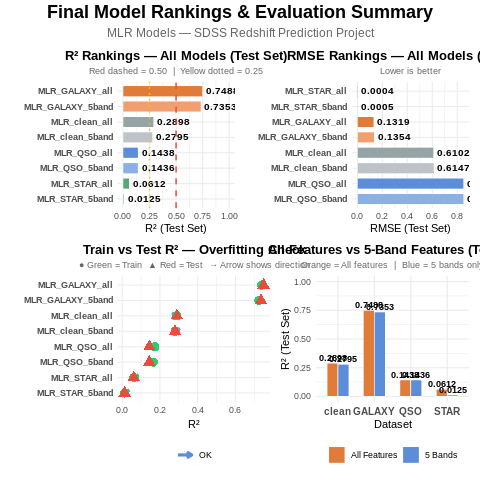

In [184]:
# @title 24.2. Final Model Rankings — Graphs
%%R
summary_folder = '/content/drive/MyDrive/Redshift_MLR/Result/Model_performance/Summary' # @param {type:"string"}
dpi            = 300 # @param {type:"slider", min:72, max:300, step:1}

if (!require('patchwork', quietly = TRUE)) install.packages('patchwork', quiet = TRUE)
library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)

dir.create(summary_folder, showWarnings = FALSE, recursive = TRUE)

all_results <- read.csv(file.path(summary_folder, 'eval_all_combined.csv'))

model_colors <- c(
  'MLR_clean_all'    = '#95A5A6',
  'MLR_clean_5band'  = '#BDC3C7',
  'MLR_GALAXY_all'   = '#E07B39',
  'MLR_GALAXY_5band' = '#F0A070',
  'MLR_QSO_all'      = '#5B8DD9',
  'MLR_QSO_5band'    = '#8BB0E8',
  'MLR_STAR_all'     = '#57A773',
  'MLR_STAR_5band'   = '#88C9A0'
)

test_only       <- all_results[all_results$Set == 'Test', ]
test_only$Model <- factor(test_only$Model,
                          levels = test_only$Model[order(test_only$R2)])

p1 <- ggplot(test_only, aes(x = Model, y = R2, fill = Model)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.4f', R2)),
            hjust = -0.1, size = 3.5, fontface = 'bold') +
  geom_hline(yintercept = 0.50, linetype = 'dashed', color = '#E74C3C', linewidth = 0.7) +
  geom_hline(yintercept = 0.25, linetype = 'dotted', color = '#F1C40F', linewidth = 0.7) +
  scale_fill_manual(values = model_colors) +
  scale_y_continuous(limits = c(0, 1.0)) +
  coord_flip() +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    legend.position = 'none',
    axis.text.y     = element_text(size = 9, face = 'bold')
  ) +
  labs(
    title    = 'R² Rankings — All Models (Test Set)',
    subtitle = 'Red dashed = 0.50  |  Yellow dotted = 0.25',
    x = '', y = 'R² (Test Set)'
  )

test_rmse       <- all_results[all_results$Set == 'Test', ]
test_rmse$Model <- factor(test_rmse$Model,
                          levels = test_rmse$Model[order(-test_rmse$RMSE)])

p2 <- ggplot(test_rmse, aes(x = Model, y = RMSE, fill = Model)) +
  geom_bar(stat = 'identity', width = 0.7, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.4f', RMSE)),
            hjust = -0.1, size = 3.5, fontface = 'bold') +
  scale_fill_manual(values = model_colors) +
  coord_flip() +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    legend.position = 'none',
    axis.text.y     = element_text(size = 9, face = 'bold')
  ) +
  labs(
    title    = 'RMSE Rankings — All Models (Test Set)',
    subtitle = 'Lower is better',
    x = '', y = 'RMSE (Test Set)'
  )

train_test <- all_results %>%
  select(Model, Set, R2) %>%
  pivot_wider(names_from = Set, values_from = R2) %>%
  mutate(
    Diff    = Train - Test,
    Overfit = ifelse(abs(Diff) > 0.05, 'Overfit', 'OK'),
    Model   = factor(Model, levels = Model[order(Test)])
  )

p3 <- ggplot(train_test) +
  geom_segment(aes(x = Train, xend = Test,
                   y = Model, yend = Model,
                   color = Overfit),
               linewidth = 1.5,
               arrow = arrow(length = unit(0.2, 'cm'))) +
  geom_point(aes(x = Train, y = Model),
             color = '#2ECC71', size = 4, shape = 16) +
  geom_point(aes(x = Test,  y = Model),
             color = '#E74C3C', size = 4, shape = 17) +
  scale_color_manual(values = c('OK' = '#5B8DD9', 'Overfit' = '#E74C3C')) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    axis.text.y     = element_text(size = 9, face = 'bold')
  ) +
  labs(
    title    = 'Train vs Test R² — Overfitting Check',
    subtitle = '● Green = Train  ▲ Red = Test  → Arrow shows direction',
    x = 'R²', y = ''
  )

compare_df <- test_only %>%
  mutate(
    FeatureSet = ifelse(grepl('_all', Model), 'All Features', '5 Bands'),
    Dataset    = gsub('dataset_', '', Dataset)
  )
compare_df$Dataset    <- factor(compare_df$Dataset,
                                levels = c('clean', 'GALAXY', 'QSO', 'STAR'))
compare_df$FeatureSet <- factor(compare_df$FeatureSet,
                                levels = c('All Features', '5 Bands'))

p4 <- ggplot(compare_df, aes(x = Dataset, y = R2, fill = FeatureSet)) +
  geom_bar(stat = 'identity', position = 'dodge',
           width = 0.6, color = 'white', linewidth = 0.3) +
  geom_text(aes(label = sprintf('%.4f', R2)),
            position = position_dodge(width = 0.6),
            vjust = -0.4, size = 3.2, fontface = 'bold') +
  scale_fill_manual(values = c('All Features' = '#E07B39',
                                '5 Bands'      = '#5B8DD9')) +
  scale_y_continuous(limits = c(0, 1.0)) +
  theme_minimal() +
  theme(
    plot.title      = element_text(face = 'bold', size = 13, hjust = 0.5),
    plot.subtitle   = element_text(size = 9, hjust = 0.5, color = 'gray40'),
    legend.position = 'bottom',
    legend.title    = element_blank(),
    axis.text.x     = element_text(size = 10, face = 'bold')
  ) +
  labs(
    title    = 'All Features vs 5-Band Features (Test R²)',
    subtitle = 'Orange = All features  |  Blue = 5 bands only',
    x = 'Dataset', y = 'R² (Test Set)'
  )

combined <- (p1 | p2) / (p3 | p4) +
  plot_annotation(
    title    = 'Final Model Rankings & Evaluation Summary',
    subtitle = 'MLR Models — SDSS Redshift Prediction Project',
    theme    = theme(
      plot.title    = element_text(face = 'bold', size = 18, hjust = 0.5),
      plot.subtitle = element_text(size = 12, hjust = 0.5, color = 'gray40')
    )
  )

options(repr.plot.width = 24, repr.plot.height = 18)
print(combined)

tmp_path   <- '/tmp/final_model_rankings.png'
drive_path <- file.path(summary_folder, 'final_model_rankings.png')
ggsave(tmp_path,   plot = combined, width = 24, height = 18, dpi = dpi)
file.copy(tmp_path, drive_path, overwrite = TRUE)
cat('==================================================\n')
cat(paste('Saved → ', drive_path, '\n'))
cat(paste('DPI    : ', dpi,         '\n'))
cat('==================================================\n')

---

# **Model Saving & Export Section**

---

In [185]:
# @title 25. Save Trained Models to Drive
%%R
folder_all    = '/content/drive/MyDrive/Redshift_MLR/Model/rds/All'    # @param {type:"string"}
folder_galaxy = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy' # @param {type:"string"}
folder_qso    = '/content/drive/MyDrive/Redshift_MLR/Model/rds/QSO'    # @param {type:"string"}
folder_star   = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Star'   # @param {type:"string"}

dir.create(folder_all,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_galaxy, showWarnings = FALSE, recursive = TRUE)
dir.create(folder_qso,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_star,   showWarnings = FALSE, recursive = TRUE)

# =====================================================
# Save models to their respective subfolders
# =====================================================
models <- list(
  list(model = MLR_clean_all,    folder = folder_all,    name = 'MLR_clean_all.rds'),
  list(model = MLR_clean_5band,  folder = folder_all,    name = 'MLR_clean_5band.rds'),
  list(model = MLR_GALAXY_all,   folder = folder_galaxy, name = 'MLR_GALAXY_all.rds'),
  list(model = MLR_GALAXY_5band, folder = folder_galaxy, name = 'MLR_GALAXY_5band.rds'),
  list(model = MLR_QSO_all,      folder = folder_qso,    name = 'MLR_QSO_all.rds'),
  list(model = MLR_QSO_5band,    folder = folder_qso,    name = 'MLR_QSO_5band.rds'),
  list(model = MLR_STAR_all,     folder = folder_star,   name = 'MLR_STAR_all.rds'),
  list(model = MLR_STAR_5band,   folder = folder_star,   name = 'MLR_STAR_5band.rds')
)

cat('==================================================\n')
cat('--- Saving Models to Drive ---\n')
cat('==================================================\n\n')

for (m in models) {
  path <- file.path(m$folder, m$name)
  saveRDS(m$model, path)
  tag <- ifelse(m$name %in% c('MLR_GALAXY_5band.rds', 'MLR_QSO_5band.rds'),
                ' ← Recommended', '')
  cat(sprintf('  ✅ Saved → %s%s\n', path, tag))
}

cat('\n==================================================\n')
cat('--- Folder Structure ---\n')
cat('==================================================\n')
cat(sprintf('  All/    : %s\n', folder_all))
cat('    MLR_clean_all.rds\n')
cat('    MLR_clean_5band.rds\n')
cat(sprintf('  Galaxy/ : %s\n', folder_galaxy))
cat('    MLR_GALAXY_all.rds\n')
cat('    MLR_GALAXY_5band.rds  ✅ Recommended\n')
cat(sprintf('  QSO/    : %s\n', folder_qso))
cat('    MLR_QSO_all.rds\n')
cat('    MLR_QSO_5band.rds     ✅ Recommended\n')
cat(sprintf('  Star/   : %s\n', folder_star))
cat('    MLR_STAR_all.rds\n')
cat('    MLR_STAR_5band.rds\n')
cat('==================================================\n')

--- Saving Models to Drive ---

  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_all.rds
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_5band.rds
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_all.rds
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_5band.rds ← Recommended
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_all.rds
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_5band.rds ← Recommended
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_all.rds
  ✅ Saved → /content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_5band.rds

--- Folder Structure ---
  All/    : /content/drive/MyDrive/Redshift_MLR/Model/rds/All
    MLR_clean_all.rds
    MLR_clean_5band.rds
  Galaxy/ : /content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy
    MLR_GALAXY_all.rds
    MLR_GALAXY_5band.rds  ✅ Recommended
  QSO/    : /content/drive

In [186]:
# @title 26. Extract Model Coefficients to JSON
%%R
folder_all    = '/content/drive/MyDrive/Redshift_MLR/Model/json/All'    # @param {type:"string"}
folder_galaxy = '/content/drive/MyDrive/Redshift_MLR/Model/json/Galaxy' # @param {type:"string"}
folder_qso    = '/content/drive/MyDrive/Redshift_MLR/Model/json/QSO'    # @param {type:"string"}
folder_star   = '/content/drive/MyDrive/Redshift_MLR/Model/json/Star'   # @param {type:"string"}

dir.create(folder_all,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_galaxy, showWarnings = FALSE, recursive = TRUE)
dir.create(folder_qso,    showWarnings = FALSE, recursive = TRUE)
dir.create(folder_star,   showWarnings = FALSE, recursive = TRUE)

if (!require('jsonlite', quietly = TRUE)) install.packages('jsonlite', quiet = TRUE)
library(jsonlite)

# =====================================================
# Helper: extract coefficients + exact PI half-width
# PI formula: pred ± t(α/2, n-p-1) × σ × √(1 + 1/n)
# =====================================================
extract_coef <- function(model, train_data, model_name, dataset_name,
                          feature_set, r2, adj_r2, rmse, mae) {
  coefs      <- coef(model)
  coef_names <- names(coefs)
  n_features <- length(coefs) - 1

  # Build named coefficient list — round to 8 decimal places
  coef_list <- list()
  coef_list[['b0_intercept']] <- round(unname(coefs['(Intercept)']), 8)
  for (i in 2:length(coefs)) {
    key              <- paste0('b', i - 1, '_', coef_names[i])
    coef_list[[key]] <- round(unname(coefs[i]), 8)
  }

  # Build equation string
  eq <- sprintf('redshift = %.8f', coefs[1])
  for (i in 2:length(coefs)) {
    sign_str <- ifelse(coefs[i] >= 0, ' + ', ' - ')
    eq <- paste0(eq, sprintf('%s%.8f * %s', sign_str, abs(coefs[i]), coef_names[i]))
  }

  # ── Exact 95% PI half-width ──
  # t(0.975, df=n-p-1) × σ × √(1 + 1/n)
  s       <- summary(model)
  sigma   <- s$sigma
  n_train <- nrow(train_data)
  p       <- n_features
  df_res  <- n_train - p - 1
  t_crit  <- qt(0.975, df = df_res)
  pi_half <- t_crit * sigma * sqrt(1 + 1 / n_train)

  list(
    model_name   = model_name,
    dataset      = dataset_name,
    feature_set  = feature_set,
    n_features   = n_features,
    features     = coef_names[-1],
    metrics = list(
      r2            = round(r2,      6),
      adj_r2        = round(adj_r2,  6),
      rmse          = round(rmse,    6),
      mae           = round(mae,     6),
      residual_se   = round(sigma,   8),
      df_residual   = df_res,
      n_train       = n_train,
      t_crit_95     = round(t_crit,  8),
      pi_half_width = round(pi_half, 8)
    ),
    coefficients = coef_list,
    equation     = eq
  )
}

# =====================================================
# Get metrics
# =====================================================
s_c_all   <- summary(MLR_clean_all)
s_c_5band <- summary(MLR_clean_5band)
s_g_all   <- summary(MLR_GALAXY_all)
s_g_5band <- summary(MLR_GALAXY_5band)
s_q_all   <- summary(MLR_QSO_all)
s_q_5band <- summary(MLR_QSO_5band)
s_s_all   <- summary(MLR_STAR_all)
s_s_5band <- summary(MLR_STAR_5band)

get_rmse <- function(model, data) {
  sqrt(mean((data$redshift - predict(model, newdata = data))^2))
}
get_mae <- function(model, data) {
  mean(abs(data$redshift - predict(model, newdata = data)))
}

# =====================================================
# Extract all 8 models
# =====================================================
models_list <- list(

  # --- All ---
  list(
    data   = extract_coef(MLR_clean_all,   dataset_clean_train,  'MLR_clean_all',   'dataset_clean',  'all_features',
                          s_c_all$r.squared,   s_c_all$adj.r.squared,
                          get_rmse(MLR_clean_all,   dataset_clean_test),
                          get_mae(MLR_clean_all,    dataset_clean_test)),
    folder = folder_all, file = 'MLR_clean_all.json'
  ),
  list(
    data   = extract_coef(MLR_clean_5band, dataset_clean_train,  'MLR_clean_5band', 'dataset_clean',  '5band',
                          s_c_5band$r.squared, s_c_5band$adj.r.squared,
                          get_rmse(MLR_clean_5band, dataset_clean_test),
                          get_mae(MLR_clean_5band,  dataset_clean_test)),
    folder = folder_all, file = 'MLR_clean_5band.json'
  ),

  # --- Galaxy ---
  list(
    data   = extract_coef(MLR_GALAXY_all,   dataset_GALAXY_train, 'MLR_GALAXY_all',   'dataset_GALAXY', 'all_features',
                          s_g_all$r.squared,   s_g_all$adj.r.squared,
                          get_rmse(MLR_GALAXY_all,   dataset_GALAXY_test),
                          get_mae(MLR_GALAXY_all,    dataset_GALAXY_test)),
    folder = folder_galaxy, file = 'MLR_GALAXY_all.json'
  ),
  list(
    data   = extract_coef(MLR_GALAXY_5band, dataset_GALAXY_train, 'MLR_GALAXY_5band', 'dataset_GALAXY', '5band',
                          s_g_5band$r.squared, s_g_5band$adj.r.squared,
                          get_rmse(MLR_GALAXY_5band, dataset_GALAXY_test),
                          get_mae(MLR_GALAXY_5band,  dataset_GALAXY_test)),
    folder = folder_galaxy, file = 'MLR_GALAXY_5band.json'
  ),

  # --- QSO ---
  list(
    data   = extract_coef(MLR_QSO_all,   dataset_QSO_train, 'MLR_QSO_all',   'dataset_QSO', 'all_features',
                          s_q_all$r.squared,   s_q_all$adj.r.squared,
                          get_rmse(MLR_QSO_all,   dataset_QSO_test),
                          get_mae(MLR_QSO_all,    dataset_QSO_test)),
    folder = folder_qso, file = 'MLR_QSO_all.json'
  ),
  list(
    data   = extract_coef(MLR_QSO_5band, dataset_QSO_train, 'MLR_QSO_5band', 'dataset_QSO', '5band',
                          s_q_5band$r.squared, s_q_5band$adj.r.squared,
                          get_rmse(MLR_QSO_5band, dataset_QSO_test),
                          get_mae(MLR_QSO_5band,  dataset_QSO_test)),
    folder = folder_qso, file = 'MLR_QSO_5band.json'
  ),

  # --- Star ---
  list(
    data   = extract_coef(MLR_STAR_all,   dataset_STAR_train, 'MLR_STAR_all',   'dataset_STAR', 'all_features',
                          s_s_all$r.squared,   s_s_all$adj.r.squared,
                          get_rmse(MLR_STAR_all,   dataset_STAR_test),
                          get_mae(MLR_STAR_all,    dataset_STAR_test)),
    folder = folder_star, file = 'MLR_STAR_all.json'
  ),
  list(
    data   = extract_coef(MLR_STAR_5band, dataset_STAR_train, 'MLR_STAR_5band', 'dataset_STAR', '5band',
                          s_s_5band$r.squared, s_s_5band$adj.r.squared,
                          get_rmse(MLR_STAR_5band, dataset_STAR_test),
                          get_mae(MLR_STAR_5band,  dataset_STAR_test)),
    folder = folder_star, file = 'MLR_STAR_5band.json'
  )
)

# =====================================================
# Save all JSON files — digits=8 preserves full precision
# =====================================================
cat('==================================================\n')
cat('--- Exporting Model Coefficients to JSON ---\n')
cat('==================================================\n\n')

for (m in models_list) {
  path <- file.path(m$folder, m$file)
  write_json(m$data, path, pretty = TRUE, auto_unbox = TRUE, digits = 8)

  tag <- ifelse(m$file %in% c('MLR_GALAXY_5band.json', 'MLR_QSO_5band.json'),
                ' ✅ Recommended', '')
  cat(sprintf('  Saved → %s%s\n', path, tag))
  cat(sprintf('    Model         : %s\n',   m$data$model_name))
  cat(sprintf('    R²            : %.6f\n', m$data$metrics$r2))
  cat(sprintf('    Residual SE   : %.8f\n', m$data$metrics$residual_se))
  cat(sprintf('    t-crit(0.975) : %.8f\n', m$data$metrics$t_crit_95))
  cat(sprintf('    PI half-width : %.8f\n', m$data$metrics$pi_half_width))
  cat(sprintf('    b0 intercept  : %.8f\n', m$data$coefficients$b0_intercept))
  cat(sprintf('    Equation      : %s\n\n', m$data$equation))
}

cat('==================================================\n')
cat('--- Folder Summary ---\n')
cat('==================================================\n')
cat(sprintf('  json/All/    → %s\n', folder_all))
cat('    MLR_clean_all.json\n')
cat('    MLR_clean_5band.json\n')
cat(sprintf('  json/Galaxy/ → %s\n', folder_galaxy))
cat('    MLR_GALAXY_all.json\n')
cat('    MLR_GALAXY_5band.json  ✅\n')
cat(sprintf('  json/QSO/    → %s\n', folder_qso))
cat('    MLR_QSO_all.json\n')
cat('    MLR_QSO_5band.json     ✅\n')
cat(sprintf('  json/Star/   → %s\n', folder_star))
cat('    MLR_STAR_all.json\n')
cat('    MLR_STAR_5band.json\n')
cat('==================================================\n')
cat('Total : 8 JSON files exported with digits=8 precision.\n')
cat('==================================================\n')

--- Exporting Model Coefficients to JSON ---

  Saved → /content/drive/MyDrive/Redshift_MLR/Model/json/All/MLR_clean_all.json
    Model         : MLR_clean_all
    R²            : 0.289747
    Residual SE   : 0.61722980
    t-crit(0.975) : 1.95999365
    PI half-width : 1.20977405
    b0 intercept  : -4.09137120
    Equation      : redshift = -4.09137120 + 0.00008601 * alpha + 0.00035705 * delta - 0.02736269 * u - 0.07783309 * g - 0.03280876 * r + 0.25922288 * i + 0.04338864 * z - 0.00000551 * run_ID - 0.00215491 * cam_col + 0.00003606 * field_ID + 0.00001220 * plate + 0.00003016 * MJD + 0.00005741 * fiber_ID

  Saved → /content/drive/MyDrive/Redshift_MLR/Model/json/All/MLR_clean_5band.json
    Model         : MLR_clean_5band
    R²            : 0.280485
    Residual SE   : 0.62120989
    t-crit(0.975) : 1.95999364
    PI half-width : 1.21757505
    b0 intercept  : -2.98275173
    Equation      : redshift = -2.98275173 - 0.03310654 * u - 0.06756917 * g - 0.02255429 * r + 0.27305967 * i

---

# **Model Loading & Prediction Section**

---

In [187]:
# @title 27. Set Model Paths
# @markdown --- All ---
path_model_clean_all    = '/content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_all.rds'       # @param {type:"string"}
path_model_clean_5band  = '/content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_5band.rds'     # @param {type:"string"}
# @markdown --- Galaxy ---
path_model_galaxy_all   = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_all.rds'   # @param {type:"string"}
path_model_galaxy_5band = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_5band.rds' # @param {type:"string"}
# @markdown --- QSO ---
path_model_qso_all      = '/content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_all.rds'         # @param {type:"string"}
path_model_qso_5band    = '/content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_5band.rds'       # @param {type:"string"}
# @markdown --- Star ---
path_model_star_all     = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_all.rds'       # @param {type:"string"}
path_model_star_5band   = '/content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_5band.rds'     # @param {type:"string"}
# @markdown ---

import os

paths = {
    'All/MLR_clean_all'       : path_model_clean_all,
    'All/MLR_clean_5band'     : path_model_clean_5band,
    'Galaxy/MLR_GALAXY_all'   : path_model_galaxy_all,
    'Galaxy/MLR_GALAXY_5band' : path_model_galaxy_5band,
    'QSO/MLR_QSO_all'         : path_model_qso_all,
    'QSO/MLR_QSO_5band'       : path_model_qso_5band,
    'Star/MLR_STAR_all'       : path_model_star_all,
    'Star/MLR_STAR_5band'     : path_model_star_5band,
}

print("==================================================")
print("--- Model Path Check ---")
print("==================================================")

all_ok = True
for name, path in paths.items():
    exists = os.path.exists(path)
    status = "✅ Found"    if exists else "❌ Not Found"
    tag    = " ← Recommended" if name in ['Galaxy/MLR_GALAXY_5band',
                                           'QSO/MLR_QSO_5band'] else ""
    print(f"  {status} | {name}{tag}")
    print(f"           {path}")
    if not exists:
        all_ok = False

print("==================================================")
if all_ok:
    print("  ✅ All 8 model files found. Ready to load.")
else:
    print("  ❌ Some files not found. Please run Cell 35 first.")
print("==================================================")

--- Model Path Check ---
  ✅ Found | All/MLR_clean_all
           /content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_all.rds
  ✅ Found | All/MLR_clean_5band
           /content/drive/MyDrive/Redshift_MLR/Model/rds/All/MLR_clean_5band.rds
  ✅ Found | Galaxy/MLR_GALAXY_all
           /content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_all.rds
  ✅ Found | Galaxy/MLR_GALAXY_5band ← Recommended
           /content/drive/MyDrive/Redshift_MLR/Model/rds/Galaxy/MLR_GALAXY_5band.rds
  ✅ Found | QSO/MLR_QSO_all
           /content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_all.rds
  ✅ Found | QSO/MLR_QSO_5band ← Recommended
           /content/drive/MyDrive/Redshift_MLR/Model/rds/QSO/MLR_QSO_5band.rds
  ✅ Found | Star/MLR_STAR_all
           /content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_all.rds
  ✅ Found | Star/MLR_STAR_5band
           /content/drive/MyDrive/Redshift_MLR/Model/rds/Star/MLR_STAR_5band.rds
  ✅ All 8 model files found. Ready to load.


In [188]:
# @title 28. Load Models from Drive
%%R -i path_model_clean_all -i path_model_clean_5band -i path_model_galaxy_all -i path_model_galaxy_5band -i path_model_qso_all -i path_model_qso_5band -i path_model_star_all -i path_model_star_5band

MLR_clean_all    <- readRDS(path_model_clean_all)
MLR_clean_5band  <- readRDS(path_model_clean_5band)
MLR_GALAXY_all   <- readRDS(path_model_galaxy_all)
MLR_GALAXY_5band <- readRDS(path_model_galaxy_5band)
MLR_QSO_all      <- readRDS(path_model_qso_all)
MLR_QSO_5band    <- readRDS(path_model_qso_5band)
MLR_STAR_all     <- readRDS(path_model_star_all)
MLR_STAR_5band   <- readRDS(path_model_star_5band)

cat('==================================================\n')
cat('--- Models Loaded from Drive ---\n')
cat('==================================================\n\n')

models_info <- list(
  list(model = MLR_clean_all,    name = 'MLR_clean_all',    folder = 'All'),
  list(model = MLR_clean_5band,  name = 'MLR_clean_5band',  folder = 'All'),
  list(model = MLR_GALAXY_all,   name = 'MLR_GALAXY_all',   folder = 'Galaxy'),
  list(model = MLR_GALAXY_5band, name = 'MLR_GALAXY_5band', folder = 'Galaxy'),
  list(model = MLR_QSO_all,      name = 'MLR_QSO_all',      folder = 'QSO'),
  list(model = MLR_QSO_5band,    name = 'MLR_QSO_5band',    folder = 'QSO'),
  list(model = MLR_STAR_all,     name = 'MLR_STAR_all',     folder = 'Star'),
  list(model = MLR_STAR_5band,   name = 'MLR_STAR_5band',   folder = 'Star')
)

cat(sprintf('  %-10s %-22s %10s\n', 'Folder', 'Model', 'Features'))
cat(paste(rep('-', 45), collapse = ''), '\n')

for (m in models_info) {
  n_features <- length(coef(m$model)) - 1
  tag        <- ifelse(m$name %in% c('MLR_GALAXY_5band', 'MLR_QSO_5band'),
                       ' ✅', '')
  cat(sprintf('  %-10s %-22s %10d%s\n',
      m$folder, m$name, n_features, tag))
}

cat('\n==================================================\n')
cat('All 8 models loaded into R memory successfully.\n')
cat('✅ = Recommended model\n')
cat('==================================================\n')

--- Models Loaded from Drive ---

  Folder     Model                    Features
--------------------------------------------- 
  All        MLR_clean_all                  13
  All        MLR_clean_5band                 5
  Galaxy     MLR_GALAXY_all                 13
  Galaxy     MLR_GALAXY_5band                5 ✅
  QSO        MLR_QSO_all                    13
  QSO        MLR_QSO_5band                   5 ✅
  Star       MLR_STAR_all                   13
  Star       MLR_STAR_5band                  5

All 8 models loaded into R memory successfully.
✅ = Recommended model


In [189]:
# @title 29. Apply Model — Predict Redshift for New Objects
%%R
object_class = 'GALAXY' # @param ["GALAXY", "QSO", "STAR"]
u_band = 20.14  # @param {type:"number"}
g_band = 18.32  # @param {type:"number"}
r_band = 17.41  # @param {type:"number"}
i_band = 16.93  # @param {type:"number"}
z_band = 16.60  # @param {type:"number"}

PHYS_BRIGHT <- 10
PHYS_FAINT  <- 30

new_object <- data.frame(u=u_band, g=g_band, r=r_band, i=i_band, z=z_band)

cat('==================================================\n')
cat('--- Redshift Prediction for New Object ---\n')
cat('==================================================\n')
cat(sprintf('  Class : %s\n', object_class))
cat(sprintf('  u     : %.5f\n', u_band))
cat(sprintf('  g     : %.5f\n', g_band))
cat(sprintf('  r     : %.5f\n', r_band))
cat(sprintf('  i     : %.5f\n', i_band))
cat(sprintf('  z     : %.5f\n', z_band))
cat('--------------------------------------------------\n')

bands     <- c('u', 'g', 'r', 'i', 'z')
band_vals <- c(u_band, g_band, r_band, i_band, z_band)
invalid   <- bands[band_vals < PHYS_BRIGHT | band_vals > PHYS_FAINT]

if (length(invalid) > 0) {
  cat(sprintf('  ❌ Invalid band values: [%s]\n', paste(invalid, collapse=', ')))
  cat('  Prediction aborted.\n')

} else {

  if (object_class == 'GALAXY') {
    model      <- MLR_GALAXY_5band
    model_name <- 'MLR_GALAXY_5band'
    model_r2   <- 0.7353
    predicted  <- predict(model, newdata=new_object)
    conf_int   <- predict(model, newdata=new_object, interval='confidence', level=0.95)
    pred_int   <- predict(model, newdata=new_object, interval='prediction', level=0.95)
    status_msg <- '  ✅ Prediction reliable — GALAXY model is strong (R²=0.74)\n'

  } else if (object_class == 'QSO') {
    model      <- MLR_QSO_5band
    model_name <- 'MLR_QSO_5band'
    model_r2   <- 0.1436
    predicted  <- predict(model, newdata=new_object)
    conf_int   <- predict(model, newdata=new_object, interval='confidence', level=0.95)
    pred_int   <- predict(model, newdata=new_object, interval='prediction', level=0.95)
    status_msg <- '  ⚠️  Use with caution — QSO model is weak (R²=0.14)\n'

  } else {
    model_name <- 'None (STAR)'
    model_r2   <- NA
    predicted  <- 0.0
    conf_int   <- matrix(c(0,0,0), nrow=1, dimnames=list(NULL, c('fit','lwr','upr')))
    pred_int   <- matrix(c(0,0,0), nrow=1, dimnames=list(NULL, c('fit','lwr','upr')))
    status_msg <- '  ✅ STARs have no cosmological redshift — predict 0\n'
  }

  cat(sprintf('  Model used    : %s\n',   model_name))
  cat(sprintf('  Predicted z   : %.6f\n', predicted))

  if (object_class != 'STAR') {
    cat('\n  --- 95% Confidence Interval (CI) ---\n')
    cat(sprintf('  CI Lower      : %.6f\n', conf_int[, 'lwr']))
    cat(sprintf('  CI Upper      : %.6f\n', conf_int[, 'upr']))
    cat(sprintf('  CI Width      : %.6f\n', conf_int[,'upr'] - conf_int[,'lwr']))
    cat('  Note: CI = uncertainty of the model mean estimate\n')

    cat('\n  --- 95% Prediction Interval (PI) ---\n')
    pi_lower <- pred_int[, 'lwr']
    pi_upper <- pred_int[, 'upr']
    cat(sprintf('  PI Lower      : %.6f', pi_lower))
    if (pi_lower < 0) cat('  ⚠ (negative → blueshift, outside training range)')
    cat('\n')
    cat(sprintf('  PI Upper      : %.6f\n', pi_upper))
    cat(sprintf('  PI Width      : %.6f\n', pi_upper - pi_lower))
    cat('  Note: PI = expected range for a single new object (use this)\n')

    cat(sprintf('\n  Model R²      : %.4f\n', model_r2))
  }

  cat(status_msg)
}
cat('==================================================\n')

--- Redshift Prediction for New Object ---
  Class : GALAXY
  u     : 20.14000
  g     : 18.32000
  r     : 17.41000
  i     : 16.93000
  z     : 16.60000
--------------------------------------------------
  Model used    : MLR_GALAXY_5band
  Predicted z   : 0.159082

  --- 95% Confidence Interval (CI) ---
  CI Lower      : 0.157079
  CI Upper      : 0.161085
  CI Width      : 0.004006
  Note: CI = uncertainty of the model mean estimate

  --- 95% Prediction Interval (PI) ---
  PI Lower      : -0.113769  ⚠ (negative → blueshift, outside training range)
  PI Upper      : 0.431932
  PI Width      : 0.545701
  Note: PI = expected range for a single new object (use this)

  Model R²      : 0.7353
  ✅ Prediction reliable — GALAXY model is strong (R²=0.74)
